# Home Credit Default Risk — Model Development and Validation

## Project Objective

Build, validate, compare, calibrate, explain, and package robust credit-default classification models using the completed feature-engineering dataset.

## Prediction Problem

- Task: Binary classification
- Target: `TARGET`
- Positive class: Applicant default
- Identifier: `SK_ID_CURR`
- Primary ranking metric: ROC-AUC
- Mandatory secondary metrics: PR-AUC, Log Loss, Brier Score, KS, calibration slope, and calibration intercept

## Final Modelling Inputs

- Main feature set: Maximum information-preserving predictors
- Lean feature set: Reduced-redundancy performance predictors
- Compact feature set: Interpretable and faster experimental predictors
- Fairness-reduced feature set: Optional governance and sensitivity comparison

## Research Workflow

1. Verify the final datasets, environment, and hardware.
2. Freeze reproducible validation folds.
3. Establish simple risk baselines.
4. Screen linear, tree, bagging, and boosting model families.
5. Compare feature sets and feature-engineering blocks.
6. Tune only the strongest model families.
7. Generate final out-of-fold predictions.
8. Analyse calibration, thresholds, lift, and operational performance.
9. Build honest ensembles using out-of-fold predictions.
10. Audit robustness, drift, fairness, and explainability.
11. Lock the final configuration and create test predictions.

## Leakage Boundary

The following operations must be fitted only inside the appropriate training fold:

- Missing-value imputation
- Numerical scaling
- Categorical encoding
- Target or weight-of-evidence encoding
- Supervised binning or transformation
- Feature selection
- Probability calibration
- Ensemble-weight optimisation

The test dataset must never influence preprocessing, model selection, hyperparameter selection, calibration, or blending.

## Engineering Policy

- Use all available CPU resources where supported.
- Use the RTX 5060 Ti GPU for supported boosting models.
- Run one major GPU model at a time.
- Execute native GPU libraries in isolated worker processes during hardware calibration.
- Save every important result immediately after completion.
- Keep long-running experiments resumable.
- Record runtime, memory, feature count, and validation metrics for every model.

# Step 0 — Environment, Data, Hardware, and Runtime Calibration

## Objectives

- Configure reproducible global settings.
- Create the modelling output structure.
- Audit software, CPU, RAM, GPU, and CUDA visibility.
- Load and independently validate the final modelling datasets.
- Create a fixed 50,000-row runtime benchmark.
- Test CPU and GPU model compatibility without risking the notebook kernel.
- Estimate full-dataset model runtime from measured local performance.

## Important Boundary

Step 0 is a compatibility and engineering-calibration stage.

Benchmark scores from this step are not final validation results and must not be used to select the final model.

## Step 0.1 — Configure the Notebook and Define Small Helper Functions

### Actions

- Configure CPU thread usage and random seeds.
- Import mandatory and optional libraries.
- Define compact reporting, saving, metric, dtype, memory, and hardware helpers.
- Centralise notebook constants inside configuration dictionaries.

In [ ]:
import os
import gc
import json
import time
import platform
import subprocess
import warnings
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import os
import gc
import json
import time
import shutil
import hashlib
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import display

CPU_THREADS = os.cpu_count() or 8

for environment_variable in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[environment_variable] = str(CPU_THREADS)

os.environ["PYTHONHASHSEED"] = "42"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import joblib

from IPython.display import display
from sklearn import __version__ as sklearn_version
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

CONFIG = {
    "random_state": 42,
    "n_jobs": -1,
    "gpu_device_id": 0,
    "benchmark_rows": 50_000,
    "benchmark_valid_size": 0.20,
    "benchmark_rounds": 1_500,
    "early_stopping_rounds": 50,
    "worker_timeout_seconds": 1_800,
    "notebook_version": "2.0"
}

np.random.seed(CONFIG["random_state"])
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    psutil = None
    PSUTIL_AVAILABLE = False

OPTIONAL_LIBRARIES = {}

for library_name in ["lightgbm", "xgboost", "catboost", "optuna"]:
    try:
        OPTIONAL_LIBRARIES[library_name] = {"available": True, "version": version(library_name)}
    except Exception:
        OPTIONAL_LIBRARIES[library_name] = {"available": False, "version": "NOT_INSTALLED"}

def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)

def package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "NOT_INSTALLED"
    except Exception:
        return "UNKNOWN"

def dtype_family(dtype):
    if pd.api.types.is_bool_dtype(dtype):
        return "boolean"

    if pd.api.types.is_numeric_dtype(dtype):
        return "numeric"

    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "datetime"

    if pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype) or isinstance(dtype, pd.CategoricalDtype):
        return "categorical"

    return "unsupported"

def evaluate_probabilities(y_true, probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "prediction_mean": float(probability.mean())
    }

def process_memory_gb():
    if not PSUTIL_AVAILABLE:
        return np.nan

    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def show_report(title, values):
    print("=" * 94)
    print(title)

    for label, value in values:
        print(f"{label}: {value}")

    print("=" * 94)

def query_gpu():
    command = ["nvidia-smi", "--query-gpu=index,name,memory.total,memory.free,memory.used,driver_version", "--format=csv,noheader,nounits"]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True, timeout=30)
        records = []

        for line in result.stdout.strip().splitlines():
            values = [value.strip() for value in line.split(",")]

            if len(values) == 6:
                records.append({"gpu_index": int(values[0]), "gpu_name": values[1], "memory_total_mb": int(values[2]), "memory_free_mb": int(values[3]), "memory_used_mb": int(values[4]), "driver_version": values[5]})

        return pd.DataFrame(records), None

    except Exception as error:
        return pd.DataFrame(), f"{type(error).__name__}: {error}"

library_table = pd.DataFrame([{"library": library, **information} for library, information in OPTIONAL_LIBRARIES.items()])
display(library_table)

show_report("STEP 0.1 COMPLETE", [
    ("Random state", CONFIG["random_state"]),
    ("CPU thread policy", f"{CPU_THREADS} detected, n_jobs={CONFIG['n_jobs']}"),
    ("GPU device", CONFIG["gpu_device_id"]),
    ("Runtime benchmark rows", f"{CONFIG['benchmark_rows']:,}"),
    ("Worker isolation timeout", f"{CONFIG['worker_timeout_seconds']} seconds")
])

,library,available,version
0,lightgbm,True,4.7.0
1,xgboost,True,3.2.0
2,catboost,True,1.2.10
3,optuna,True,4.8.0


STEP 0.1 COMPLETE
Random state: 42
CPU thread policy: 16 detected, n_jobs=-1
GPU device: 0
Runtime benchmark rows: 50,000
Worker isolation timeout: 1800 seconds


## Step 0.2 — Define Paths and Audit the Modelling Environment

### Actions

- Define all project paths through compact dictionaries.
- Create the modelling output directories.
- Verify required feature-engineering inputs.
- Record package versions, CPU resources, RAM, GPU model, VRAM, and driver.
- Save reproducible path and environment manifests.

In [2]:
PROJECT_ROOT = Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk")

DIRS = {
    "feature_package": PROJECT_ROOT / "Feature_engineering" / "final_package",
    "model_root": PROJECT_ROOT / "Model_training",
    "checkpoints": PROJECT_ROOT / "Model_training" / "checkpoints",
    "folds": PROJECT_ROOT / "Model_training" / "folds",
    "metrics": PROJECT_ROOT / "Model_training" / "metrics",
    "models": PROJECT_ROOT / "Model_training" / "models",
    "oof": PROJECT_ROOT / "Model_training" / "oof_predictions",
    "test_predictions": PROJECT_ROOT / "Model_training" / "test_predictions",
    "tuning": PROJECT_ROOT / "Model_training" / "tuning",
    "calibration": PROJECT_ROOT / "Model_training" / "calibration",
    "figures": PROJECT_ROOT / "Model_training" / "figures",
    "explanations": PROJECT_ROOT / "Model_training" / "explanations",
    "temporary_workers": PROJECT_ROOT / "Model_training" / "temporary_workers",
    "manifests": PROJECT_ROOT / "Model_training" / "manifests",
    "final_package": PROJECT_ROOT / "Model_training" / "final_package"
}

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

PATHS = {
    "train": DIRS["feature_package"] / "data" / "train_feature_engineered.parquet",
    "test": DIRS["feature_package"] / "data" / "test_feature_engineered.parquet",
    "summary": DIRS["feature_package"] / "metadata" / "feature_engineering_summary.json",
    "validation": DIRS["feature_package"] / "metadata" / "final_validation_report.csv",
    "registry": DIRS["feature_package"] / "metadata" / "final_feature_registry.csv",
    "main_features": DIRS["feature_package"] / "metadata" / "main_feature_list.csv",
    "lean_features": DIRS["feature_package"] / "metadata" / "lean_feature_list.csv",
    "compact_features": DIRS["feature_package"] / "metadata" / "compact_feature_list.csv",
    "fairness_reduced": DIRS["feature_package"] / "metadata" / "fairness_reduced_feature_list.csv",
    "fairness_exclusion": DIRS["feature_package"] / "metadata" / "fairness_exclusion_list.csv",
    "review_watchlist": DIRS["feature_package"] / "metadata" / "feature_review_watchlist.csv"
}

required_inputs = ["train", "test", "summary", "validation", "registry", "main_features", "lean_features", "compact_features", "review_watchlist"]
missing_inputs = [str(PATHS[name]) for name in required_inputs if not PATHS[name].exists()]

assert not missing_inputs, f"Required modelling inputs are missing: {missing_inputs}"

gpu_table, gpu_error = query_gpu()

physical_cores = psutil.cpu_count(logical=False) if PSUTIL_AVAILABLE else None
logical_threads = psutil.cpu_count(logical=True) if PSUTIL_AVAILABLE else CPU_THREADS
memory = psutil.virtual_memory() if PSUTIL_AVAILABLE else None

ENVIRONMENT = {
    "notebook_version": CONFIG["notebook_version"],
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "operating_system": platform.platform(),
    "python": platform.python_version(),
    "physical_cpu_cores": physical_cores,
    "logical_cpu_threads": logical_threads,
    "total_ram_gb": round(memory.total / (1024 ** 3), 3) if memory else None,
    "available_ram_gb": round(memory.available / (1024 ** 3), 3) if memory else None,
    "gpu_detected": not gpu_table.empty,
    "gpu_query_error": gpu_error,
    "gpu_information": gpu_table.to_dict("records"),
    "packages": {
        "numpy": package_version("numpy"),
        "pandas": package_version("pandas"),
        "scikit_learn": sklearn_version,
        "pyarrow": package_version("pyarrow"),
        "lightgbm": package_version("lightgbm"),
        "xgboost": package_version("xgboost"),
        "catboost": package_version("catboost"),
        "optuna": package_version("optuna")
    }
}

save_json({name: str(path) for name, path in PATHS.items()}, DIRS["manifests"] / "path_manifest.json")
save_json(ENVIRONMENT, DIRS["manifests"] / "environment_manifest.json")

environment_table = pd.DataFrame([
    {"item": "Physical CPU cores", "value": physical_cores},
    {"item": "Logical CPU threads", "value": logical_threads},
    {"item": "Total RAM GB", "value": ENVIRONMENT["total_ram_gb"]},
    {"item": "Available RAM GB", "value": ENVIRONMENT["available_ram_gb"]},
    {"item": "GPU detected", "value": ENVIRONMENT["gpu_detected"]},
    {"item": "All CPU threads requested", "value": CONFIG["n_jobs"] == -1}
])

display(environment_table)

if not gpu_table.empty:
    display(gpu_table)

show_report("STEP 0.2 COMPLETE", [
    ("Required inputs verified", len(required_inputs)),
    ("Output directories created", len(DIRS)),
    ("Physical CPU cores", physical_cores),
    ("Logical CPU threads", logical_threads),
    ("Total RAM", f"{ENVIRONMENT['total_ram_gb']} GB"),
    ("GPU detected", ENVIRONMENT["gpu_detected"]),
    ("Environment manifest", DIRS["manifests"] / "environment_manifest.json")
])

,item,value
0,Physical CPU cores,8
1,Logical CPU threads,16
2,Total RAM GB,31.575000
3,Available RAM GB,15.513000
4,GPU detected,True
5,All CPU threads requested,True


,gpu_index,gpu_name,memory_total_mb,memory_free_mb,memory_used_mb,driver_version
0,0,NVIDIA GeForce RTX 5060 Ti,8151,6199,1604,576.88


STEP 0.2 COMPLETE
Required inputs verified: 9
Output directories created: 15
Physical CPU cores: 8
Logical CPU threads: 16
Total RAM: 31.575 GB
GPU detected: True
Environment manifest: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\manifests\environment_manifest.json


## Step 0.3 — Load and Independently Audit the Final Modelling Data

### Actions

- Load feature lists and final metadata.
- Load the final training and testing datasets once.
- Reconstruct the fairness-reduced list when it is not already available.
- Verify dimensions, predictor order, identifier integrity, target integrity, feature-set hierarchy, dtypes, and infinite values.
- Record target prevalence, memory use, and feature composition.

In [3]:
def load_feature_list(path):
    return pd.read_csv(path)["feature"].astype(str).tolist()

def count_infinite_values(dataframe, features, chunk_size=128):
    total = 0
    affected = []

    for start in range(0, len(features), chunk_size):
        chunk_features = features[start:start + chunk_size]
        values = dataframe[chunk_features].to_numpy(dtype=np.float64, na_value=np.nan, copy=True)
        counts = np.isinf(values).sum(axis=0)

        total += int(counts.sum())
        affected.extend([{"feature": feature, "infinite_count": int(count)} for feature, count in zip(chunk_features, counts) if count > 0])

        del values
        gc.collect()

    return total, pd.DataFrame(affected, columns=["feature", "infinite_count"])

with open(PATHS["summary"], "r", encoding="utf-8") as file:
    feature_engineering_summary = json.load(file)

final_validation = pd.read_csv(PATHS["validation"])
final_registry = pd.read_csv(PATHS["registry"])
review_watchlist = pd.read_csv(PATHS["review_watchlist"])

FEATURE_SETS = {
    "MAIN": load_feature_list(PATHS["main_features"]),
    "LEAN": load_feature_list(PATHS["lean_features"]),
    "COMPACT": load_feature_list(PATHS["compact_features"])
}

if PATHS["fairness_reduced"].exists():
    FEATURE_SETS["FAIRNESS_REDUCED"] = load_feature_list(PATHS["fairness_reduced"])
else:
    fairness_exclusions = set(load_feature_list(PATHS["fairness_exclusion"]))
    FEATURE_SETS["FAIRNESS_REDUCED"] = [feature for feature in FEATURE_SETS["MAIN"] if feature not in fairness_exclusions]

load_start = time.perf_counter()
DATA = {"train": pd.read_parquet(PATHS["train"]), "test": pd.read_parquet(PATHS["test"])}
load_seconds = time.perf_counter() - load_start

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"

TARGET = DATA["train"][TARGET_COLUMN].astype("int8")
TRAIN_ID = DATA["train"][ID_COLUMN]
TEST_ID = DATA["test"][ID_COLUMN]

train_predictors = [column for column in DATA["train"].columns if column not in [ID_COLUMN, TARGET_COLUMN]]
test_predictors = [column for column in DATA["test"].columns if column != ID_COLUMN]

numeric_features = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) in {"numeric", "boolean"}]
categorical_features = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) == "categorical"]
unsupported_features = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) == "unsupported"]
dtype_mismatches = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) != dtype_family(DATA["test"][feature].dtype)]

train_infinite_count, train_infinite_detail = count_infinite_values(DATA["train"], numeric_features)
test_infinite_count, test_infinite_detail = count_infinite_values(DATA["test"], numeric_features)

audit_checks = {
    "FEATURE_ENGINEERING_COMPLETE": feature_engineering_summary["status"] == "FEATURE_ENGINEERING_COMPLETE",
    "FINAL_VALIDATION_PASS": final_validation["status"].eq("PASS").all(),
    "TRAIN_TEST_ALIGNMENT": train_predictors == test_predictors,
    "MAIN_MATCHES_DATASET": train_predictors == FEATURE_SETS["MAIN"],
    "LEAN_SUBSET_MAIN": set(FEATURE_SETS["LEAN"]).issubset(FEATURE_SETS["MAIN"]),
    "COMPACT_SUBSET_LEAN": set(FEATURE_SETS["COMPACT"]).issubset(FEATURE_SETS["LEAN"]),
    "FAIRNESS_SUBSET_MAIN": set(FEATURE_SETS["FAIRNESS_REDUCED"]).issubset(FEATURE_SETS["MAIN"]),
    "TRAIN_ID_UNIQUE": TRAIN_ID.is_unique,
    "TEST_ID_UNIQUE": TEST_ID.is_unique,
    "TARGET_ONLY_IN_TRAIN": TARGET_COLUMN not in DATA["test"].columns,
    "NO_UNSUPPORTED_DTYPES": len(unsupported_features) == 0,
    "NO_DTYPE_MISMATCH": len(dtype_mismatches) == 0,
    "NO_TRAIN_INFINITY": train_infinite_count == 0,
    "NO_TEST_INFINITY": test_infinite_count == 0
}

data_audit = pd.DataFrame([{"check": check, "status": "PASS" if passed else "FAIL"} for check, passed in audit_checks.items()])
data_audit.to_csv(DIRS["metrics"] / "step0_data_audit.csv", index=False)

infinite_audit = pd.concat([train_infinite_detail.assign(dataset="TRAIN"), test_infinite_detail.assign(dataset="TEST")], ignore_index=True)
infinite_audit.to_csv(DIRS["metrics"] / "step0_infinite_value_audit.csv", index=False)

assert all(audit_checks.values()), f"Data audit failed. Review: {DIRS['metrics'] / 'step0_data_audit.csv'}"

DATA_PROFILE = {
    "training_rows": len(DATA["train"]),
    "testing_rows": len(DATA["test"]),
    "training_columns": DATA["train"].shape[1],
    "testing_columns": DATA["test"].shape[1],
    "default_rate": float(TARGET.mean()),
    "imbalance_ratio": float(TARGET.eq(0).sum() / TARGET.eq(1).sum()),
    "numeric_features": len(numeric_features),
    "categorical_features": len(categorical_features),
    "train_memory_gb": float(DATA["train"].memory_usage(deep=True).sum() / (1024 ** 3)),
    "test_memory_gb": float(DATA["test"].memory_usage(deep=True).sum() / (1024 ** 3)),
    "load_seconds": load_seconds
}

feature_set_table = pd.DataFrame([{"feature_set": name, "feature_count": len(features)} for name, features in FEATURE_SETS.items()])
profile_table = pd.DataFrame([{"metric": metric, "value": value} for metric, value in DATA_PROFILE.items()])

display(data_audit)
display(feature_set_table)
display(profile_table)

show_report("STEP 0.3 COMPLETE", [
    ("Training shape", DATA["train"].shape),
    ("Testing shape", DATA["test"].shape),
    ("Default rate", f"{DATA_PROFILE['default_rate']:.6%}"),
    ("Main features", len(FEATURE_SETS["MAIN"])),
    ("Lean features", len(FEATURE_SETS["LEAN"])),
    ("Compact features", len(FEATURE_SETS["COMPACT"])),
    ("Combined memory", f"{DATA_PROFILE['train_memory_gb'] + DATA_PROFILE['test_memory_gb']:.3f} GB"),
    ("Infinite values", train_infinite_count + test_infinite_count)
])

,check,status
0,FEATURE_ENGINEERING_COMPLETE,PASS
1,FINAL_VALIDATION_PASS,PASS
2,TRAIN_TEST_ALIGNMENT,PASS
3,MAIN_MATCHES_DATASET,PASS
4,LEAN_SUBSET_MAIN,PASS
5,COMPACT_SUBSET_LEAN,PASS
6,FAIRNESS_SUBSET_MAIN,PASS
7,TRAIN_ID_UNIQUE,PASS
8,TEST_ID_UNIQUE,PASS
9,TARGET_ONLY_IN_TRAIN,PASS


,feature_set,feature_count
0,MAIN,2703
1,LEAN,2121
2,COMPACT,1369
3,FAIRNESS_REDUCED,2694


,metric,value
0,training_rows,"307,511.000000"
1,testing_rows,"48,744.000000"
2,training_columns,"2,705.000000"
3,testing_columns,"2,704.000000"
4,default_rate,0.080729
5,imbalance_ratio,11.387150
6,numeric_features,"2,687.000000"
7,categorical_features,16.000000
8,train_memory_gb,3.280668
9,test_memory_gb,0.520028


STEP 0.3 COMPLETE
Training shape: (307511, 2705)
Testing shape: (48744, 2704)
Default rate: 8.072882%
Main features: 2703
Lean features: 2121
Compact features: 1369
Combined memory: 3.801 GB
Infinite values: 0


## Step 0.4 — Create a Fixed Runtime Benchmark and Temporary Model Matrix

### Design

- Select 50,000 rows through stratified sampling.
- Preserve the original target prevalence.
- Split the sample into fixed training and validation partitions.
- Use the full Compact feature set.
- Convert categorical predictors to temporary training-derived numeric codes.
- Save memory-mapped `float32` arrays for isolated worker processes.

### Important Boundary

Temporary category codes are used only for hardware and runtime calibration.

Final model preprocessing will be fitted independently inside each training fold.

In [4]:
BENCHMARK_DIR = DIRS["temporary_workers"] / "step0_benchmark"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_PATHS = {
    "x_train": BENCHMARK_DIR / "X_train.npy",
    "x_valid": BENCHMARK_DIR / "X_valid.npy",
    "y_train": BENCHMARK_DIR / "y_train.npy",
    "y_valid": BENCHMARK_DIR / "y_valid.npy",
    "split": DIRS["checkpoints"] / "step0_runtime_benchmark_split.csv",
    "manifest": DIRS["checkpoints"] / "step0_runtime_benchmark_manifest.json"
}

def create_benchmark_arrays(dataframe, target, identifiers, features, row_count, valid_size, random_state):
    sample_split = StratifiedShuffleSplit(n_splits=1, train_size=min(row_count, len(dataframe)), random_state=random_state)
    sample_positions, _ = next(sample_split.split(np.zeros(len(dataframe), dtype=np.int8), target))

    sample_data = dataframe.iloc[sample_positions][features].reset_index(drop=True)
    sample_target = target.iloc[sample_positions].reset_index(drop=True)
    sample_ids = identifiers.iloc[sample_positions].reset_index(drop=True)

    train_valid_split = StratifiedShuffleSplit(n_splits=1, test_size=valid_size, random_state=random_state)
    train_positions, valid_positions = next(train_valid_split.split(np.zeros(len(sample_data), dtype=np.int8), sample_target))

    train_frame = sample_data.iloc[train_positions].reset_index(drop=True)
    valid_frame = sample_data.iloc[valid_positions].reset_index(drop=True)
    y_train = sample_target.iloc[train_positions].to_numpy(dtype=np.float32)
    y_valid = sample_target.iloc[valid_positions].to_numpy(dtype=np.float32)

    X_train = np.empty((len(train_frame), len(features)), dtype=np.float32)
    X_valid = np.empty((len(valid_frame), len(features)), dtype=np.float32)

    categorical_count = 0

    for feature_index, feature in enumerate(features):
        if dtype_family(train_frame[feature].dtype) in {"numeric", "boolean"}:
            X_train[:, feature_index] = pd.to_numeric(train_frame[feature], errors="coerce").to_numpy(dtype=np.float32, na_value=np.nan)
            X_valid[:, feature_index] = pd.to_numeric(valid_frame[feature], errors="coerce").to_numpy(dtype=np.float32, na_value=np.nan)
        else:
            training_values = train_frame[feature].astype("string")
            validation_values = valid_frame[feature].astype("string")
            categories = pd.Index(training_values.dropna().unique())

            train_codes = pd.Categorical(training_values, categories=categories).codes.astype(np.float32)
            valid_codes = pd.Categorical(validation_values, categories=categories).codes.astype(np.float32)

            train_codes[train_codes < 0] = np.nan
            valid_codes[valid_codes < 0] = np.nan

            X_train[:, feature_index] = train_codes
            X_valid[:, feature_index] = valid_codes
            categorical_count += 1

    split_registry = pd.concat([
        pd.DataFrame({ID_COLUMN: sample_ids.iloc[train_positions].to_numpy(), TARGET_COLUMN: y_train.astype(np.int8), "benchmark_split": "TRAIN"}),
        pd.DataFrame({ID_COLUMN: sample_ids.iloc[valid_positions].to_numpy(), TARGET_COLUMN: y_valid.astype(np.int8), "benchmark_split": "VALID"})
    ], ignore_index=True)

    manifest = {
        "training_rows": len(X_train),
        "validation_rows": len(X_valid),
        "feature_count": len(features),
        "categorical_features_encoded": categorical_count,
        "training_default_rate": float(y_train.mean()),
        "validation_default_rate": float(y_valid.mean()),
        "matrix_dtype": "float32"
    }

    return X_train, X_valid, y_train, y_valid, split_registry, manifest

preparation_start = time.perf_counter()

X_benchmark_train, X_benchmark_valid, y_benchmark_train, y_benchmark_valid, benchmark_split, BENCHMARK_MANIFEST = create_benchmark_arrays(
    DATA["train"],
    TARGET,
    TRAIN_ID,
    FEATURE_SETS["COMPACT"],
    CONFIG["benchmark_rows"],
    CONFIG["benchmark_valid_size"],
    CONFIG["random_state"]
)

np.save(BENCHMARK_PATHS["x_train"], X_benchmark_train)
np.save(BENCHMARK_PATHS["x_valid"], X_benchmark_valid)
np.save(BENCHMARK_PATHS["y_train"], y_benchmark_train)
np.save(BENCHMARK_PATHS["y_valid"], y_benchmark_valid)

benchmark_split.to_csv(BENCHMARK_PATHS["split"], index=False)
save_json(BENCHMARK_MANIFEST, BENCHMARK_PATHS["manifest"])

BENCHMARK_MANIFEST["preparation_seconds"] = time.perf_counter() - preparation_start

display(pd.DataFrame([BENCHMARK_MANIFEST]))

show_report("STEP 0.4 COMPLETE", [
    ("Training matrix", X_benchmark_train.shape),
    ("Validation matrix", X_benchmark_valid.shape),
    ("Matrix dtype", X_benchmark_train.dtype),
    ("Categorical features encoded", BENCHMARK_MANIFEST["categorical_features_encoded"]),
    ("Preparation time", f"{BENCHMARK_MANIFEST['preparation_seconds']:.2f} seconds"),
    ("Benchmark directory", BENCHMARK_DIR)
])

del X_benchmark_train, X_benchmark_valid, y_benchmark_train, y_benchmark_valid
gc.collect()

,training_rows,validation_rows,feature_count,categorical_features_encoded,training_default_rate,validation_default_rate,matrix_dtype,preparation_seconds
0,40000,10000,1369,16,0.080725,0.080700,float32,1.482989


STEP 0.4 COMPLETE
Training matrix: (40000, 1369)
Validation matrix: (10000, 1369)
Matrix dtype: float32
Categorical features encoded: 16
Preparation time: 1.48 seconds
Benchmark directory: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\temporary_workers\step0_benchmark


33

## Step 0.5 — Run Isolated CPU and GPU Runtime Benchmarks

### Models

- Logistic Regression on all CPU threads
- LightGBM using CUDA or GPU backend
- XGBoost using CUDA histogram training and QuantileDMatrix
- CatBoost using GPU device 0

### Isolation Policy

Each model runs inside a separate Python process.

A native CUDA or C++ failure can terminate only that worker process and cannot terminate the Jupyter kernel.

### Output

- Compatibility status
- Worker return code
- Fit and prediction time
- Best iteration
- ROC-AUC
- PR-AUC
- Log Loss
- Brier Score

In [5]:
WORKER_SCRIPT_PATH = DIRS["temporary_workers"] / "step0_model_worker.py"
RUNTIME_RESULTS_PATH = DIRS["metrics"] / "step0_runtime_calibration_results.csv"

worker_code = r'''
import os
import sys
import gc
import json
import time
import traceback
import warnings

import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

model_name = sys.argv[1]
x_train_path = sys.argv[2]
x_valid_path = sys.argv[3]
y_train_path = sys.argv[4]
y_valid_path = sys.argv[5]
result_path = sys.argv[6]
prediction_path = sys.argv[7]
max_rounds = int(sys.argv[8])
early_stopping = int(sys.argv[9])

result = {"model": model_name, "status": "STARTED"}

def metrics(y_true, probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "prediction_mean": float(probability.mean())
    }

try:
    X_train = np.load(x_train_path, mmap_mode="r")
    X_valid = np.load(x_valid_path, mmap_mode="r")
    y_train = np.load(y_train_path, mmap_mode="r")
    y_valid = np.load(y_valid_path, mmap_mode="r")

    matrix_seconds = np.nan
    best_iteration = np.nan
    backend = "UNKNOWN"

    if model_name == "LOGISTIC_CPU":
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
            ("model", LogisticRegression(solver="saga", penalty="l2", C=1.0, max_iter=300, n_jobs=-1, random_state=42))
        ])

        fit_start = time.perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - fit_start

        prediction_start = time.perf_counter()
        probability = model.predict_proba(X_valid)[:, 1]
        prediction_seconds = time.perf_counter() - prediction_start

        best_iteration = int(np.max(model.named_steps["model"].n_iter_))
        backend = "CPU_ALL_THREADS"

    elif model_name == "LIGHTGBM_GPU":
        from lightgbm import LGBMClassifier, early_stopping, log_evaluation

        errors = []

        for device_type in ["cuda", "gpu"]:
            try:
                model = LGBMClassifier(objective="binary", n_estimators=max_rounds, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.80, subsample_freq=1, colsample_bytree=0.80, reg_lambda=1.0, random_state=42, n_jobs=-1, device_type=device_type, verbosity=-1)

                fit_start = time.perf_counter()
                model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric="auc", callbacks=[early_stopping(early_stopping_rounds=early_stopping, verbose=False), log_evaluation(0)])
                fit_seconds = time.perf_counter() - fit_start

                prediction_start = time.perf_counter()
                probability = model.predict_proba(X_valid)[:, 1]
                prediction_seconds = time.perf_counter() - prediction_start

                best_iteration = int(model.best_iteration_ or max_rounds)
                backend = device_type.upper()
                break

            except Exception as error:
                errors.append(f"{device_type}: {type(error).__name__}: {error}")
                model = None
                gc.collect()

        if model is None:
            raise RuntimeError(" | ".join(errors))

    elif model_name == "XGBOOST_GPU":
        import xgboost as xgb

        matrix_start = time.perf_counter()
        dtrain = xgb.QuantileDMatrix(X_train, y_train, max_bin=128, missing=np.nan)
        dvalid = xgb.QuantileDMatrix(X_valid, y_valid, ref=dtrain, max_bin=128, missing=np.nan)
        matrix_seconds = time.perf_counter() - matrix_start

        parameters = {"objective": "binary:logistic", "eval_metric": ["auc", "logloss"], "tree_method": "hist", "device": "cuda:0", "learning_rate": 0.05, "max_depth": 6, "min_child_weight": 5.0, "subsample": 0.80, "colsample_bytree": 0.80, "reg_lambda": 1.0, "max_bin": 128, "nthread": os.cpu_count() or 8, "seed": 42}

        fit_start = time.perf_counter()
        model = xgb.train(parameters, dtrain, num_boost_round=max_rounds, evals=[(dvalid, "valid")], early_stopping_rounds=early_stopping, verbose_eval=False)
        fit_seconds = time.perf_counter() - fit_start

        best_iteration = int(getattr(model, "best_iteration", max_rounds - 1))

        prediction_start = time.perf_counter()
        probability = model.predict(dvalid, iteration_range=(0, best_iteration + 1))
        prediction_seconds = time.perf_counter() - prediction_start

        backend = "HIST_CUDA_QUANTILE_DMAT"

    elif model_name == "CATBOOST_GPU":
        from catboost import CatBoostClassifier

        model = CatBoostClassifier(iterations=max_rounds, learning_rate=0.05, depth=7, loss_function="Logloss", eval_metric="AUC", random_seed=42, task_type="GPU", devices="0", thread_count=-1, gpu_ram_part=0.95, border_count=128, od_type="Iter", od_wait=early_stopping, verbose=False, allow_writing_files=False)

        fit_start = time.perf_counter()
        model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True, verbose=False)
        fit_seconds = time.perf_counter() - fit_start

        prediction_start = time.perf_counter()
        probability = model.predict_proba(X_valid)[:, 1]
        prediction_seconds = time.perf_counter() - prediction_start

        best_iteration = int(model.get_best_iteration())
        backend = "GPU_0"

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    probability = np.asarray(probability, dtype=np.float32)
    np.save(prediction_path, probability)

    result = {
        "model": model_name,
        "status": "PASS",
        "backend": backend,
        "training_rows": int(X_train.shape[0]),
        "validation_rows": int(X_valid.shape[0]),
        "feature_count": int(X_train.shape[1]),
        "matrix_seconds": float(matrix_seconds) if np.isfinite(matrix_seconds) else None,
        "fit_seconds": float(fit_seconds),
        "prediction_seconds": float(prediction_seconds),
        "best_iteration": int(best_iteration),
        **metrics(y_valid, probability)
    }

except Exception as error:
    result = {
        "model": model_name,
        "status": "ERROR",
        "error_type": type(error).__name__,
        "error": str(error),
        "traceback": traceback.format_exc()
    }

with open(result_path, "w", encoding="utf-8") as file:
    json.dump(result, file, indent=2)
'''

WORKER_SCRIPT_PATH.write_text(worker_code, encoding="utf-8")

def run_isolated_benchmark(model_name):
    worker_directory = DIRS["temporary_workers"] / model_name.lower()
    worker_directory.mkdir(parents=True, exist_ok=True)

    result_path = worker_directory / "result.json"
    prediction_path = worker_directory / "prediction.npy"
    stdout_path = worker_directory / "stdout.log"
    stderr_path = worker_directory / "stderr.log"

    for path in [result_path, prediction_path, stdout_path, stderr_path]:
        if path.exists():
            path.unlink()

    command = [
        os.sys.executable,
        str(WORKER_SCRIPT_PATH),
        model_name,
        str(BENCHMARK_PATHS["x_train"]),
        str(BENCHMARK_PATHS["x_valid"]),
        str(BENCHMARK_PATHS["y_train"]),
        str(BENCHMARK_PATHS["y_valid"]),
        str(result_path),
        str(prediction_path),
        str(CONFIG["benchmark_rounds"]),
        str(CONFIG["early_stopping_rounds"])
    ]

    worker_environment = os.environ.copy()
    worker_environment["CUDA_VISIBLE_DEVICES"] = str(CONFIG["gpu_device_id"])

    start = time.perf_counter()

    try:
        process = subprocess.run(command, capture_output=True, text=True, timeout=CONFIG["worker_timeout_seconds"], env=worker_environment)
        return_code = process.returncode
        stdout = process.stdout or ""
        stderr = process.stderr or ""
        timeout = False

    except subprocess.TimeoutExpired as error:
        return_code = None
        stdout = error.stdout.decode(errors="replace") if isinstance(error.stdout, bytes) else (error.stdout or "")
        stderr = error.stderr.decode(errors="replace") if isinstance(error.stderr, bytes) else (error.stderr or "")
        timeout = True

    elapsed_seconds = time.perf_counter() - start

    stdout_path.write_text(stdout, encoding="utf-8", errors="replace")
    stderr_path.write_text(stderr, encoding="utf-8", errors="replace")

    if result_path.exists():
        with open(result_path, "r", encoding="utf-8") as file:
            result = json.load(file)
    else:
        result = {"model": model_name, "status": "NATIVE_PROCESS_FAILURE"}

    result.update({
        "worker_return_code": return_code,
        "worker_timeout": timeout,
        "worker_total_seconds": elapsed_seconds,
        "stdout_log": str(stdout_path),
        "stderr_log": str(stderr_path)
    })

    return result

benchmark_models = ["LOGISTIC_CPU", "LIGHTGBM_GPU", "XGBOOST_GPU", "CATBOOST_GPU"]
runtime_results = pd.DataFrame([run_isolated_benchmark(model_name) for model_name in benchmark_models])

runtime_results.to_csv(RUNTIME_RESULTS_PATH, index=False)
display(runtime_results)

show_report("STEP 0.5 COMPLETE", [
    ("Benchmarks executed", len(runtime_results)),
    ("Successful benchmarks", int(runtime_results["status"].eq("PASS").sum())),
    ("Failed or crashed benchmarks", int(runtime_results["status"].ne("PASS").sum())),
    ("Jupyter kernel protected", True),
    ("Runtime results", RUNTIME_RESULTS_PATH)
])

,model,status,backend,training_rows,validation_rows,feature_count,matrix_seconds,fit_seconds,prediction_seconds,best_iteration,roc_auc,pr_auc,log_loss,brier_score,prediction_mean,worker_return_code,worker_timeout,worker_total_seconds,stdout_log,stderr_log,error_type,error,traceback
0,LOGISTIC_CPU,PASS,CPU_ALL_THREADS,"40,000.000000","10,000.000000","1,369.000000",NaN,74.722731,0.162336,300.000000,0.766943,0.233172,0.245584,0.068252,0.081099,0,False,76.225035,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,NaN,NaN,NaN
1,LIGHTGBM_GPU,ERROR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,1.314462,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,RuntimeError,cuda: TypeError: early_stopping() got an unexp...,"Traceback (most recent call last):\n File ""C:..."
2,XGBOOST_GPU,PASS,HIST_CUDA_QUANTILE_DMAT,"40,000.000000","10,000.000000","1,369.000000",1.279640,2.212114,0.007061,124.000000,0.771625,0.249279,0.242814,0.067330,0.078183,0,False,4.835053,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,NaN,NaN,NaN
3,CATBOOST_GPU,PASS,GPU_0,"40,000.000000","10,000.000000","1,369.000000",NaN,40.798753,0.029499,266.000000,0.774039,0.245925,0.243125,0.067538,0.079352,0,False,42.546147,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,NaN,NaN,NaN


STEP 0.5 COMPLETE
Benchmarks executed: 4
Successful benchmarks: 3
Failed or crashed benchmarks: 1
Jupyter kernel protected: True
Runtime results: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\metrics\step0_runtime_calibration_results.csv


## Step 0.6 — Finalise Runtime Calibration and Save the Step 0 Checkpoint

### Actions

- Consolidate measured CPU and GPU benchmark results.
- Estimate Compact, Lean, and Main discovery-fit runtime.
- Estimate five-fold runtime ranges for successful models.
- Record available model backends.
- Save the final Step 0 checkpoint and runtime projection.
- Remove large temporary benchmark arrays after all results are saved.

### Runtime Boundary

Runtime projections are conservative engineering estimates.

Actual duration will depend on early stopping, model complexity, GPU backend efficiency, and final hyperparameters.

In [6]:
def build_runtime_projection(results, feature_sets, benchmark_manifest, full_training_rows):
    exponent_map = {
        "LOGISTIC_CPU": 0.90,
        "LIGHTGBM_GPU": 0.65,
        "XGBOOST_GPU": 0.75,
        "CATBOOST_GPU": 0.75
    }

    row_scale = int(full_training_rows * 0.80) / benchmark_manifest["training_rows"]
    compact_count = len(feature_sets["COMPACT"])
    rows = []

    for result in results.loc[results["status"].eq("PASS")].itertuples(index=False):
        exponent = exponent_map.get(result.model, 0.75)

        for feature_set, features in feature_sets.items():
            if feature_set == "FAIRNESS_REDUCED":
                continue

            feature_scale = (len(features) / compact_count) ** exponent
            central_minutes = result.fit_seconds * row_scale * feature_scale / 60

            rows.append({
                "model": result.model,
                "backend": result.backend,
                "feature_set": feature_set,
                "projected_discovery_minutes_low": central_minutes * 0.75,
                "projected_discovery_minutes_central": central_minutes,
                "projected_discovery_minutes_high": central_minutes * 1.75,
                "projected_five_fold_hours_low": central_minutes * 5 * 0.75 / 60,
                "projected_five_fold_hours_central": central_minutes * 5 / 60,
                "projected_five_fold_hours_high": central_minutes * 5 * 1.75 / 60
            })

    return pd.DataFrame(rows)

runtime_results = pd.read_csv(RUNTIME_RESULTS_PATH)
runtime_projection = build_runtime_projection(runtime_results, FEATURE_SETS, BENCHMARK_MANIFEST, len(DATA["train"]))

runtime_projection.to_csv(DIRS["metrics"] / "step0_runtime_projection.csv", index=False)

cpu_passes = int(runtime_results.loc[runtime_results["model"].eq("LOGISTIC_CPU"), "status"].eq("PASS").sum())
gpu_passes = int(runtime_results.loc[runtime_results["model"].isin(["LIGHTGBM_GPU", "XGBOOST_GPU", "CATBOOST_GPU"]), "status"].eq("PASS").sum())
gpu_failures = int(runtime_results.loc[runtime_results["model"].isin(["LIGHTGBM_GPU", "XGBOOST_GPU", "CATBOOST_GPU"]), "status"].ne("PASS").sum())

if cpu_passes == 1 and gpu_passes >= 1:
    step0_status = "STEP_0_COMPLETE"
elif cpu_passes == 1:
    step0_status = "STEP_0_COMPLETE_WITH_GPU_WARNING"
else:
    step0_status = "STEP_0_INCOMPLETE"

STEP0_SUMMARY = {
    "status": step0_status,
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "data_profile": DATA_PROFILE,
    "feature_sets": {name: len(features) for name, features in FEATURE_SETS.items()},
    "benchmark_manifest": BENCHMARK_MANIFEST,
    "cpu_benchmark_passes": cpu_passes,
    "gpu_benchmark_passes": gpu_passes,
    "gpu_benchmark_failures": gpu_failures,
    "runtime_results": str(RUNTIME_RESULTS_PATH),
    "runtime_projection": str(DIRS["metrics"] / "step0_runtime_projection.csv"),
    "environment_manifest": str(DIRS["manifests"] / "environment_manifest.json"),
    "next_step": "STEP_1_EXPERIMENTAL_DESIGN_AND_FROZEN_FOLDS"
}

save_json(STEP0_SUMMARY, DIRS["checkpoints"] / "step0_summary.json")

display(runtime_results[["model", "backend", "status", "fit_seconds", "prediction_seconds", "best_iteration", "roc_auc", "pr_auc", "log_loss", "brier_score", "worker_return_code"]])
display(runtime_projection)

temporary_array_paths = [BENCHMARK_PATHS["x_train"], BENCHMARK_PATHS["x_valid"], BENCHMARK_PATHS["y_train"], BENCHMARK_PATHS["y_valid"]]

for temporary_path in temporary_array_paths:
    if temporary_path.exists():
        temporary_path.unlink()

gc.collect()

show_report("STEP 0 COMPLETE — ENVIRONMENT, DATA, HARDWARE, AND RUNTIME CALIBRATION FINISHED", [
    ("Step 0 status", step0_status),
    ("Training shape", DATA["train"].shape),
    ("Testing shape", DATA["test"].shape),
    ("Main features", len(FEATURE_SETS["MAIN"])),
    ("Lean features", len(FEATURE_SETS["LEAN"])),
    ("Compact features", len(FEATURE_SETS["COMPACT"])),
    ("Default rate", f"{DATA_PROFILE['default_rate']:.6%}"),
    ("CPU benchmark passes", cpu_passes),
    ("GPU benchmark passes", gpu_passes),
    ("GPU benchmark failures", gpu_failures),
    ("Runtime results", RUNTIME_RESULTS_PATH),
    ("Step 0 checkpoint", DIRS["checkpoints"] / "step0_summary.json"),
    ("Next step", "STEP 1 — EXPERIMENTAL DESIGN AND FROZEN FOLD REGISTRY")
])

,model,backend,status,fit_seconds,prediction_seconds,best_iteration,roc_auc,pr_auc,log_loss,brier_score,worker_return_code
0,LOGISTIC_CPU,CPU_ALL_THREADS,PASS,74.722731,0.162336,300.000000,0.766943,0.233172,0.245584,0.068252,0
1,LIGHTGBM_GPU,NaN,ERROR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,PASS,2.212114,0.007061,124.000000,0.771625,0.249279,0.242814,0.067330,0
3,CATBOOST_GPU,GPU_0,PASS,40.798753,0.029499,266.000000,0.774039,0.245925,0.243125,0.067538,0


,model,backend,feature_set,projected_discovery_minutes_low,projected_discovery_minutes_central,projected_discovery_minutes_high,projected_five_fold_hours_low,projected_five_fold_hours_central,projected_five_fold_hours_high
0,LOGISTIC_CPU,CPU_ALL_THREADS,MAIN,10.596204,14.128272,24.724477,0.883017,1.177356,2.060373
1,LOGISTIC_CPU,CPU_ALL_THREADS,LEAN,8.518742,11.358323,19.877066,0.709895,0.946527,1.656422
2,LOGISTIC_CPU,CPU_ALL_THREADS,COMPACT,5.744497,7.659329,13.403826,0.478708,0.638277,1.116985
3,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,MAIN,0.283262,0.377683,0.660945,0.023605,0.031474,0.055079
4,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,LEAN,0.236162,0.314882,0.551044,0.019680,0.026240,0.045920
5,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,COMPACT,0.170062,0.226749,0.396811,0.014172,0.018896,0.033068
6,CATBOOST_GPU,GPU_0,MAIN,5.224300,6.965733,12.190033,0.435358,0.580478,1.015836
7,CATBOOST_GPU,GPU_0,LEAN,4.355611,5.807481,10.163092,0.362968,0.483957,0.846924
8,CATBOOST_GPU,GPU_0,COMPACT,3.136506,4.182008,7.318514,0.261376,0.348501,0.609876


STEP 0 COMPLETE — ENVIRONMENT, DATA, HARDWARE, AND RUNTIME CALIBRATION FINISHED
Step 0 status: STEP_0_COMPLETE
Training shape: (307511, 2705)
Testing shape: (48744, 2704)
Main features: 2703
Lean features: 2121
Compact features: 1369
Default rate: 8.072882%
CPU benchmark passes: 1
GPU benchmark passes: 2
GPU benchmark failures: 1
Runtime results: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\metrics\step0_runtime_calibration_results.csv
Step 0 checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step0_summary.json
Next step: STEP 1 — EXPERIMENTAL DESIGN AND FROZEN FOLD REGISTRY


# Step 1 — Experimental Design, Frozen Validation Registry, and Leakage Control

## Objectives

- Define the evaluation and experiment contracts for the complete modelling notebook.
- Create one immutable stratified five-fold registry.
- Reserve one fold as a sealed final lockbox.
- Define a fast discovery split using only development data.
- Define four-fold development cross-validation for model confirmation.
- Verify fold balance, identifier integrity, target alignment, and role isolation.
- Create a standard result schema for all future models.
- Save all validation rules and registries for reproducible reuse.

## Validation Architecture

The labelled training dataset is divided into five frozen stratified folds:

- Folds 0–3: Development pool
- Fold 4: Sealed final lockbox

Within the development pool:

- Fold 0: Discovery validation
- Folds 1–3: Discovery training

Final model confirmation uses four-fold cross-validation across development folds 0–3.

The sealed lockbox must remain unavailable during model screening, feature-set comparison, hyperparameter tuning, calibration selection, and ensemble-weight optimisation.

## Important Boundary

This step does not train or select a predictive model.

It creates the experimental foundation that every later modelling step must follow.

## Step 1.1 — Define the Evaluation Contract and Reusable Split Logic

### Actions

- Restore the minimal Step 0 state when the kernel has been restarted.
- Define the development and lockbox architecture.
- Define model-evaluation metrics and their optimisation directions.
- Define standard experiment-stage labels.
- Define the common result schema used by all future models.
- Create reusable helpers for dataset signatures, immutable fold creation, and split access.

### Lockbox Protection

The reusable split function refuses to return lockbox rows unless explicit lockbox access is requested.

In [7]:
import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import StratifiedKFold

PROJECT_ROOT = globals().get("PROJECT_ROOT", Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk"))

if "DIRS" not in globals():
    DIRS = {
        "feature_package": PROJECT_ROOT / "Feature_engineering" / "final_package",
        "model_root": PROJECT_ROOT / "Model_training",
        "checkpoints": PROJECT_ROOT / "Model_training" / "checkpoints",
        "folds": PROJECT_ROOT / "Model_training" / "folds",
        "metrics": PROJECT_ROOT / "Model_training" / "metrics",
        "figures": PROJECT_ROOT / "Model_training" / "figures",
        "manifests": PROJECT_ROOT / "Model_training" / "manifests"
    }

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

if "PATHS" not in globals():
    PATHS = {
        "train": DIRS["feature_package"] / "data" / "train_feature_engineered.parquet",
        "main_features": DIRS["feature_package"] / "metadata" / "main_feature_list.csv",
        "lean_features": DIRS["feature_package"] / "metadata" / "lean_feature_list.csv",
        "compact_features": DIRS["feature_package"] / "metadata" / "compact_feature_list.csv",
        "fairness_reduced": DIRS["feature_package"] / "metadata" / "fairness_reduced_feature_list.csv",
        "fairness_exclusion": DIRS["feature_package"] / "metadata" / "fairness_exclusion_list.csv"
    }

if "CONFIG" not in globals():
    CONFIG = {"random_state": 42, "n_jobs": -1}

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"

if "TARGET" not in globals() or "TRAIN_ID" not in globals():
    identity_data = pd.read_parquet(PATHS["train"], columns=[ID_COLUMN, TARGET_COLUMN])
    TRAIN_ID = identity_data[ID_COLUMN].reset_index(drop=True)
    TARGET = identity_data[TARGET_COLUMN].astype("int8").reset_index(drop=True)
    del identity_data
else:
    TRAIN_ID = TRAIN_ID.reset_index(drop=True)
    TARGET = TARGET.astype("int8").reset_index(drop=True)

if "FEATURE_SETS" not in globals():
    FEATURE_SETS = {
        "MAIN": pd.read_csv(PATHS["main_features"])["feature"].astype(str).tolist(),
        "LEAN": pd.read_csv(PATHS["lean_features"])["feature"].astype(str).tolist(),
        "COMPACT": pd.read_csv(PATHS["compact_features"])["feature"].astype(str).tolist()
    }

    if PATHS["fairness_reduced"].exists():
        FEATURE_SETS["FAIRNESS_REDUCED"] = pd.read_csv(PATHS["fairness_reduced"])["feature"].astype(str).tolist()
    else:
        fairness_exclusions = set(pd.read_csv(PATHS["fairness_exclusion"])["feature"].astype(str))
        FEATURE_SETS["FAIRNESS_REDUCED"] = [feature for feature in FEATURE_SETS["MAIN"] if feature not in fairness_exclusions]

if "show_report" not in globals():
    def show_report(title, values):
        print("=" * 96)
        print(title)

        for label, value in values:
            print(f"{label}: {value}")

        print("=" * 96)

VALIDATION_DESIGN = {
    "outer_folds": 5,
    "development_folds": [0, 1, 2, 3],
    "lockbox_fold": 4,
    "discovery_train_folds": [1, 2, 3],
    "discovery_valid_fold": 0,
    "random_state": int(CONFIG["random_state"])
}

EVALUATION_CONTRACT = {
    "primary_metric": {"name": "ROC-AUC", "direction": "MAXIMISE"},
    "secondary_metrics": [
        {"name": "PR-AUC", "direction": "MAXIMISE"},
        {"name": "KS Statistic", "direction": "MAXIMISE"},
        {"name": "Log Loss", "direction": "MINIMISE"},
        {"name": "Brier Score", "direction": "MINIMISE"},
        {"name": "Calibration Slope Error", "direction": "MINIMISE"},
        {"name": "Calibration Intercept Error", "direction": "MINIMISE"}
    ],
    "engineering_metrics": [
        {"name": "Fit Time", "direction": "MINIMISE"},
        {"name": "Prediction Time", "direction": "MINIMISE"},
        {"name": "Model Size", "direction": "MINIMISE"},
        {"name": "Feature Count", "direction": "MINIMISE"}
    ],
    "final_performance_source": "SEALED_LOCKBOX",
    "test_data_policy": "TEST DATA MUST NOT INFLUENCE MODEL OR PREPROCESSING SELECTION"
}

EXPERIMENT_PROTOCOLS = {
    "DISCOVERY": {
        "training_folds": [1, 2, 3],
        "validation_folds": [0],
        "purpose": "Fast model-family, feature-set, and broad parameter screening",
        "final_claim_allowed": False
    },
    "DEVELOPMENT_CV": {
        "training_folds": "THREE OF DEVELOPMENT FOLDS 0-3",
        "validation_folds": "REMAINING DEVELOPMENT FOLD",
        "purpose": "Model confirmation, tuning confirmation, calibration development, and blending",
        "final_claim_allowed": False
    },
    "LOCKBOX": {
        "training_folds": [0, 1, 2, 3],
        "validation_folds": [4],
        "purpose": "One-time final assessment after configuration lock",
        "final_claim_allowed": True
    },
    "FULL_REFIT": {
        "training_folds": [0, 1, 2, 3, 4],
        "validation_folds": [],
        "purpose": "Final full-data refit and test prediction",
        "final_claim_allowed": False
    }
}

RESULT_SCHEMA = [
    "model_id", "model_family", "stage", "protocol", "feature_set", "fold", "training_rows", "validation_rows", "feature_count",
    "roc_auc", "pr_auc", "log_loss", "brier_score", "ks_statistic", "calibration_slope", "calibration_intercept",
    "fit_seconds", "prediction_seconds", "best_iteration", "parameter_id", "prediction_path", "model_path", "status", "notes"
]

def build_dataset_signature(identifiers, target):
    id_values = np.ascontiguousarray(identifiers.to_numpy(dtype=np.int64))
    target_values = np.ascontiguousarray(target.to_numpy(dtype=np.int8))

    return {
        "row_count": int(len(identifiers)),
        "positive_count": int(target_values.sum()),
        "negative_count": int(len(target_values) - target_values.sum()),
        "first_id": int(id_values[0]),
        "last_id": int(id_values[-1]),
        "id_dtype": str(id_values.dtype),
        "target_dtype": str(target_values.dtype),
        "id_hash": hashlib.blake2b(id_values.tobytes(), digest_size=16).hexdigest(),
        "target_hash": hashlib.blake2b(target_values.tobytes(), digest_size=16).hexdigest()
    }

def save_or_validate_fold_registry(registry_path, manifest_path, identifiers, target, dataset_signature, validation_design):
    registry_path = Path(registry_path)
    manifest_path = Path(manifest_path)

    if registry_path.exists() or manifest_path.exists():
        if not registry_path.exists() or not manifest_path.exists():
            raise RuntimeError("The frozen registry and its manifest must either both exist or both be absent.")

        registry = pd.read_parquet(registry_path)

        with open(manifest_path, "r", encoding="utf-8") as file:
            manifest = json.load(file)

        if manifest.get("dataset_signature") != dataset_signature:
            raise RuntimeError("The saved fold registry belongs to a different training dataset or row order.")

        if manifest.get("validation_design") != validation_design:
            raise RuntimeError("The saved fold registry uses a different validation design.")

        registry_source = "REUSED_EXISTING_REGISTRY"

    else:
        fold_values = np.full(len(target), -1, dtype=np.int8)
        splitter = StratifiedKFold(n_splits=validation_design["outer_folds"], shuffle=True, random_state=validation_design["random_state"])

        for fold, (_, validation_positions) in enumerate(splitter.split(np.zeros(len(target), dtype=np.int8), target)):
            fold_values[validation_positions] = fold

        development_mask = np.isin(fold_values, validation_design["development_folds"])
        lockbox_mask = fold_values == validation_design["lockbox_fold"]

        registry = pd.DataFrame({
            "row_position": np.arange(len(target), dtype=np.int32),
            ID_COLUMN: identifiers.to_numpy(),
            TARGET_COLUMN: target.to_numpy(dtype=np.int8),
            "outer_fold": fold_values,
            "dataset_role": np.where(development_mask, "DEVELOPMENT", "LOCKBOX"),
            "discovery_role": np.select(
                [np.isin(fold_values, validation_design["discovery_train_folds"]), fold_values == validation_design["discovery_valid_fold"], lockbox_mask],
                ["TRAIN", "VALID", "LOCKBOX"],
                default="UNASSIGNED"
            ),
            "development_fold": np.where(development_mask, fold_values, -1).astype(np.int8)
        })

        registry.to_parquet(registry_path, index=False)

        manifest = {
            "status": "FROZEN",
            "created_utc": pd.Timestamp.utcnow().isoformat(),
            "registry_path": str(registry_path),
            "dataset_signature": dataset_signature,
            "validation_design": validation_design
        }

        with open(manifest_path, "w", encoding="utf-8") as file:
            json.dump(manifest, file, indent=2)

        registry_source = "CREATED_NEW_REGISTRY"

    required_columns = ["row_position", ID_COLUMN, TARGET_COLUMN, "outer_fold", "dataset_role", "discovery_role", "development_fold"]
    missing_columns = [column for column in required_columns if column not in registry.columns]

    if missing_columns:
        raise RuntimeError(f"The frozen fold registry is missing columns: {missing_columns}")

    if len(registry) != len(identifiers):
        raise RuntimeError("The frozen fold registry row count does not match the training dataset.")

    if not np.array_equal(registry[ID_COLUMN].to_numpy(), identifiers.to_numpy()):
        raise RuntimeError("The frozen fold registry applicant order does not match the training dataset.")

    if not np.array_equal(registry[TARGET_COLUMN].to_numpy(dtype=np.int8), target.to_numpy(dtype=np.int8)):
        raise RuntimeError("The frozen fold registry target values do not match the training dataset.")

    return registry, registry_source

def get_split_positions(protocol, validation_fold=None, allow_lockbox=False):
    if "FOLD_REGISTRY" not in globals():
        raise RuntimeError("The frozen fold registry has not been created or loaded.")

    fold_values = FOLD_REGISTRY["outer_fold"].to_numpy(dtype=np.int8)

    if protocol == "DISCOVERY":
        train_mask = np.isin(fold_values, VALIDATION_DESIGN["discovery_train_folds"])
        valid_mask = fold_values == VALIDATION_DESIGN["discovery_valid_fold"]

    elif protocol == "DEVELOPMENT_CV":
        if validation_fold not in VALIDATION_DESIGN["development_folds"]:
            raise ValueError(f"validation_fold must be one of {VALIDATION_DESIGN['development_folds']}.")

        train_mask = np.isin(fold_values, [fold for fold in VALIDATION_DESIGN["development_folds"] if fold != validation_fold])
        valid_mask = fold_values == validation_fold

    elif protocol == "LOCKBOX":
        if not allow_lockbox:
            raise PermissionError("Lockbox access is blocked. Use allow_lockbox=True only after the final configuration is locked.")

        train_mask = np.isin(fold_values, VALIDATION_DESIGN["development_folds"])
        valid_mask = fold_values == VALIDATION_DESIGN["lockbox_fold"]

    elif protocol == "FULL_REFIT":
        train_mask = np.ones(len(fold_values), dtype=bool)
        valid_mask = np.zeros(len(fold_values), dtype=bool)

    else:
        raise ValueError(f"Unknown protocol: {protocol}")

    return np.flatnonzero(train_mask), np.flatnonzero(valid_mask)

protocol_table = pd.DataFrame([
    {"protocol": protocol, "training_folds": str(details["training_folds"]), "validation_folds": str(details["validation_folds"]), "purpose": details["purpose"], "final_claim_allowed": details["final_claim_allowed"]}
    for protocol, details in EXPERIMENT_PROTOCOLS.items()
])

display(protocol_table)

show_report("STEP 1.1 COMPLETE", [
    ("Training rows available", f"{len(TARGET):,}"),
    ("Validation folds", VALIDATION_DESIGN["outer_folds"]),
    ("Development folds", VALIDATION_DESIGN["development_folds"]),
    ("Sealed lockbox fold", VALIDATION_DESIGN["lockbox_fold"]),
    ("Defined experiment protocols", len(EXPERIMENT_PROTOCOLS)),
    ("Common result fields", len(RESULT_SCHEMA))
])

,protocol,training_folds,validation_folds,purpose,final_claim_allowed
0,DISCOVERY,"[1, 2, 3]",[0],"Fast model-family, feature-set, and broad para...",False
1,DEVELOPMENT_CV,THREE OF DEVELOPMENT FOLDS 0-3,REMAINING DEVELOPMENT FOLD,"Model confirmation, tuning confirmation, calib...",False
2,LOCKBOX,"[0, 1, 2, 3]",[4],One-time final assessment after configuration ...,True
3,FULL_REFIT,"[0, 1, 2, 3, 4]",[],Final full-data refit and test prediction,False


STEP 1.1 COMPLETE
Training rows available: 307,511
Validation folds: 5
Development folds: [0, 1, 2, 3]
Sealed lockbox fold: 4
Defined experiment protocols: 4
Common result fields: 24


## Step 1.2 — Create or Reuse the Immutable Five-Fold Registry

### Actions

- Build a deterministic signature of the current training dataset.
- Create five stratified folds when no registry exists.
- Reuse the existing registry when its dataset signature and validation design match.
- Refuse to overwrite or silently regenerate an incompatible registry.
- Preserve applicant row positions, identifiers, targets, folds, and experiment roles.

### Primary Output

- `frozen_fold_registry.parquet`
- `fold_registry_manifest.json`

In [8]:
FOLD_REGISTRY_PATH = DIRS["folds"] / "frozen_fold_registry.parquet"
FOLD_MANIFEST_PATH = DIRS["manifests"] / "fold_registry_manifest.json"

DATASET_SIGNATURE = build_dataset_signature(TRAIN_ID, TARGET)

FOLD_REGISTRY, FOLD_REGISTRY_SOURCE = save_or_validate_fold_registry(
    FOLD_REGISTRY_PATH,
    FOLD_MANIFEST_PATH,
    TRAIN_ID,
    TARGET,
    DATASET_SIGNATURE,
    VALIDATION_DESIGN
)

signature_table = pd.DataFrame([{"item": item, "value": value} for item, value in DATASET_SIGNATURE.items()])

registry_role_counts = FOLD_REGISTRY.groupby(["dataset_role", "discovery_role"], observed=True).size().reset_index(name="rows")

display(signature_table)
display(registry_role_counts)

discovery_train_positions, discovery_valid_positions = get_split_positions("DISCOVERY")

show_report("STEP 1.2 COMPLETE", [
    ("Registry source", FOLD_REGISTRY_SOURCE),
    ("Registry rows", f"{len(FOLD_REGISTRY):,}"),
    ("Discovery training rows", f"{len(discovery_train_positions):,}"),
    ("Discovery validation rows", f"{len(discovery_valid_positions):,}"),
    ("Registry path", FOLD_REGISTRY_PATH),
    ("Manifest path", FOLD_MANIFEST_PATH)
])

,item,value
0,row_count,307511
1,positive_count,24825
2,negative_count,282686
3,first_id,100002
4,last_id,456255
5,id_dtype,int64
6,target_dtype,int8
7,id_hash,aa75ee14e4a2a5901d905f30d4593e71
8,target_hash,b9741d63a1f878540b99362cd9f7e830


,dataset_role,discovery_role,rows
0,DEVELOPMENT,TRAIN,184506
1,DEVELOPMENT,VALID,61503
2,LOCKBOX,LOCKBOX,61502


STEP 1.2 COMPLETE
Registry source: REUSED_EXISTING_REGISTRY
Registry rows: 307,511
Discovery training rows: 184,506
Discovery validation rows: 61,503
Registry path: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\folds\frozen_fold_registry.parquet
Manifest path: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\manifests\fold_registry_manifest.json


## Step 1.3 — Audit Fold Balance, Target Stratification, and Role Isolation

### Structural Checks

- Every training applicant appears exactly once.
- Applicant and target order match the source dataset.
- Fold labels are complete and limited to 0–4.
- Development and lockbox rows do not overlap.
- Discovery training and validation rows do not overlap.
- Lockbox rows are unavailable to discovery experiments.
- Fold sizes are balanced.
- Fold-level target rates remain close to the overall target rate.

### Outputs

- Fold balance summary
- Validation-role summary
- Step 1 validation report
- Default-rate-by-fold figure

,outer_fold,rows,defaults,non_defaults,default_rate,absolute_rate_deviation,dataset_role
0,0,61503,4965,56538,0.080728,0.000001,DEVELOPMENT
1,1,61502,4965,56537,0.080729,0.000000,DEVELOPMENT
2,2,61502,4965,56537,0.080729,0.000000,DEVELOPMENT
3,3,61502,4965,56537,0.080729,0.000000,DEVELOPMENT
4,4,61502,4965,56537,0.080729,0.000000,LOCKBOX


,validation_role,rows,defaults,non_defaults,default_rate
0,DISCOVERY_TRAIN,184506,14895,169611,0.080729
1,DISCOVERY_VALID,61503,4965,56538,0.080728
2,DEVELOPMENT_POOL,246009,19860,226149,0.080729
3,LOCKBOX,61502,4965,56537,0.080729
4,FULL_LABELLED,307511,24825,282686,0.080729


,check,status,observed
0,REGISTRY_ROW_COUNT,PASS,307511
1,ROW_POSITION_COMPLETENESS,PASS,307511
2,IDENTIFIER_UNIQUENESS,PASS,307511
3,IDENTIFIER_ORDER_MATCH,PASS,307511
4,TARGET_ORDER_MATCH,PASS,24825
5,EXPECTED_FOLD_VALUES,PASS,"[0, 1, 2, 3, 4]"
6,FOLD_SIZE_BALANCE,PASS,1
7,TARGET_RATE_TOLERANCE,PASS,0.000001
8,DATASET_ROLE_MAPPING,PASS,2
9,DISCOVERY_ROLE_MAPPING,PASS,3


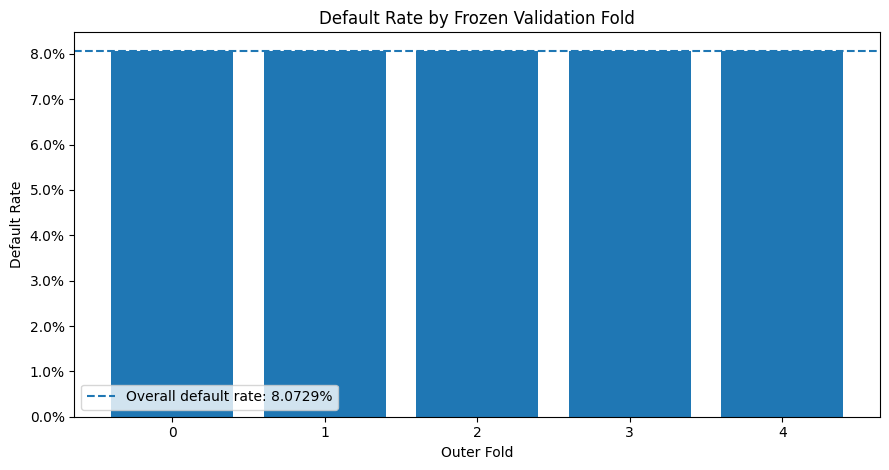

STEP 1.3 COMPLETE
Audit checks passed: 15 of 15
Maximum fold-size difference: 1
Maximum target-rate deviation: 0.00010501%
Minimum defaults in one fold: 4965
Lockbox rows: 61,502
Fold-balance figure: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\figures\step1_fold_default_rates.png


In [9]:
overall_default_rate = float(TARGET.mean())

fold_balance = FOLD_REGISTRY.groupby("outer_fold", observed=True).agg(
    rows=(ID_COLUMN, "size"),
    defaults=(TARGET_COLUMN, "sum")
).reset_index()

fold_balance["non_defaults"] = fold_balance["rows"] - fold_balance["defaults"]
fold_balance["default_rate"] = fold_balance["defaults"] / fold_balance["rows"]
fold_balance["absolute_rate_deviation"] = (fold_balance["default_rate"] - overall_default_rate).abs()
fold_balance["dataset_role"] = np.where(fold_balance["outer_fold"].isin(VALIDATION_DESIGN["development_folds"]), "DEVELOPMENT", "LOCKBOX")

role_masks = {
    "DISCOVERY_TRAIN": FOLD_REGISTRY["discovery_role"].eq("TRAIN").to_numpy(),
    "DISCOVERY_VALID": FOLD_REGISTRY["discovery_role"].eq("VALID").to_numpy(),
    "DEVELOPMENT_POOL": FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT").to_numpy(),
    "LOCKBOX": FOLD_REGISTRY["dataset_role"].eq("LOCKBOX").to_numpy(),
    "FULL_LABELLED": np.ones(len(FOLD_REGISTRY), dtype=bool)
}

role_rows = []

for role, mask in role_masks.items():
    role_target = FOLD_REGISTRY.loc[mask, TARGET_COLUMN]

    role_rows.append({
        "validation_role": role,
        "rows": int(mask.sum()),
        "defaults": int(role_target.sum()),
        "non_defaults": int(len(role_target) - role_target.sum()),
        "default_rate": float(role_target.mean())
    })

validation_role_summary = pd.DataFrame(role_rows)

fold_values = FOLD_REGISTRY["outer_fold"].to_numpy(dtype=np.int8)
row_positions = FOLD_REGISTRY["row_position"].to_numpy(dtype=np.int32)

development_positions = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT"), "row_position"])
lockbox_positions = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["dataset_role"].eq("LOCKBOX"), "row_position"])
discovery_train_set = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["discovery_role"].eq("TRAIN"), "row_position"])
discovery_valid_set = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["discovery_role"].eq("VALID"), "row_position"])

expected_dataset_role = np.where(np.isin(fold_values, VALIDATION_DESIGN["development_folds"]), "DEVELOPMENT", "LOCKBOX")
expected_discovery_role = np.select(
    [np.isin(fold_values, VALIDATION_DESIGN["discovery_train_folds"]), fold_values == VALIDATION_DESIGN["discovery_valid_fold"], fold_values == VALIDATION_DESIGN["lockbox_fold"]],
    ["TRAIN", "VALID", "LOCKBOX"],
    default="UNASSIGNED"
)
expected_development_fold = np.where(np.isin(fold_values, VALIDATION_DESIGN["development_folds"]), fold_values, -1).astype(np.int8)

audit_items = [
    {"check": "REGISTRY_ROW_COUNT", "status": "PASS" if len(FOLD_REGISTRY) == len(TARGET) else "FAIL", "observed": len(FOLD_REGISTRY)},
    {"check": "ROW_POSITION_COMPLETENESS", "status": "PASS" if np.array_equal(row_positions, np.arange(len(TARGET), dtype=np.int32)) else "FAIL", "observed": int(pd.Series(row_positions).nunique())},
    {"check": "IDENTIFIER_UNIQUENESS", "status": "PASS" if FOLD_REGISTRY[ID_COLUMN].is_unique else "FAIL", "observed": FOLD_REGISTRY[ID_COLUMN].nunique()},
    {"check": "IDENTIFIER_ORDER_MATCH", "status": "PASS" if np.array_equal(FOLD_REGISTRY[ID_COLUMN].to_numpy(), TRAIN_ID.to_numpy()) else "FAIL", "observed": len(FOLD_REGISTRY)},
    {"check": "TARGET_ORDER_MATCH", "status": "PASS" if np.array_equal(FOLD_REGISTRY[TARGET_COLUMN].to_numpy(dtype=np.int8), TARGET.to_numpy(dtype=np.int8)) else "FAIL", "observed": int(FOLD_REGISTRY[TARGET_COLUMN].sum())},
    {"check": "EXPECTED_FOLD_VALUES", "status": "PASS" if set(fold_values) == set(range(VALIDATION_DESIGN["outer_folds"])) else "FAIL", "observed": sorted(set(fold_values))},
    {"check": "FOLD_SIZE_BALANCE", "status": "PASS" if int(fold_balance["rows"].max() - fold_balance["rows"].min()) <= 1 else "FAIL", "observed": int(fold_balance["rows"].max() - fold_balance["rows"].min())},
    {"check": "TARGET_RATE_TOLERANCE", "status": "PASS" if float(fold_balance["absolute_rate_deviation"].max()) <= 0.001 else "FAIL", "observed": float(fold_balance["absolute_rate_deviation"].max())},
    {"check": "DATASET_ROLE_MAPPING", "status": "PASS" if np.array_equal(FOLD_REGISTRY["dataset_role"].to_numpy(), expected_dataset_role) else "FAIL", "observed": FOLD_REGISTRY["dataset_role"].nunique()},
    {"check": "DISCOVERY_ROLE_MAPPING", "status": "PASS" if np.array_equal(FOLD_REGISTRY["discovery_role"].to_numpy(), expected_discovery_role) else "FAIL", "observed": FOLD_REGISTRY["discovery_role"].nunique()},
    {"check": "DEVELOPMENT_FOLD_MAPPING", "status": "PASS" if np.array_equal(FOLD_REGISTRY["development_fold"].to_numpy(dtype=np.int8), expected_development_fold) else "FAIL", "observed": sorted(FOLD_REGISTRY["development_fold"].unique())},
    {"check": "DEVELOPMENT_LOCKBOX_ISOLATION", "status": "PASS" if development_positions.isdisjoint(lockbox_positions) else "FAIL", "observed": len(development_positions.intersection(lockbox_positions))},
    {"check": "DISCOVERY_TRAIN_VALID_ISOLATION", "status": "PASS" if discovery_train_set.isdisjoint(discovery_valid_set) else "FAIL", "observed": len(discovery_train_set.intersection(discovery_valid_set))},
    {"check": "DISCOVERY_LOCKBOX_ISOLATION", "status": "PASS" if discovery_train_set.isdisjoint(lockbox_positions) and discovery_valid_set.isdisjoint(lockbox_positions) else "FAIL", "observed": len((discovery_train_set | discovery_valid_set).intersection(lockbox_positions))},
    {"check": "POSITIVE_SUPPORT_IN_EVERY_FOLD", "status": "PASS" if fold_balance["defaults"].gt(0).all() else "FAIL", "observed": int(fold_balance["defaults"].min())}
]

step1_validation_report = pd.DataFrame(audit_items)

fold_balance.to_csv(DIRS["folds"] / "fold_balance_summary.csv", index=False)
validation_role_summary.to_csv(DIRS["folds"] / "validation_role_summary.csv", index=False)
step1_validation_report.to_csv(DIRS["metrics"] / "step1_validation_report.csv", index=False)

assert step1_validation_report["status"].eq("PASS").all(), f"Step 1 validation failed. Review: {DIRS['metrics'] / 'step1_validation_report.csv'}"

display(fold_balance)
display(validation_role_summary)
display(step1_validation_report)

figure_path = DIRS["figures"] / "step1_fold_default_rates.png"

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(fold_balance["outer_fold"].astype(str), fold_balance["default_rate"])
ax.axhline(overall_default_rate, linestyle="--", linewidth=1.5, label=f"Overall default rate: {overall_default_rate:.4%}")
ax.set_title("Default Rate by Frozen Validation Fold")
ax.set_xlabel("Outer Fold")
ax.set_ylabel("Default Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
fig.tight_layout()
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

show_report("STEP 1.3 COMPLETE", [
    ("Audit checks passed", f"{step1_validation_report['status'].eq('PASS').sum()} of {len(step1_validation_report)}"),
    ("Maximum fold-size difference", int(fold_balance["rows"].max() - fold_balance["rows"].min())),
    ("Maximum target-rate deviation", f"{fold_balance['absolute_rate_deviation'].max():.8%}"),
    ("Minimum defaults in one fold", int(fold_balance["defaults"].min())),
    ("Lockbox rows", f"{len(lockbox_positions):,}"),
    ("Fold-balance figure", figure_path)
])

## Step 1.4 — Save the Experiment Contracts and Seal the Final Lockbox

### Actions

- Save the evaluation and experiment contracts.
- Create or validate the lockbox-control file.
- Preserve an already-used lockbox state during notebook reruns.
- Create the standard model-comparison registry without overwriting prior results.
- Save the complete Step 1 checkpoint.

### Experiment Stages

- `SMOKE_TEST`: Compatibility and code testing only
- `DISCOVERY_SCREENING`: Fast family and feature-set screening
- `DEVELOPMENT_CONFIRMATION`: Four-fold development validation
- `LOCKBOX_FINAL_EVALUATION`: One-time final assessment
- `FULL_DATA_REFIT`: Final model trained on all labelled rows

In [10]:
EVALUATION_CONTRACT_PATH = DIRS["manifests"] / "evaluation_contract.json"
EXPERIMENT_PROTOCOL_PATH = DIRS["manifests"] / "experiment_protocols.json"
LOCKBOX_CONTROL_PATH = DIRS["manifests"] / "lockbox_control.json"
MODEL_COMPARISON_PATH = DIRS["metrics"] / "model_comparison_master.csv"
STEP1_SUMMARY_PATH = DIRS["checkpoints"] / "step1_summary.json"

with open(EVALUATION_CONTRACT_PATH, "w", encoding="utf-8") as file:
    json.dump(EVALUATION_CONTRACT, file, indent=2)

with open(EXPERIMENT_PROTOCOL_PATH, "w", encoding="utf-8") as file:
    json.dump(EXPERIMENT_PROTOCOLS, file, indent=2)

if LOCKBOX_CONTROL_PATH.exists():
    with open(LOCKBOX_CONTROL_PATH, "r", encoding="utf-8") as file:
        LOCKBOX_CONTROL = json.load(file)

    if LOCKBOX_CONTROL.get("lockbox_fold") != VALIDATION_DESIGN["lockbox_fold"]:
        raise RuntimeError("The existing lockbox-control file refers to a different lockbox fold.")

    if LOCKBOX_CONTROL.get("status") not in ["SEALED", "USED_ONCE"]:
        raise RuntimeError("The existing lockbox-control file contains an invalid status.")

else:
    LOCKBOX_CONTROL = {
        "status": "SEALED",
        "evaluation_count": 0,
        "lockbox_fold": VALIDATION_DESIGN["lockbox_fold"],
        "allowed_stage": "LOCKBOX_FINAL_EVALUATION",
        "sealed_utc": pd.Timestamp.utcnow().isoformat(),
        "used_utc": None,
        "selected_model_id": None
    }

    with open(LOCKBOX_CONTROL_PATH, "w", encoding="utf-8") as file:
        json.dump(LOCKBOX_CONTROL, file, indent=2)

if MODEL_COMPARISON_PATH.exists():
    existing_result_columns = pd.read_csv(MODEL_COMPARISON_PATH, nrows=0).columns.tolist()
    missing_result_columns = [column for column in RESULT_SCHEMA if column not in existing_result_columns]

    if missing_result_columns:
        raise RuntimeError(f"The existing model-comparison registry is missing columns: {missing_result_columns}")

    comparison_registry_status = "EXISTING_REGISTRY_PRESERVED"

else:
    pd.DataFrame(columns=RESULT_SCHEMA).to_csv(MODEL_COMPARISON_PATH, index=False)
    comparison_registry_status = "EMPTY_REGISTRY_CREATED"

protocol_rows = []

for protocol, details in EXPERIMENT_PROTOCOLS.items():
    protocol_rows.append({
        "protocol": protocol,
        "training_folds": str(details["training_folds"]),
        "validation_folds": str(details["validation_folds"]),
        "purpose": details["purpose"],
        "final_claim_allowed": details["final_claim_allowed"]
    })

protocol_summary = pd.DataFrame(protocol_rows)

development_mask = FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT")
lockbox_mask = FOLD_REGISTRY["dataset_role"].eq("LOCKBOX")
discovery_train_mask = FOLD_REGISTRY["discovery_role"].eq("TRAIN")
discovery_valid_mask = FOLD_REGISTRY["discovery_role"].eq("VALID")

STEP1_SUMMARY = {
    "status": "STEP_1_COMPLETE",
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "training_rows": int(len(FOLD_REGISTRY)),
    "development_rows": int(development_mask.sum()),
    "lockbox_rows": int(lockbox_mask.sum()),
    "discovery_training_rows": int(discovery_train_mask.sum()),
    "discovery_validation_rows": int(discovery_valid_mask.sum()),
    "overall_default_rate": overall_default_rate,
    "development_folds": VALIDATION_DESIGN["development_folds"],
    "lockbox_fold": VALIDATION_DESIGN["lockbox_fold"],
    "registry_source": FOLD_REGISTRY_SOURCE,
    "audit_checks_passed": int(step1_validation_report["status"].eq("PASS").sum()),
    "audit_checks_failed": int(step1_validation_report["status"].ne("PASS").sum()),
    "lockbox_status": LOCKBOX_CONTROL["status"],
    "model_comparison_registry_status": comparison_registry_status,
    "fold_registry": str(FOLD_REGISTRY_PATH),
    "fold_manifest": str(FOLD_MANIFEST_PATH),
    "evaluation_contract": str(EVALUATION_CONTRACT_PATH),
    "experiment_protocols": str(EXPERIMENT_PROTOCOL_PATH),
    "lockbox_control": str(LOCKBOX_CONTROL_PATH),
    "model_comparison_registry": str(MODEL_COMPARISON_PATH),
    "next_step": "STEP_2_BASELINE_RISK_MODELS"
}

with open(STEP1_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(STEP1_SUMMARY, file, indent=2)

display(protocol_summary)

checkpoint_table = pd.DataFrame([
    {"item": "Training rows", "value": len(FOLD_REGISTRY)},
    {"item": "Development rows", "value": int(development_mask.sum())},
    {"item": "Lockbox rows", "value": int(lockbox_mask.sum())},
    {"item": "Discovery training rows", "value": int(discovery_train_mask.sum())},
    {"item": "Discovery validation rows", "value": int(discovery_valid_mask.sum())},
    {"item": "Development folds", "value": str(VALIDATION_DESIGN["development_folds"])},
    {"item": "Lockbox fold", "value": VALIDATION_DESIGN["lockbox_fold"]},
    {"item": "Audit failures", "value": int(step1_validation_report["status"].ne("PASS").sum())},
    {"item": "Lockbox status", "value": LOCKBOX_CONTROL["status"]},
    {"item": "Model registry", "value": comparison_registry_status}
])

display(checkpoint_table)

show_report("STEP 1 COMPLETE — EXPERIMENTAL DESIGN AND FROZEN VALIDATION REGISTRY VERIFIED", [
    ("Training rows", f"{len(FOLD_REGISTRY):,}"),
    ("Development rows", f"{development_mask.sum():,}"),
    ("Lockbox rows", f"{lockbox_mask.sum():,}"),
    ("Discovery training rows", f"{discovery_train_mask.sum():,}"),
    ("Discovery validation rows", f"{discovery_valid_mask.sum():,}"),
    ("Development folds", VALIDATION_DESIGN["development_folds"]),
    ("Sealed lockbox fold", VALIDATION_DESIGN["lockbox_fold"]),
    ("Audit checks passed", f"{step1_validation_report['status'].eq('PASS').sum()} of {len(step1_validation_report)}"),
    ("Lockbox status", LOCKBOX_CONTROL["status"]),
    ("Fold registry", FOLD_REGISTRY_PATH),
    ("Step 1 checkpoint", STEP1_SUMMARY_PATH),
    ("Next step", "STEP 2 — BASELINE RISK MODELS")
])

,protocol,training_folds,validation_folds,purpose,final_claim_allowed
0,DISCOVERY,"[1, 2, 3]",[0],"Fast model-family, feature-set, and broad para...",False
1,DEVELOPMENT_CV,THREE OF DEVELOPMENT FOLDS 0-3,REMAINING DEVELOPMENT FOLD,"Model confirmation, tuning confirmation, calib...",False
2,LOCKBOX,"[0, 1, 2, 3]",[4],One-time final assessment after configuration ...,True
3,FULL_REFIT,"[0, 1, 2, 3, 4]",[],Final full-data refit and test prediction,False


,item,value
0,Training rows,307511
1,Development rows,246009
2,Lockbox rows,61502
3,Discovery training rows,184506
4,Discovery validation rows,61503
5,Development folds,"[0, 1, 2, 3]"
6,Lockbox fold,4
7,Audit failures,0
8,Lockbox status,SEALED
9,Model registry,EXISTING_REGISTRY_PRESERVED


STEP 1 COMPLETE — EXPERIMENTAL DESIGN AND FROZEN VALIDATION REGISTRY VERIFIED
Training rows: 307,511
Development rows: 246,009
Lockbox rows: 61,502
Discovery training rows: 184,506
Discovery validation rows: 61,503
Development folds: [0, 1, 2, 3]
Sealed lockbox fold: 4
Audit checks passed: 15 of 15
Lockbox status: SEALED
Fold registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\folds\frozen_fold_registry.parquet
Step 1 checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step1_summary.json
Next step: STEP 2 — BASELINE RISK MODELS


# Step 2 — Robust Untuned Baseline Model Benchmarking

## Objectives

- Establish trustworthy untuned model-family baselines.
- Use the complete Compact feature set for every actual baseline model.
- Evaluate models across the full development pool using four-fold out-of-fold predictions.
- Keep the sealed lockbox completely untouched.
- Detect library, GPU, memory, and preprocessing problems before long training begins.
- Compare linear, bagging, and boosting model families fairly.
- Save every completed fold immediately for interruption-safe execution.

## Models

- Prior probability: Metric and alignment sanity reference
- Logistic Regression: Strong linear baseline
- Random Forest: Bagging-family baseline
- LightGBM: Histogram boosting baseline with Windows-safe backend selection
- XGBoost: CUDA histogram boosting baseline
- CatBoost: GPU boosting baseline

## Reliability Design

- Every model first passes a small preflight test.
- Full training starts only after all preflight tests pass.
- Every fold runs in an isolated subprocess.
- Failed primary configurations are automatically retried with safer settings.
- PASS and ERROR results share the same result schema.
- Completed full-fold checkpoints can be reused safely.
- Random Forest runs last because it is less important than the boosting candidates.

## Validation Boundary

- Development folds: 0, 1, 2, and 3
- Evaluation: Four-fold development OOF
- Lockbox fold: 4
- Lockbox rows used: 0
- Test rows used: 0

## Step 2.1 — Configure the Baseline Experiment

### Actions

- Restore the minimum Step 1 state.
- Verify the frozen fold registry and sealed lockbox.
- Define fixed untuned model configurations.
- Define one result schema for successful and failed workers.
- Define common metric and reporting helpers.
- Prioritise strong boosting models before slower bagging models.

In [12]:
import os
import gc
import json
import time
import hashlib
import platform
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score, roc_curve

PROJECT_ROOT = Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk")

DIRS = {
    "feature_package": PROJECT_ROOT / "Feature_engineering" / "final_package",
    "model_root": PROJECT_ROOT / "Model_training",
    "checkpoints": PROJECT_ROOT / "Model_training" / "checkpoints",
    "folds": PROJECT_ROOT / "Model_training" / "folds",
    "metrics": PROJECT_ROOT / "Model_training" / "metrics",
    "oof": PROJECT_ROOT / "Model_training" / "oof_predictions",
    "models": PROJECT_ROOT / "Model_training" / "models",
    "figures": PROJECT_ROOT / "Model_training" / "figures",
    "manifests": PROJECT_ROOT / "Model_training" / "manifests",
    "workers": PROJECT_ROOT / "Model_training" / "temporary_workers"
}

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

PATHS = {
    "train": DIRS["feature_package"] / "data" / "train_feature_engineered.parquet",
    "compact_features": DIRS["feature_package"] / "metadata" / "compact_feature_list.csv",
    "fold_registry": DIRS["folds"] / "frozen_fold_registry.parquet",
    "fold_manifest": DIRS["manifests"] / "fold_registry_manifest.json",
    "lockbox_control": DIRS["manifests"] / "lockbox_control.json",
    "model_comparison": DIRS["metrics"] / "model_comparison_master.csv"
}

for required_path in ["train", "compact_features", "fold_registry", "fold_manifest", "lockbox_control"]:
    assert PATHS[required_path].exists(), f"Missing required file: {PATHS[required_path]}"

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
WORKER_VERSION = "3.0"

FOLD_REGISTRY = pd.read_parquet(PATHS["fold_registry"])
COMPACT_FEATURES = pd.read_csv(PATHS["compact_features"])["feature"].astype(str).tolist()

with open(PATHS["fold_manifest"], "r", encoding="utf-8") as file:
    FOLD_MANIFEST = json.load(file)

with open(PATHS["lockbox_control"], "r", encoding="utf-8") as file:
    LOCKBOX_CONTROL = json.load(file)

assert LOCKBOX_CONTROL["status"] == "SEALED", "The final lockbox is not sealed."
assert int(LOCKBOX_CONTROL["evaluation_count"]) == 0, "The lockbox has already been evaluated."
assert set(FOLD_REGISTRY.loc[FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT"), "outer_fold"].unique()) == {0, 1, 2, 3}
assert set(FOLD_REGISTRY.loc[FOLD_REGISTRY["dataset_role"].eq("LOCKBOX"), "outer_fold"].unique()) == {4}

STEP2_CONFIG = {
    "random_state": 42,
    "development_folds": [0, 1, 2, 3],
    "lockbox_fold": 4,
    "preflight_train_rows": 12_000,
    "preflight_valid_rows": 4_000,
    "preflight_timeout_seconds": 900,
    "full_timeout_seconds": 7_200,
    "models": {
        "PRIOR": {
            "model_id": "STEP2_PRIOR_REFERENCE",
            "family": "Prior Probability",
            "slug": "prior",
            "required": True
        },
        "LOGISTIC": {
            "model_id": "STEP2_LOGISTIC_L2_COMPACT",
            "family": "Logistic Regression",
            "slug": "logistic_l2",
            "required": True,
            "C": 1.0,
            "max_iter": 1_500,
            "tolerance": 0.001
        },
        "RANDOM_FOREST": {
            "model_id": "STEP2_RANDOM_FOREST_COMPACT",
            "family": "Random Forest",
            "slug": "random_forest",
            "required": False,
            "primary": {"n_estimators": 240, "max_depth": 12, "min_samples_leaf": 25, "max_samples": 0.65},
            "safe": {"n_estimators": 160, "max_depth": 10, "min_samples_leaf": 40, "max_samples": 0.50}
        },
        "LIGHTGBM": {
            "model_id": "STEP2_LIGHTGBM_COMPACT",
            "family": "LightGBM",
            "slug": "lightgbm",
            "required": False,
            "n_estimators": 3_000,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 50,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_lambda": 1.0,
            "max_bin": 63,
            "early_stopping_rounds": 100
        },
        "XGBOOST": {
            "model_id": "STEP2_XGBOOST_COMPACT",
            "family": "XGBoost",
            "slug": "xgboost",
            "required": False,
            "num_boost_round": 3_000,
            "learning_rate": 0.05,
            "max_depth": 6,
            "min_child_weight": 5.0,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_lambda": 1.0,
            "max_bin": 128,
            "early_stopping_rounds": 100
        },
        "CATBOOST": {
            "model_id": "STEP2_CATBOOST_COMPACT",
            "family": "CatBoost",
            "slug": "catboost",
            "required": False,
            "iterations": 3_000,
            "learning_rate": 0.05,
            "depth": 7,
            "border_count": 128,
            "gpu_ram_part": 0.85,
            "early_stopping_rounds": 100
        }
    }
}

PREFLIGHT_ORDER = ["PRIOR", "XGBOOST", "LIGHTGBM", "CATBOOST", "LOGISTIC", "RANDOM_FOREST"]
FULL_TRAINING_ORDER = ["PRIOR", "XGBOOST", "LIGHTGBM", "CATBOOST", "LOGISTIC", "RANDOM_FOREST"]

RESULT_COLUMNS = [
    "model_key", "model_id", "model_family", "mode", "validation_fold", "status", "backend", "profile_used", "run_signature",
    "training_rows", "validation_rows", "feature_count", "encoded_feature_count", "training_default_rate", "validation_default_rate",
    "matrix_seconds", "fit_seconds", "prediction_seconds", "worker_total_seconds", "best_iteration", "roc_auc", "pr_auc",
    "log_loss", "brier_score", "ks_statistic", "prediction_mean", "worker_return_code", "worker_timeout",
    "checkpoint_reused", "prediction_path", "stdout_log", "stderr_log", "error_type", "error", "traceback"
]

DISPLAY_COLUMNS = [
    "model_key", "validation_fold", "status", "backend", "profile_used", "fit_seconds", "roc_auc", "pr_auc",
    "log_loss", "brier_score", "best_iteration", "checkpoint_reused"
]

RESULT_SCHEMA = [
    "model_id", "model_family", "stage", "protocol", "feature_set", "fold", "training_rows", "validation_rows", "feature_count",
    "roc_auc", "pr_auc", "log_loss", "brier_score", "ks_statistic", "calibration_slope", "calibration_intercept",
    "fit_seconds", "prediction_seconds", "best_iteration", "parameter_id", "prediction_path", "model_path", "status", "notes"
]

def show_report(title, values):
    print("=" * 100)
    print(title)

    for label, value in values:
        print(f"{label}: {value}")

    print("=" * 100)

def configuration_hash(data):
    serialised = json.dumps(data, sort_keys=True, default=str).encode("utf-8")
    return hashlib.blake2b(serialised, digest_size=16).hexdigest()

def evaluate_predictions(y_true, probability):
    y_true = np.asarray(y_true, dtype=np.int8)
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)

    fpr, tpr, _ = roc_curve(y_true, probability)
    positive_count = max(int(y_true.sum()), 1)

    captures = {}

    for fraction in [0.05, 0.10, 0.20]:
        selected_rows = max(1, int(np.ceil(len(y_true) * fraction)))
        selected_positions = np.argpartition(-probability, selected_rows - 1)[:selected_rows]
        capture = float(y_true[selected_positions].sum() / positive_count)
        captures[f"capture_top_{int(fraction * 100)}"] = capture
        captures[f"lift_top_{int(fraction * 100)}"] = float(capture / fraction)

    calibration_intercept = np.nan
    calibration_slope = np.nan

    if np.unique(probability).size > 1:
        probability_logit = np.log(probability / (1 - probability)).reshape(-1, 1)

        try:
            calibration_model = LogisticRegression(C=1_000_000, solver="lbfgs", max_iter=1_000)
            calibration_model.fit(probability_logit, y_true)
            calibration_intercept = float(calibration_model.intercept_[0])
            calibration_slope = float(calibration_model.coef_[0, 0])
        except Exception:
            pass

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "ks_statistic": float(np.max(tpr - fpr)),
        "calibration_intercept": calibration_intercept,
        "calibration_slope": calibration_slope,
        "prediction_mean": float(probability.mean()),
        "observed_default_rate": float(y_true.mean()),
        **captures
    }

STEP2_CONFIG_PATH = DIRS["manifests"] / "step2_baseline_config.json"

with open(STEP2_CONFIG_PATH, "w", encoding="utf-8") as file:
    json.dump(STEP2_CONFIG, file, indent=2)

model_contract = pd.DataFrame([
    {
        "execution_order": position + 1,
        "model_key": model_key,
        "model_family": STEP2_CONFIG["models"][model_key]["family"],
        "feature_set": "NONE" if model_key == "PRIOR" else "COMPACT",
        "required": STEP2_CONFIG["models"][model_key]["required"],
        "untuned": True
    }
    for position, model_key in enumerate(FULL_TRAINING_ORDER)
])

display(model_contract)

show_report("STEP 2.1 COMPLETE", [
    ("Operating system", platform.system()),
    ("Development folds", STEP2_CONFIG["development_folds"]),
    ("Compact predictors", len(COMPACT_FEATURES)),
    ("Lockbox status", LOCKBOX_CONTROL["status"]),
    ("Full-training order", FULL_TRAINING_ORDER),
    ("Configuration signature", configuration_hash(STEP2_CONFIG))
])

,execution_order,model_key,model_family,feature_set,required,untuned
0,1,PRIOR,Prior Probability,NONE,True,True
1,2,XGBOOST,XGBoost,COMPACT,False,True
2,3,LIGHTGBM,LightGBM,COMPACT,False,True
3,4,CATBOOST,CatBoost,COMPACT,False,True
4,5,LOGISTIC,Logistic Regression,COMPACT,True,True
5,6,RANDOM_FOREST,Random Forest,COMPACT,False,True


STEP 2.1 COMPLETE
Operating system: Windows
Development folds: [0, 1, 2, 3]
Compact predictors: 1369
Lockbox status: SEALED
Full-training order: ['PRIOR', 'XGBOOST', 'LIGHTGBM', 'CATBOOST', 'LOGISTIC', 'RANDOM_FOREST']
Configuration signature: a998dcdd927e788bbba8b8e8ee9d6080


## Step 2.2 — Prepare the Compact Development Dataset

### Actions

- Load only the identifier, target, and Compact predictors.
- Attach frozen outer-fold assignments.
- Remove the sealed lockbox before workers receive the data.
- Classify predictors into numerical and categorical groups.
- Save a restart-safe development parquet and manifest.
- Verify zero lockbox rows and exact source alignment.

In [13]:
STEP2_DATA_PATH = DIRS["checkpoints"] / "step2_compact_development.parquet"
STEP2_DATA_MANIFEST_PATH = DIRS["manifests"] / "step2_data_manifest.json"

def dtype_family(dtype):
    if pd.api.types.is_bool_dtype(dtype):
        return "boolean"

    if pd.api.types.is_numeric_dtype(dtype):
        return "numeric"

    if pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype) or isinstance(dtype, pd.CategoricalDtype):
        return "categorical"

    return "unsupported"

required_columns = [ID_COLUMN, TARGET_COLUMN] + COMPACT_FEATURES
preparation_start = time.perf_counter()

if "DATA" in globals() and isinstance(DATA, dict) and "train" in DATA and all(column in DATA["train"].columns for column in required_columns):
    compact_source = DATA["train"][required_columns].copy()
    source_mode = "REUSED_IN_MEMORY_DATA"
else:
    compact_source = pd.read_parquet(PATHS["train"], columns=required_columns)
    source_mode = "LOADED_SELECTED_PARQUET_COLUMNS"

assert len(compact_source) == len(FOLD_REGISTRY), "Compact data and fold registry row counts differ."
assert np.array_equal(compact_source[ID_COLUMN].to_numpy(), FOLD_REGISTRY[ID_COLUMN].to_numpy()), "Applicant order mismatch."
assert np.array_equal(compact_source[TARGET_COLUMN].to_numpy(dtype=np.int8), FOLD_REGISTRY[TARGET_COLUMN].to_numpy(dtype=np.int8)), "Target order mismatch."

compact_source.insert(0, "row_position", FOLD_REGISTRY["row_position"].to_numpy(dtype=np.int32))
compact_source.insert(3, "outer_fold", FOLD_REGISTRY["outer_fold"].to_numpy(dtype=np.int8))

STEP2_DATA = compact_source.loc[compact_source["outer_fold"].isin(STEP2_CONFIG["development_folds"])].reset_index(drop=True)

NUMERIC_FEATURES = [feature for feature in COMPACT_FEATURES if dtype_family(STEP2_DATA[feature].dtype) in {"numeric", "boolean"}]
CATEGORICAL_FEATURES = [feature for feature in COMPACT_FEATURES if dtype_family(STEP2_DATA[feature].dtype) == "categorical"]
UNSUPPORTED_FEATURES = [feature for feature in COMPACT_FEATURES if dtype_family(STEP2_DATA[feature].dtype) == "unsupported"]

assert not UNSUPPORTED_FEATURES, f"Unsupported predictor dtypes: {UNSUPPORTED_FEATURES[:20]}"
assert set(STEP2_DATA["outer_fold"].unique()) == set(STEP2_CONFIG["development_folds"])
assert not STEP2_DATA["outer_fold"].eq(STEP2_CONFIG["lockbox_fold"]).any()
assert STEP2_DATA["row_position"].is_unique
assert STEP2_DATA[ID_COLUMN].is_unique
assert STEP2_DATA[COMPACT_FEATURES].columns.tolist() == COMPACT_FEATURES

STEP2_DATA.to_parquet(STEP2_DATA_PATH, index=False, compression="zstd")

STEP2_DATA_MANIFEST = {
    "status": "VERIFIED",
    "created_utc": pd.Timestamp.utcnow().isoformat(),
    "source_mode": source_mode,
    "data_path": str(STEP2_DATA_PATH),
    "training_dataset_signature": FOLD_MANIFEST["dataset_signature"],
    "development_rows": int(len(STEP2_DATA)),
    "development_folds": STEP2_CONFIG["development_folds"],
    "lockbox_rows": int(STEP2_DATA["outer_fold"].eq(STEP2_CONFIG["lockbox_fold"]).sum()),
    "compact_features": COMPACT_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "feature_count": len(COMPACT_FEATURES),
    "feature_hash": configuration_hash(COMPACT_FEATURES),
    "target_rate": float(STEP2_DATA[TARGET_COLUMN].mean()),
    "memory_gb": float(STEP2_DATA.memory_usage(deep=True).sum() / (1024 ** 3)),
    "preparation_seconds": float(time.perf_counter() - preparation_start)
}

with open(STEP2_DATA_MANIFEST_PATH, "w", encoding="utf-8") as file:
    json.dump(STEP2_DATA_MANIFEST, file, indent=2)

fold_profile = STEP2_DATA.groupby("outer_fold", observed=True).agg(rows=(ID_COLUMN, "size"), defaults=(TARGET_COLUMN, "sum")).reset_index()
fold_profile["default_rate"] = fold_profile["defaults"] / fold_profile["rows"]

data_profile = pd.DataFrame([
    {"item": "Development rows", "value": len(STEP2_DATA)},
    {"item": "Compact predictors", "value": len(COMPACT_FEATURES)},
    {"item": "Numerical predictors", "value": len(NUMERIC_FEATURES)},
    {"item": "Categorical predictors", "value": len(CATEGORICAL_FEATURES)},
    {"item": "Lockbox rows included", "value": STEP2_DATA_MANIFEST["lockbox_rows"]},
    {"item": "Target rate", "value": STEP2_DATA_MANIFEST["target_rate"]},
    {"item": "Memory GB", "value": STEP2_DATA_MANIFEST["memory_gb"]},
    {"item": "Preparation seconds", "value": STEP2_DATA_MANIFEST["preparation_seconds"]}
])

display(fold_profile)
display(data_profile)

show_report("STEP 2.2 COMPLETE", [
    ("Source mode", source_mode),
    ("Development shape", STEP2_DATA.shape),
    ("Numerical predictors", len(NUMERIC_FEATURES)),
    ("Categorical predictors", len(CATEGORICAL_FEATURES)),
    ("Lockbox rows included", STEP2_DATA_MANIFEST["lockbox_rows"]),
    ("Saved development data", STEP2_DATA_PATH)
])

del compact_source
gc.collect()

,outer_fold,rows,defaults,default_rate
0,0,61503,4965,0.080728
1,1,61502,4965,0.080729
2,2,61502,4965,0.080729
3,3,61502,4965,0.080729


,item,value
0,Development rows,"246,009.000000"
1,Compact predictors,"1,369.000000"
2,Numerical predictors,"1,353.000000"
3,Categorical predictors,16.000000
4,Lockbox rows included,0.000000
5,Target rate,0.080729
6,Memory GB,1.408633
7,Preparation seconds,10.912085


STEP 2.2 COMPLETE
Source mode: REUSED_IN_MEMORY_DATA
Development shape: (246009, 1373)
Numerical predictors: 1353
Categorical predictors: 16
Lockbox rows included: 0
Saved development data: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step2_compact_development.parquet


120

## Step 2.3 — Run Model Compatibility and Memory Preflight

### Purpose

Before full four-fold training, every model must successfully complete a small representative experiment.

### Preflight Checks

- Required library imports
- Preprocessing compatibility
- Categorical handling
- CPU and GPU backend availability
- Early-stopping API compatibility
- Prediction generation
- Metric generation
- Result-schema completeness
- Isolated-worker execution
- Automatic safe-profile retry

Full training must not begin when any preflight model fails.

## Step 2.3 — Class-Based Model Preflight and Execution Framework

### Architecture

- `Step2BaselineRunner` manages configuration, subprocess execution, checkpoints, logs, and result tables.
- `BaselineModelWorker` performs fold-level preprocessing, training, prediction, and evaluation.
- The worker class runs inside an isolated Python subprocess.
- Native GPU or C++ failures cannot terminate the notebook kernel.

### Preflight Policy

- Every available execution profile is tested on a representative stratified subset.
- Primary and safe profiles are tested separately.
- Full training uses the strongest profile that passed preflight.
- Full training is blocked when a model has no successful profile.
- Failed results retain the same schema as successful results.

### Execution Profiles

- Logistic Regression: CPU primary
- Random Forest: Standard-memory and reduced-memory CPU profiles
- LightGBM: GPU primary and deterministic CPU fallback
- XGBoost: CUDA primary and CPU fallback
- CatBoost: GPU primary and CPU fallback

In [14]:
import os
import gc
import json
import time
import shutil
import hashlib
import subprocess
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


class Step2BaselineRunner:
    RESULT_COLUMNS = [
        "model_key", "model_id", "model_family", "mode", "validation_fold", "status", "backend", "profile_used", "run_signature",
        "training_rows", "validation_rows", "feature_count", "encoded_feature_count", "training_default_rate", "validation_default_rate",
        "matrix_seconds", "fit_seconds", "prediction_seconds", "worker_total_seconds", "best_iteration", "roc_auc", "pr_auc",
        "log_loss", "brier_score", "ks_statistic", "prediction_mean", "worker_return_code", "worker_timeout",
        "checkpoint_reused", "prediction_path", "stdout_log", "stderr_log", "error_type", "error", "traceback"
    ]

    DISPLAY_COLUMNS = [
        "model_key", "validation_fold", "status", "backend", "profile_used", "fit_seconds", "roc_auc", "pr_auc",
        "log_loss", "brier_score", "best_iteration", "checkpoint_reused", "error"
    ]

    PROFILE_MAP = {
        "PRIOR": ["primary"],
        "LOGISTIC": ["primary"],
        "RANDOM_FOREST": ["primary", "safe"],
        "LIGHTGBM": ["primary", "safe"],
        "XGBOOST": ["primary", "safe"],
        "CATBOOST": ["primary", "safe"]
    }

    PREFLIGHT_ORDER = ["PRIOR", "XGBOOST", "LIGHTGBM", "CATBOOST", "LOGISTIC", "RANDOM_FOREST"]
    FULL_TRAINING_ORDER = ["PRIOR", "XGBOOST", "LIGHTGBM", "CATBOOST", "LOGISTIC", "RANDOM_FOREST"]

    def __init__(self, directories, config, data_path, data_manifest_path, config_path, worker_version="4.0"):
        self.directories = directories
        self.config = config
        self.data_path = Path(data_path)
        self.data_manifest_path = Path(data_manifest_path)
        self.config_path = Path(config_path)
        self.worker_version = worker_version

        self.worker_root = Path(self.directories["workers"])
        self.preflight_root = self.worker_root / "step2_preflight"
        self.full_root = Path(self.directories["oof"]) / "step2_folds"
        self.worker_module_path = self.worker_root / "step2_baseline_worker_class.py"
        self.preflight_results_path = Path(self.directories["metrics"]) / "step2_preflight_results.csv"
        self.profile_registry_path = Path(self.directories["manifests"]) / "step2_preflight_profile_registry.json"
        self.fold_metrics_path = Path(self.directories["metrics"]) / "step2_baseline_fold_metrics.csv"
        self.completion_registry_path = Path(self.directories["checkpoints"]) / "step2_fold_completion_registry.csv"

        for directory in [self.worker_root, self.preflight_root, self.full_root]:
            directory.mkdir(parents=True, exist_ok=True)

        assert self.data_path.exists(), f"Missing Step 2 development data: {self.data_path}"
        assert self.data_manifest_path.exists(), f"Missing Step 2 data manifest: {self.data_manifest_path}"
        assert self.config_path.exists(), f"Missing Step 2 configuration: {self.config_path}"

        with open(self.data_manifest_path, "r", encoding="utf-8") as file:
            self.data_manifest = json.load(file)

        self._write_worker_module()

    @staticmethod
    def _hash(data):
        payload = json.dumps(data, sort_keys=True, default=str).encode("utf-8")
        return hashlib.blake2b(payload, digest_size=16).hexdigest()

    def _normalise_result(self, result):
        return {column: result.get(column, None) for column in self.RESULT_COLUMNS}

    def _signature(self, mode, model_key, validation_fold, profile):
        return self._hash({
            "worker_version": self.worker_version,
            "mode": mode,
            "model_key": model_key,
            "model_config": self.config["models"][model_key],
            "validation_fold": validation_fold,
            "profile": profile,
            "feature_hash": self.data_manifest["feature_hash"],
            "dataset_signature": self.data_manifest["training_dataset_signature"]
        })

    def _model_directory(self, root_directory, model_key):
        model_slug = self.config["models"][model_key]["slug"]
        model_directory = Path(root_directory) / model_slug
        model_directory.mkdir(parents=True, exist_ok=True)
        return model_directory

    def _attempt_paths(self, root_directory, mode, model_key, validation_fold, profile):
        model_directory = self._model_directory(root_directory, model_key)
        prefix = f"{mode.lower()}_fold_{validation_fold}_{profile}"

        return {
            "result": model_directory / f"{prefix}_result.json",
            "prediction": model_directory / f"{prefix}_predictions.parquet",
            "stdout": model_directory / f"{prefix}_stdout.log",
            "stderr": model_directory / f"{prefix}_stderr.log"
        }

    def _canonical_paths(self, root_directory, mode, model_key, validation_fold):
        model_directory = self._model_directory(root_directory, model_key)
        prefix = f"{mode.lower()}_fold_{validation_fold}"

        return {
            "result": model_directory / f"{prefix}_metrics.json",
            "prediction": model_directory / f"{prefix}_predictions.parquet"
        }

    def _run_attempt(self, mode, model_key, validation_fold, profile, root_directory):
        paths = self._attempt_paths(root_directory, mode, model_key, validation_fold, profile)
        run_signature = self._signature(mode, model_key, validation_fold, profile)

        for path in paths.values():
            if path.exists():
                path.unlink()

        timeout_seconds = self.config["preflight_timeout_seconds"] if mode == "PREFLIGHT" else self.config["full_timeout_seconds"]

        command = [
            os.sys.executable,
            str(self.worker_module_path),
            mode,
            model_key,
            str(validation_fold),
            profile,
            str(self.data_path),
            str(self.data_manifest_path),
            str(self.config_path),
            str(paths["prediction"]),
            str(paths["result"]),
            run_signature
        ]

        environment = os.environ.copy()
        environment["CUDA_VISIBLE_DEVICES"] = "0"
        environment["OMP_NUM_THREADS"] = str(os.cpu_count() or 8)
        environment["MKL_NUM_THREADS"] = str(os.cpu_count() or 8)
        environment["OPENBLAS_NUM_THREADS"] = str(os.cpu_count() or 8)
        environment["NUMEXPR_NUM_THREADS"] = str(os.cpu_count() or 8)

        worker_timeout = False
        start = time.perf_counter()

        try:
            process = subprocess.run(command, capture_output=True, text=True, timeout=timeout_seconds, env=environment)
            worker_return_code = process.returncode
            stdout = process.stdout or ""
            stderr = process.stderr or ""

        except subprocess.TimeoutExpired as error:
            worker_return_code = None
            worker_timeout = True
            stdout = error.stdout.decode(errors="replace") if isinstance(error.stdout, bytes) else (error.stdout or "")
            stderr = error.stderr.decode(errors="replace") if isinstance(error.stderr, bytes) else (error.stderr or "")

        worker_total_seconds = time.perf_counter() - start

        paths["stdout"].write_text(stdout, encoding="utf-8", errors="replace")
        paths["stderr"].write_text(stderr, encoding="utf-8", errors="replace")

        if paths["result"].exists():
            with open(paths["result"], "r", encoding="utf-8") as file:
                result = json.load(file)
        else:
            result = {
                "model_key": model_key,
                "model_id": self.config["models"][model_key]["model_id"],
                "model_family": self.config["models"][model_key]["family"],
                "mode": mode,
                "validation_fold": validation_fold,
                "status": "NATIVE_PROCESS_FAILURE",
                "profile_used": profile,
                "run_signature": run_signature,
                "error_type": "NativeProcessFailure",
                "error": f"Worker terminated without a result file. Return code: {worker_return_code}"
            }

        result.update({
            "worker_total_seconds": worker_total_seconds,
            "worker_return_code": worker_return_code,
            "worker_timeout": worker_timeout,
            "checkpoint_reused": False,
            "prediction_path": str(paths["prediction"]),
            "stdout_log": str(paths["stdout"]),
            "stderr_log": str(paths["stderr"])
        })

        return self._normalise_result(result)

    def _checkpoint_is_valid(self, mode, model_key, validation_fold, allowed_profiles, root_directory):
        paths = self._canonical_paths(root_directory, mode, model_key, validation_fold)

        if not paths["result"].exists() or not paths["prediction"].exists():
            return None

        with open(paths["result"], "r", encoding="utf-8") as file:
            result = json.load(file)

        profile = result.get("profile_used")

        if profile not in allowed_profiles:
            return None

        expected_signature = self._signature(mode, model_key, validation_fold, profile)

        if result.get("run_signature") != expected_signature:
            return None

        if not str(result.get("status", "")).startswith("PASS"):
            return None

        result["checkpoint_reused"] = True
        result["prediction_path"] = str(paths["prediction"])

        return self._normalise_result(result)

    def _run_job(self, mode, model_key, validation_fold, profiles, root_directory):
        if mode == "FULL":
            checkpoint = self._checkpoint_is_valid(mode, model_key, validation_fold, profiles, root_directory)

            if checkpoint is not None:
                return checkpoint

        canonical_paths = self._canonical_paths(root_directory, mode, model_key, validation_fold)
        attempts = []
        final_result = None

        for profile in profiles:
            attempt = self._run_attempt(mode, model_key, validation_fold, profile, root_directory)
            attempts.append(attempt)
            final_result = attempt

            if str(attempt["status"]).startswith("PASS"):
                attempt_prediction = Path(attempt["prediction_path"])

                if not attempt_prediction.exists():
                    attempt["status"] = "ERROR"
                    attempt["error_type"] = "MissingPredictionFile"
                    attempt["error"] = "Worker reported PASS but did not save the prediction file."
                    final_result = attempt
                    continue

                shutil.copy2(attempt_prediction, canonical_paths["prediction"])
                final_result["prediction_path"] = str(canonical_paths["prediction"])
                break

        final_result["attempted_profiles"] = [attempt["profile_used"] for attempt in attempts]
        final_result["checkpoint_reused"] = False

        with open(canonical_paths["result"], "w", encoding="utf-8") as file:
            json.dump(final_result, file, indent=2)

        return self._normalise_result(final_result)

    def run_preflight(self):
        results = []
        profile_registry = {}

        for model_key in self.PREFLIGHT_ORDER:
            family = self.config["models"][model_key]["family"]
            model_results = []

            print("\n" + "=" * 100)
            print(f"Preflight: {family}")
            print("=" * 100)

            for profile in self.PROFILE_MAP[model_key]:
                print(f"Profile {profile}...", end=" ")

                result = self._run_job("PREFLIGHT", model_key, 0, [profile], self.preflight_root)
                results.append(result)
                model_results.append(result)

                if str(result["status"]).startswith("PASS"):
                    print(f"PASS | {result['backend']} | {float(result['fit_seconds']):.2f} sec")
                else:
                    print(f"FAIL | {result['error']}")
                    print(f"Log: {result['stderr_log']}")

            passed_profiles = [result["profile_used"] for result in model_results if str(result["status"]).startswith("PASS")]

            if "primary" in passed_profiles:
                selected_profile = "primary"
            elif "safe" in passed_profiles:
                selected_profile = "safe"
            else:
                selected_profile = None

            profile_registry[model_key] = {
                "selected_profile": selected_profile,
                "passed_profiles": passed_profiles,
                "all_profiles": self.PROFILE_MAP[model_key]
            }

            display(pd.DataFrame(model_results).reindex(columns=self.DISPLAY_COLUMNS + ["stderr_log"]))

        preflight_table = pd.DataFrame(results).reindex(columns=self.RESULT_COLUMNS)
        preflight_table.to_csv(self.preflight_results_path, index=False)

        with open(self.profile_registry_path, "w", encoding="utf-8") as file:
            json.dump(profile_registry, file, indent=2)

        failed_models = [model_key for model_key, details in profile_registry.items() if details["selected_profile"] is None]

        show_report("STEP 2.3 PREFLIGHT COMPLETE", [
            ("Preflight attempts", len(preflight_table)),
            ("Successful attempts", int(preflight_table["status"].astype(str).str.startswith("PASS").sum())),
            ("Failed attempts", int((~preflight_table["status"].astype(str).str.startswith("PASS")).sum())),
            ("Models with a selected profile", len(profile_registry) - len(failed_models)),
            ("Models without a valid profile", failed_models),
            ("Full training permitted", len(failed_models) == 0),
            ("Profile registry", self.profile_registry_path)
        ])

        if failed_models:
            raise RuntimeError(f"Preflight failed for these models: {failed_models}. Full training was not started.")

        return preflight_table, profile_registry

    def run_full_training(self):
        assert self.profile_registry_path.exists(), "Missing preflight profile registry. Run Step 2.3 first."

        with open(self.profile_registry_path, "r", encoding="utf-8") as file:
            profile_registry = json.load(file)

        fold_results = []

        for model_key in self.FULL_TRAINING_ORDER:
            family = self.config["models"][model_key]["family"]
            selected_profile = profile_registry[model_key]["selected_profile"]
            passed_profiles = profile_registry[model_key]["passed_profiles"]

            fallback_profiles = [profile for profile in passed_profiles if profile != selected_profile]
            execution_profiles = [selected_profile] + fallback_profiles

            print("\n" + "=" * 100)
            print(f"Starting {family}")
            print(f"Execution profiles: {execution_profiles}")
            print("=" * 100)

            for validation_fold in self.config["development_folds"]:
                print(f"Fold {validation_fold}...", end=" ")

                result = self._run_job("FULL", model_key, validation_fold, execution_profiles, self.full_root)
                fold_results.append(result)

                if str(result["status"]).startswith("PASS"):
                    source = "checkpoint" if result["checkpoint_reused"] else f"trained using {result['profile_used']}"
                    print(f"{result['status']} | {float(result['fit_seconds']):.2f} sec | {source}")
                else:
                    print(f"{result['status']} | {result['error']}")
                    print(f"Log: {result['stderr_log']}")

                pd.DataFrame(fold_results).reindex(columns=self.RESULT_COLUMNS).to_csv(self.fold_metrics_path, index=False)

            current_results = pd.DataFrame([result for result in fold_results if result["model_key"] == model_key])
            display(current_results.reindex(columns=self.DISPLAY_COLUMNS + ["stderr_log"]))

        fold_table = pd.DataFrame(fold_results).reindex(columns=self.RESULT_COLUMNS)
        fold_table.to_csv(self.fold_metrics_path, index=False)

        completion_registry = fold_table.reindex(columns=[
            "model_key", "validation_fold", "status", "backend", "profile_used", "checkpoint_reused",
            "worker_return_code", "prediction_path", "stderr_log", "error"
        ])

        completion_registry.to_csv(self.completion_registry_path, index=False)

        successful_mask = fold_table["status"].astype(str).str.startswith("PASS")

        show_report("STEP 2.4 FULL TRAINING COMPLETE", [
            ("Expected fold runs", len(self.FULL_TRAINING_ORDER) * len(self.config["development_folds"])),
            ("Successful fold runs", int(successful_mask.sum())),
            ("Failed fold runs", int((~successful_mask).sum())),
            ("Reused checkpoints", int(fold_table["checkpoint_reused"].fillna(False).astype(bool).sum())),
            ("Fold metrics", self.fold_metrics_path),
            ("Completion registry", self.completion_registry_path)
        ])

        return fold_table

    @staticmethod
    def _worker_source():
        return textwrap.dedent(
            r'''
            import os
            import sys
            import gc
            import json
            import time
            import platform
            import traceback
            import warnings

            import numpy as np
            import pandas as pd

            from sklearn.compose import ColumnTransformer
            from sklearn.ensemble import RandomForestClassifier
            from sklearn.impute import SimpleImputer
            from sklearn.linear_model import LogisticRegression
            from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score, roc_curve
            from sklearn.model_selection import StratifiedShuffleSplit
            from sklearn.pipeline import Pipeline
            from sklearn.preprocessing import OneHotEncoder, StandardScaler

            warnings.filterwarnings("ignore")


            class BaselineModelWorker:
                def __init__(self, mode, model_key, validation_fold, profile, data_path, manifest_path, config_path, prediction_path, result_path, run_signature):
                    self.mode = mode
                    self.model_key = model_key
                    self.validation_fold = validation_fold
                    self.profile = profile
                    self.data_path = data_path
                    self.prediction_path = prediction_path
                    self.result_path = result_path
                    self.run_signature = run_signature

                    with open(manifest_path, "r", encoding="utf-8") as file:
                        self.manifest = json.load(file)

                    with open(config_path, "r", encoding="utf-8") as file:
                        self.config = json.load(file)

                    self.model_config = self.config["models"][self.model_key]
                    self.features = self.manifest["compact_features"]
                    self.numeric_features = self.manifest["numeric_features"]
                    self.categorical_features = self.manifest["categorical_features"]
                    self.numeric_set = set(self.numeric_features)

                def empty_result(self):
                    return {
                        "model_key": self.model_key,
                        "model_id": self.model_config["model_id"],
                        "model_family": self.model_config["family"],
                        "mode": self.mode,
                        "validation_fold": self.validation_fold,
                        "status": "ERROR",
                        "backend": None,
                        "profile_used": self.profile,
                        "run_signature": self.run_signature,
                        "training_rows": None,
                        "validation_rows": None,
                        "feature_count": 0 if self.model_key == "PRIOR" else len(self.features),
                        "encoded_feature_count": None,
                        "training_default_rate": None,
                        "validation_default_rate": None,
                        "matrix_seconds": None,
                        "fit_seconds": None,
                        "prediction_seconds": None,
                        "best_iteration": None,
                        "roc_auc": None,
                        "pr_auc": None,
                        "log_loss": None,
                        "brier_score": None,
                        "ks_statistic": None,
                        "prediction_mean": None,
                        "error_type": None,
                        "error": None,
                        "traceback": None
                    }

                def limit_stratified(self, frame, maximum_rows):
                    if len(frame) <= maximum_rows:
                        return frame.reset_index(drop=True)

                    splitter = StratifiedShuffleSplit(n_splits=1, train_size=maximum_rows, random_state=self.config["random_state"])
                    positions, _ = next(splitter.split(np.zeros(len(frame), dtype=np.int8), frame["TARGET"]))

                    return frame.iloc[positions].reset_index(drop=True)

                @staticmethod
                def calculate_metrics(y_true, probability):
                    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)
                    fpr, tpr, _ = roc_curve(y_true, probability)

                    return {
                        "roc_auc": float(roc_auc_score(y_true, probability)),
                        "pr_auc": float(average_precision_score(y_true, probability)),
                        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
                        "brier_score": float(brier_score_loss(y_true, probability)),
                        "ks_statistic": float(np.max(tpr - fpr)),
                        "prediction_mean": float(probability.mean())
                    }

                def prepare_logistic_frames(self, train_frame, valid_frame):
                    train_prepared = train_frame.copy()
                    valid_prepared = valid_frame.copy()

                    for feature in self.numeric_features:
                        train_prepared[feature] = pd.to_numeric(train_prepared[feature], errors="coerce").astype("float32")
                        valid_prepared[feature] = pd.to_numeric(valid_prepared[feature], errors="coerce").astype("float32")

                    for feature in self.categorical_features:
                        train_prepared[feature] = train_prepared[feature].astype(object).where(train_prepared[feature].notna(), np.nan)
                        valid_prepared[feature] = valid_prepared[feature].astype(object).where(valid_prepared[feature].notna(), np.nan)

                    return train_prepared, valid_prepared

                def prepare_catboost_frames(self, train_frame, valid_frame):
                    train_prepared = train_frame.copy()
                    valid_prepared = valid_frame.copy()

                    for feature in self.numeric_features:
                        train_prepared[feature] = pd.to_numeric(train_prepared[feature], errors="coerce").astype("float32")
                        valid_prepared[feature] = pd.to_numeric(valid_prepared[feature], errors="coerce").astype("float32")

                    for feature in self.categorical_features:
                        train_prepared[feature] = train_prepared[feature].astype("string").fillna("__MISSING__").astype(str)
                        valid_prepared[feature] = valid_prepared[feature].astype("string").fillna("__MISSING__").astype(str)

                    return train_prepared, valid_prepared

                def encode_float_matrix(self, train_frame, valid_frame, impute=False):
                    X_train = np.empty((len(train_frame), len(self.features)), dtype=np.float32)
                    X_valid = np.empty((len(valid_frame), len(self.features)), dtype=np.float32)

                    for feature_index, feature in enumerate(self.features):
                        if feature in self.numeric_set:
                            X_train[:, feature_index] = pd.to_numeric(train_frame[feature], errors="coerce").to_numpy(dtype=np.float32, na_value=np.nan)
                            X_valid[:, feature_index] = pd.to_numeric(valid_frame[feature], errors="coerce").to_numpy(dtype=np.float32, na_value=np.nan)
                        else:
                            train_values = train_frame[feature].astype("string").fillna("__MISSING__")
                            valid_values = valid_frame[feature].astype("string").fillna("__MISSING__")
                            categories = pd.Index(train_values.unique())

                            train_codes = pd.Categorical(train_values, categories=categories).codes.astype(np.float32)
                            valid_codes = pd.Categorical(valid_values, categories=categories).codes.astype(np.float32)

                            train_codes[train_codes < 0] = np.nan
                            valid_codes[valid_codes < 0] = np.nan

                            X_train[:, feature_index] = train_codes
                            X_valid[:, feature_index] = valid_codes

                    if impute:
                        all_missing_columns = np.isnan(X_train).all(axis=0)

                        if all_missing_columns.any():
                            X_train[:, all_missing_columns] = 0.0
                            X_valid[:, all_missing_columns] = 0.0

                        imputer = SimpleImputer(strategy="median", copy=False)
                        X_train = imputer.fit_transform(X_train).astype(np.float32, copy=False)
                        X_valid = imputer.transform(X_valid).astype(np.float32, copy=False)

                    return X_train, X_valid

                def fit_prior(self, y_train, validation_rows):
                    fit_start = time.perf_counter()
                    prevalence = float(y_train.mean())
                    fit_seconds = time.perf_counter() - fit_start

                    prediction_start = time.perf_counter()
                    probability = np.full(validation_rows, prevalence, dtype=np.float32)
                    prediction_seconds = time.perf_counter() - prediction_start

                    return probability, {
                        "backend": "CONSTANT_REFERENCE",
                        "matrix_seconds": 0.0,
                        "fit_seconds": fit_seconds,
                        "prediction_seconds": prediction_seconds,
                        "best_iteration": 0,
                        "encoded_feature_count": 0,
                        "status": "PASS"
                    }

                def fit_logistic(self, X_train_frame, X_valid_frame, y_train):
                    train_prepared, valid_prepared = self.prepare_logistic_frames(X_train_frame, X_valid_frame)

                    try:
                        encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32, sparse_output=True)
                    except TypeError:
                        encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32, sparse=True)

                    numeric_pipeline = Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler(with_mean=False))
                    ])

                    categorical_pipeline = Pipeline([
                        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
                        ("encoder", encoder)
                    ])

                    preprocessor = ColumnTransformer([
                        ("numeric", numeric_pipeline, self.numeric_features),
                        ("categorical", categorical_pipeline, self.categorical_features)
                    ], remainder="drop", sparse_threshold=1.0, n_jobs=-1)

                    maximum_iterations = min(self.model_config["max_iter"], 150) if self.mode == "PREFLIGHT" else self.model_config["max_iter"]

                    model = LogisticRegression(
                        penalty="l2",
                        C=self.model_config["C"],
                        solver="saga",
                        max_iter=maximum_iterations,
                        tol=self.model_config["tolerance"],
                        class_weight=None,
                        n_jobs=-1,
                        random_state=self.config["random_state"]
                    )

                    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])

                    fit_start = time.perf_counter()
                    pipeline.fit(train_prepared, y_train)
                    fit_seconds = time.perf_counter() - fit_start

                    prediction_start = time.perf_counter()
                    probability = pipeline.predict_proba(valid_prepared)[:, 1]
                    prediction_seconds = time.perf_counter() - prediction_start

                    best_iteration = int(np.max(pipeline.named_steps["model"].n_iter_))

                    try:
                        encoded_count = len(pipeline.named_steps["preprocessor"].get_feature_names_out())
                    except Exception:
                        encoded_count = len(self.features)

                    status = "PASS_WITH_CONVERGENCE_REVIEW" if self.mode == "FULL" and best_iteration >= maximum_iterations else "PASS"

                    return probability, {
                        "backend": "CPU_ALL_THREADS",
                        "matrix_seconds": 0.0,
                        "fit_seconds": fit_seconds,
                        "prediction_seconds": prediction_seconds,
                        "best_iteration": best_iteration,
                        "encoded_feature_count": encoded_count,
                        "status": status
                    }

                def fit_random_forest(self, X_train_frame, X_valid_frame, y_train):
                    matrix_start = time.perf_counter()
                    X_train, X_valid = self.encode_float_matrix(X_train_frame, X_valid_frame, impute=True)
                    matrix_seconds = time.perf_counter() - matrix_start

                    profile_config = self.model_config["safe"] if self.profile == "safe" else self.model_config["primary"]
                    tree_count = min(profile_config["n_estimators"], 30) if self.mode == "PREFLIGHT" else profile_config["n_estimators"]

                    model = RandomForestClassifier(
                        n_estimators=tree_count,
                        max_depth=profile_config["max_depth"],
                        min_samples_leaf=profile_config["min_samples_leaf"],
                        max_features="sqrt",
                        max_samples=profile_config["max_samples"],
                        bootstrap=True,
                        class_weight=None,
                        n_jobs=-1,
                        random_state=self.config["random_state"]
                    )

                    fit_start = time.perf_counter()
                    model.fit(X_train, y_train)
                    fit_seconds = time.perf_counter() - fit_start

                    prediction_start = time.perf_counter()
                    probability = model.predict_proba(X_valid)[:, 1]
                    prediction_seconds = time.perf_counter() - prediction_start

                    return probability, {
                        "backend": "CPU_REDUCED_MEMORY" if self.profile == "safe" else "CPU_ALL_THREADS",
                        "matrix_seconds": matrix_seconds,
                        "fit_seconds": fit_seconds,
                        "prediction_seconds": prediction_seconds,
                        "best_iteration": tree_count,
                        "encoded_feature_count": X_train.shape[1],
                        "status": "PASS"
                    }

                def fit_lightgbm(self, X_train_frame, X_valid_frame, y_train, y_valid):
                    import lightgbm as lgb

                    matrix_start = time.perf_counter()
                    X_train, X_valid = self.encode_float_matrix(X_train_frame, X_valid_frame, impute=False)
                    matrix_seconds = time.perf_counter() - matrix_start

                    estimator_count = min(self.model_config["n_estimators"], 250) if self.mode == "PREFLIGHT" else self.model_config["n_estimators"]
                    stopping_rounds = min(self.model_config["early_stopping_rounds"], 30) if self.mode == "PREFLIGHT" else self.model_config["early_stopping_rounds"]

                    if self.profile == "safe":
                        device_type = "cpu"
                    elif platform.system() == "Windows":
                        device_type = "gpu"
                    else:
                        device_type = "cuda"

                    parameters = {
                        "objective": "binary",
                        "n_estimators": estimator_count,
                        "learning_rate": self.model_config["learning_rate"],
                        "num_leaves": self.model_config["num_leaves"],
                        "min_child_samples": self.model_config["min_child_samples"],
                        "subsample": self.model_config["subsample"],
                        "subsample_freq": 1,
                        "colsample_bytree": self.model_config["colsample_bytree"],
                        "reg_lambda": self.model_config["reg_lambda"],
                        "max_bin": self.model_config["max_bin"],
                        "random_state": self.config["random_state"],
                        "n_jobs": -1,
                        "device_type": device_type,
                        "verbosity": -1
                    }

                    if device_type == "cpu":
                        parameters["deterministic"] = True
                        parameters["force_col_wise"] = True
                    else:
                        parameters["gpu_device_id"] = 0

                    model = lgb.LGBMClassifier(**parameters)

                    fit_start = time.perf_counter()
                    model.fit(
                        X_train,
                        y_train,
                        eval_set=[(X_valid, y_valid)],
                        eval_metric="auc",
                        callbacks=[
                            lgb.early_stopping(stopping_rounds=stopping_rounds, first_metric_only=True, verbose=False),
                            lgb.log_evaluation(0)
                        ]
                    )
                    fit_seconds = time.perf_counter() - fit_start

                    prediction_start = time.perf_counter()
                    probability = model.predict_proba(X_valid, num_iteration=model.best_iteration_)[:, 1]
                    prediction_seconds = time.perf_counter() - prediction_start

                    return probability, {
                        "backend": f"LIGHTGBM_{device_type.upper()}",
                        "matrix_seconds": matrix_seconds,
                        "fit_seconds": fit_seconds,
                        "prediction_seconds": prediction_seconds,
                        "best_iteration": int(model.best_iteration_ or estimator_count),
                        "encoded_feature_count": X_train.shape[1],
                        "status": "PASS"
                    }

                def fit_xgboost(self, X_train_frame, X_valid_frame, y_train, y_valid):
                    import xgboost as xgb

                    matrix_start = time.perf_counter()
                    X_train, X_valid = self.encode_float_matrix(X_train_frame, X_valid_frame, impute=False)

                    if self.profile == "safe":
                        dtrain = xgb.DMatrix(X_train, label=y_train, missing=np.nan)
                        dvalid = xgb.DMatrix(X_valid, label=y_valid, missing=np.nan)
                    else:
                        dtrain = xgb.QuantileDMatrix(X_train, y_train, max_bin=self.model_config["max_bin"], missing=np.nan)
                        dvalid = xgb.QuantileDMatrix(X_valid, y_valid, ref=dtrain, max_bin=self.model_config["max_bin"], missing=np.nan)

                    matrix_seconds = time.perf_counter() - matrix_start
                    boosting_rounds = min(self.model_config["num_boost_round"], 250) if self.mode == "PREFLIGHT" else self.model_config["num_boost_round"]
                    stopping_rounds = min(self.model_config["early_stopping_rounds"], 30) if self.mode == "PREFLIGHT" else self.model_config["early_stopping_rounds"]

                    parameters = {
                        "objective": "binary:logistic",
                        "eval_metric": ["auc", "logloss"],
                        "tree_method": "hist",
                        "device": "cpu" if self.profile == "safe" else "cuda",
                        "learning_rate": self.model_config["learning_rate"],
                        "max_depth": 5 if self.profile == "safe" else self.model_config["max_depth"],
                        "min_child_weight": self.model_config["min_child_weight"],
                        "subsample": self.model_config["subsample"],
                        "colsample_bytree": self.model_config["colsample_bytree"],
                        "reg_lambda": self.model_config["reg_lambda"],
                        "max_bin": 64 if self.profile == "safe" else self.model_config["max_bin"],
                        "nthread": os.cpu_count() or 8,
                        "seed": self.config["random_state"]
                    }

                    fit_start = time.perf_counter()
                    model = xgb.train(
                        parameters,
                        dtrain,
                        num_boost_round=boosting_rounds,
                        evals=[(dvalid, "valid")],
                        early_stopping_rounds=stopping_rounds,
                        verbose_eval=False
                    )
                    fit_seconds = time.perf_counter() - fit_start

                    best_iteration = int(getattr(model, "best_iteration", boosting_rounds - 1))

                    prediction_start = time.perf_counter()
                    probability = model.predict(dvalid, iteration_range=(0, best_iteration + 1))
                    prediction_seconds = time.perf_counter() - prediction_start

                    return probability, {
                        "backend": "XGBOOST_CPU_SAFE" if self.profile == "safe" else "XGBOOST_CUDA_QUANTILE_DMAT",
                        "matrix_seconds": matrix_seconds,
                        "fit_seconds": fit_seconds,
                        "prediction_seconds": prediction_seconds,
                        "best_iteration": best_iteration,
                        "encoded_feature_count": X_train.shape[1],
                        "status": "PASS"
                    }

                def fit_catboost(self, X_train_frame, X_valid_frame, y_train, y_valid):
                    from catboost import CatBoostClassifier

                    train_prepared, valid_prepared = self.prepare_catboost_frames(X_train_frame, X_valid_frame)

                    iterations = min(self.model_config["iterations"], 250) if self.mode == "PREFLIGHT" else self.model_config["iterations"]
                    stopping_rounds = min(self.model_config["early_stopping_rounds"], 30) if self.mode == "PREFLIGHT" else self.model_config["early_stopping_rounds"]

                    if self.profile == "safe":
                        task_type = "CPU"
                        depth = 6
                        border_count = 64
                        extra_parameters = {}
                    else:
                        task_type = "GPU"
                        depth = self.model_config["depth"]
                        border_count = self.model_config["border_count"]
                        extra_parameters = {
                            "devices": "0",
                            "gpu_ram_part": self.model_config["gpu_ram_part"],
                            "gpu_cat_features_storage": "CpuPinnedMemory",
                            "max_ctr_complexity": 1,
                            "boosting_type": "Plain"
                        }

                    model = CatBoostClassifier(
                        iterations=iterations,
                        learning_rate=self.model_config["learning_rate"],
                        depth=depth,
                        loss_function="Logloss",
                        eval_metric="AUC",
                        random_seed=self.config["random_state"],
                        task_type=task_type,
                        thread_count=-1,
                        border_count=border_count,
                        verbose=False,
                        allow_writing_files=False,
                        **extra_parameters
                    )

                    fit_start = time.perf_counter()
                    model.fit(
                        train_prepared,
                        y_train,
                        cat_features=self.categorical_features,
                        eval_set=(valid_prepared, y_valid),
                        use_best_model=True,
                        early_stopping_rounds=stopping_rounds,
                        verbose=False
                    )
                    fit_seconds = time.perf_counter() - fit_start

                    prediction_start = time.perf_counter()
                    probability = model.predict_proba(valid_prepared)[:, 1]
                    prediction_seconds = time.perf_counter() - prediction_start

                    return probability, {
                        "backend": f"CATBOOST_{task_type}",
                        "matrix_seconds": 0.0,
                        "fit_seconds": fit_seconds,
                        "prediction_seconds": prediction_seconds,
                        "best_iteration": int(model.get_best_iteration()),
                        "encoded_feature_count": len(self.features),
                        "status": "PASS"
                    }

                def run(self):
                    result = self.empty_result()

                    try:
                        data = pd.read_parquet(self.data_path)

                        train_data = data.loc[data["outer_fold"].ne(self.validation_fold)].reset_index(drop=True)
                        valid_data = data.loc[data["outer_fold"].eq(self.validation_fold)].reset_index(drop=True)

                        if self.mode == "PREFLIGHT":
                            train_data = self.limit_stratified(train_data, self.config["preflight_train_rows"])
                            valid_data = self.limit_stratified(valid_data, self.config["preflight_valid_rows"])

                        X_train_frame = train_data[self.features]
                        X_valid_frame = valid_data[self.features]
                        y_train = train_data["TARGET"].to_numpy(dtype=np.int8)
                        y_valid = valid_data["TARGET"].to_numpy(dtype=np.int8)

                        result.update({
                            "training_rows": int(len(train_data)),
                            "validation_rows": int(len(valid_data)),
                            "training_default_rate": float(y_train.mean()),
                            "validation_default_rate": float(y_valid.mean())
                        })

                        if self.model_key == "PRIOR":
                            probability, metadata = self.fit_prior(y_train, len(valid_data))
                        elif self.model_key == "LOGISTIC":
                            probability, metadata = self.fit_logistic(X_train_frame, X_valid_frame, y_train)
                        elif self.model_key == "RANDOM_FOREST":
                            probability, metadata = self.fit_random_forest(X_train_frame, X_valid_frame, y_train)
                        elif self.model_key == "LIGHTGBM":
                            probability, metadata = self.fit_lightgbm(X_train_frame, X_valid_frame, y_train, y_valid)
                        elif self.model_key == "XGBOOST":
                            probability, metadata = self.fit_xgboost(X_train_frame, X_valid_frame, y_train, y_valid)
                        elif self.model_key == "CATBOOST":
                            probability, metadata = self.fit_catboost(X_train_frame, X_valid_frame, y_train, y_valid)
                        else:
                            raise ValueError(f"Unknown model key: {self.model_key}")

                        probability = np.asarray(probability, dtype=np.float32)

                        if len(probability) != len(valid_data):
                            raise RuntimeError("Prediction row count does not match validation row count.")

                        if not np.isfinite(probability).all():
                            raise RuntimeError("Predictions contain NaN or infinite values.")

                        if not np.logical_and(probability >= 0, probability <= 1).all():
                            raise RuntimeError("Predictions fall outside the [0, 1] interval.")

                        prediction_table = pd.DataFrame({
                            "row_position": valid_data["row_position"].to_numpy(dtype=np.int32),
                            "SK_ID_CURR": valid_data["SK_ID_CURR"].to_numpy(),
                            "TARGET": y_valid,
                            "outer_fold": self.validation_fold,
                            "probability": probability
                        })

                        prediction_table.to_parquet(self.prediction_path, index=False, compression="zstd")

                        result.update(metadata)
                        result.update(self.calculate_metrics(y_valid, probability))

                    except Exception as error:
                        result.update({
                            "status": "ERROR",
                            "error_type": type(error).__name__,
                            "error": str(error),
                            "traceback": traceback.format_exc()
                        })

                    with open(self.result_path, "w", encoding="utf-8") as file:
                        json.dump(result, file, indent=2)

                    return result


            if __name__ == "__main__":
                worker = BaselineModelWorker(
                    mode=sys.argv[1],
                    model_key=sys.argv[2],
                    validation_fold=int(sys.argv[3]),
                    profile=sys.argv[4],
                    data_path=sys.argv[5],
                    manifest_path=sys.argv[6],
                    config_path=sys.argv[7],
                    prediction_path=sys.argv[8],
                    result_path=sys.argv[9],
                    run_signature=sys.argv[10]
                )

                worker.run()
            '''
        )

    def _write_worker_module(self):
        self.worker_module_path.write_text(self._worker_source(), encoding="utf-8")


STEP2_RUNNER = Step2BaselineRunner(
    directories=DIRS,
    config=STEP2_CONFIG,
    data_path=STEP2_DATA_PATH,
    data_manifest_path=STEP2_DATA_MANIFEST_PATH,
    config_path=STEP2_CONFIG_PATH,
    worker_version="4.0"
)

STEP2_PREFLIGHT_RESULTS, STEP2_PROFILE_REGISTRY = STEP2_RUNNER.run_preflight()


Preflight: Prior Probability
Profile primary... PASS | CONSTANT_REFERENCE | 0.00 sec


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,PRIOR,0,PASS,CONSTANT_REFERENCE,primary,0.000009,0.500000,0.080750,0.280597,0.074229,0,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...



Preflight: XGBoost
Profile primary... PASS | XGBOOST_CUDA_QUANTILE_DMAT | 0.81 sec
Profile safe... PASS | XGBOOST_CPU_SAFE | 1.46 sec


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,XGBOOST,0,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,0.809075,0.756098,0.227126,0.249832,0.069027,70,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
1,XGBOOST,0,PASS,XGBOOST_CPU_SAFE,safe,1.463792,0.764596,0.245895,0.247146,0.068467,97,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...



Preflight: LightGBM
Profile primary... FAIL | GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
Log: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\temporary_workers\step2_preflight\lightgbm\preflight_fold_0_primary_stderr.log
Profile safe... PASS | LIGHTGBM_CPU | 2.09 sec


...


Preflight: Logistic Regression
Profile primary... PASS | CPU_ALL_THREADS | 10.24 sec


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,LOGISTIC,0,PASS,CPU_ALL_THREADS,primary,10.242639,0.740444,0.232265,0.254024,0.069642,150,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...



Preflight: Random Forest
Profile primary... PASS | CPU_ALL_THREADS | 0.17 sec
Profile safe... PASS | CPU_REDUCED_MEMORY | 0.13 sec


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,RANDOM_FOREST,0,PASS,CPU_ALL_THREADS,primary,0.174063,0.708993,0.202960,0.258676,0.070469,30,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
1,RANDOM_FOREST,0,PASS,CPU_REDUCED_MEMORY,safe,0.134433,0.724125,0.211956,0.256482,0.070084,30,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...


STEP 2.3 PREFLIGHT COMPLETE
Preflight attempts: 10
Successful attempts: 9
Failed attempts: 1
Models with a selected profile: 6
Models without a valid profile: []
Full training permitted: True
Profile registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\manifests\step2_preflight_profile_registry.json


## Step 2.4 — Run Full Four-Fold OOF Training

### Execution Policy

- Use the profile selected during Step 2.3.
- Use only profiles that successfully passed preflight.
- Train on three development folds and predict the remaining fold.
- Save every fold result and prediction immediately.
- Reuse valid matching checkpoints after interruption.
- Try a preflight-approved fallback only when the selected profile fails at full scale.
- Keep the sealed lockbox completely unavailable.

### Execution Priority

1. Prior probability
2. XGBoost
3. LightGBM
4. CatBoost
5. Logistic Regression
6. Random Forest

In [15]:
assert "STEP2_RUNNER" in globals(), "Run the revised Step 2.3 cell first."
assert STEP2_RUNNER.profile_registry_path.exists(), "The preflight profile registry is missing."

with open(STEP2_RUNNER.profile_registry_path, "r", encoding="utf-8") as file:
    verified_profiles = json.load(file)

unresolved_models = [
    model_key
    for model_key, profile_details in verified_profiles.items()
    if profile_details.get("selected_profile") is None
]

assert not unresolved_models, f"These models have no verified execution profile: {unresolved_models}"

STEP2_FOLD_RESULTS = STEP2_RUNNER.run_full_training()

display(
    STEP2_FOLD_RESULTS.reindex(
        columns=[
            "model_key", "validation_fold", "status", "backend", "profile_used",
            "fit_seconds", "roc_auc", "pr_auc", "log_loss", "brier_score",
            "best_iteration", "checkpoint_reused", "error"
        ]
    )
)


Starting Prior Probability
Execution profiles: ['primary']
Fold 0... PASS | 0.00 sec | trained using primary
Fold 1... PASS | 0.00 sec | trained using primary
Fold 2... PASS | 0.00 sec | trained using primary
Fold 3... PASS | 0.00 sec | trained using primary


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,PRIOR,0,PASS,CONSTANT_REFERENCE,primary,0.000080,0.500000,0.080728,0.280543,0.074211,0,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
1,PRIOR,1,PASS,CONSTANT_REFERENCE,primary,0.000082,0.500000,0.080729,0.280546,0.074212,0,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
2,PRIOR,2,PASS,CONSTANT_REFERENCE,primary,0.000088,0.500000,0.080729,0.280546,0.074212,0,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
3,PRIOR,3,PASS,CONSTANT_REFERENCE,primary,0.000089,0.500000,0.080729,0.280546,0.074212,0,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...



Starting XGBoost
Execution profiles: ['primary', 'safe']
Fold 0... PASS | 17.48 sec | trained using primary
Fold 1... PASS | 18.97 sec | trained using primary
Fold 2... PASS | 13.91 sec | trained using primary
Fold 3... PASS | 15.27 sec | trained using primary


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,XGBOOST,0,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,17.481315,0.788014,0.285739,0.236512,0.065668,444,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
1,XGBOOST,1,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,18.970937,0.796630,0.296220,0.233771,0.065200,486,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
2,XGBOOST,2,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,13.907818,0.787321,0.275218,0.237344,0.066077,339,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
3,XGBOOST,3,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,15.267763,0.794840,0.292013,0.234373,0.065310,371,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...



Starting LightGBM
Execution profiles: ['safe']
Fold 0... PASS | 32.69 sec | trained using safe
Fold 1... PASS | 28.79 sec | trained using safe
Fold 2... PASS | 27.28 sec | trained using safe
Fold 3... PASS | 35.68 sec | trained using safe


...

,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,LOGISTIC,0,PASS,CPU_ALL_THREADS,primary,292.103841,0.773925,0.261264,0.241976,0.066887,345,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
1,LOGISTIC,1,PASS,CPU_ALL_THREADS,primary,413.143661,0.783265,0.270264,0.239339,0.066440,508,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
2,LOGISTIC,2,PASS,CPU_ALL_THREADS,primary,389.961948,0.774942,0.264212,0.241324,0.066774,492,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
3,LOGISTIC,3,PASS,CPU_ALL_THREADS,primary,381.535023,0.779849,0.267163,0.240496,0.066588,470,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...



Starting Random Forest
Execution profiles: ['primary', 'safe']
Fold 0... PASS | 24.08 sec | trained using primary
Fold 1... PASS | 24.15 sec | trained using primary
Fold 2... PASS | 24.30 sec | trained using primary
Fold 3... PASS | 24.97 sec | trained using primary


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error,stderr_log
0,RANDOM_FOREST,0,PASS,CPU_ALL_THREADS,primary,24.084823,0.760064,0.246322,0.247776,0.068150,240,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
1,RANDOM_FOREST,1,PASS,CPU_ALL_THREADS,primary,24.152340,0.765282,0.253083,0.246678,0.067931,240,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
2,RANDOM_FOREST,2,PASS,CPU_ALL_THREADS,primary,24.301466,0.756791,0.243719,0.248360,0.068268,240,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...
3,RANDOM_FOREST,3,PASS,CPU_ALL_THREADS,primary,24.974613,0.764831,0.248781,0.246905,0.068009,240,False,None,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...


STEP 2.4 FULL TRAINING COMPLETE
Expected fold runs: 24
Successful fold runs: 24
Failed fold runs: 0
Reused checkpoints: 0
Fold metrics: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\metrics\step2_baseline_fold_metrics.csv
Completion registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step2_fold_completion_registry.csv


,model_key,validation_fold,status,backend,profile_used,fit_seconds,roc_auc,pr_auc,log_loss,brier_score,best_iteration,checkpoint_reused,error
0,PRIOR,0,PASS,CONSTANT_REFERENCE,primary,0.000080,0.500000,0.080728,0.280543,0.074211,0,False,None
1,PRIOR,1,PASS,CONSTANT_REFERENCE,primary,0.000082,0.500000,0.080729,0.280546,0.074212,0,False,None
2,PRIOR,2,PASS,CONSTANT_REFERENCE,primary,0.000088,0.500000,0.080729,0.280546,0.074212,0,False,None
3,PRIOR,3,PASS,CONSTANT_REFERENCE,primary,0.000089,0.500000,0.080729,0.280546,0.074212,0,False,None
4,XGBOOST,0,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,17.481315,0.788014,0.285739,0.236512,0.065668,444,False,None
5,XGBOOST,1,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,18.970937,0.796630,0.296220,0.233771,0.065200,486,False,None
6,XGBOOST,2,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,13.907818,0.787321,0.275218,0.237344,0.066077,339,False,None
7,XGBOOST,3,PASS,XGBOOST_CUDA_QUANTILE_DMAT,primary,15.267763,0.794840,0.292013,0.234373,0.065310,371,False,None
8,LIGHTGBM,0,PASS,LIGHTGBM_CPU,safe,32.691464,0.787874,0.284545,0.236657,0.065713,554,False,None
9,LIGHTGBM,1,PASS,LIGHTGBM_CPU,safe,28.786952,0.797225,0.294151,0.233809,0.065256,384,False,None


## Step 2.5 — Aggregate OOF Predictions and Finalise the Baseline Study

### Analyses

- Reconstruct complete development OOF predictions.
- Verify exact row, identifier, target, and fold alignment.
- Calculate discrimination and probability-quality metrics.
- Measure fold stability and operational lift.
- Compare all actual models against Logistic Regression.
- Measure prediction correlation and high-risk overlap.
- Update the shared model-comparison registry.
- Preserve optional-model failures as review items instead of corrupting the experiment.

### Hard Completion Requirements

- Prior probability complete
- Logistic Regression complete
- At least two nonlinear models complete
- Complete OOF coverage for each accepted model
- Zero duplicate predictions
- Zero missing predictions
- Zero lockbox predictions
- All probabilities finite and inside the valid range

,model_family,feature_count,roc_auc,pr_auc,log_loss,brier_score,ks_statistic,capture_top_10,lift_top_10,fold_roc_auc_std,total_fit_seconds,primary_profile_folds,safe_profile_folds,status
0,CatBoost,1369,0.793372,0.288452,0.235049,0.065469,0.445466,0.386657,3.866566,0.005398,156.946008,4,0,PASS
1,LightGBM,1369,0.791953,0.287065,0.235479,0.065569,0.445436,0.381621,3.816213,0.004557,124.433735,0,4,PASS
2,XGBoost,1369,0.791686,0.287068,0.235500,0.065564,0.441484,0.382679,3.826788,0.004723,65.627834,4,0,PASS
3,Logistic Regression,1369,0.777949,0.265180,0.240784,0.066672,0.419510,0.360222,3.602216,0.004363,"1,476.744472",4,0,PASS
4,Random Forest,1369,0.761699,0.247733,0.247430,0.068090,0.390282,0.344814,3.448137,0.004058,97.513241,4,0,PASS
5,Prior Probability,0,0.499998,0.080729,0.280546,0.074212,0.000000,0.098892,0.988922,0.000000,0.000339,4,0,PASS


,model_key,model_family,roc_auc_delta_vs_logistic,pr_auc_delta_vs_logistic,log_loss_improvement_vs_logistic,brier_improvement_vs_logistic
0,CATBOOST,CatBoost,0.015422,0.023272,0.005734,0.001204
1,LIGHTGBM,LightGBM,0.014004,0.021885,0.005305,0.001103
2,XGBOOST,XGBoost,0.013737,0.021888,0.005284,0.001108
3,LOGISTIC,Logistic Regression,0.000000,0.000000,0.000000,0.000000
4,RANDOM_FOREST,Random Forest,-0.016250,-0.017447,-0.006646,-0.001417
5,PRIOR,Prior Probability,-0.277951,-0.184451,-0.039762,-0.007539


,CATBOOST,LIGHTGBM,XGBOOST,LOGISTIC,RANDOM_FOREST
CATBOOST,1.000000,0.947577,0.946372,0.890289,0.850761
LIGHTGBM,0.947577,1.000000,0.955714,0.884444,0.848217
XGBOOST,0.946372,0.955714,1.000000,0.879453,0.843307
LOGISTIC,0.890289,0.884444,0.879453,1.000000,0.866777
RANDOM_FOREST,0.850761,0.848217,0.843307,0.866777,1.000000


,CATBOOST,LIGHTGBM,XGBOOST,LOGISTIC,RANDOM_FOREST
CATBOOST,1.000000,0.823666,0.819235,0.735336,0.689687
LIGHTGBM,0.823666,1.000000,0.833665,0.727206,0.689037
XGBOOST,0.819235,0.833665,1.000000,0.719767,0.679728
LOGISTIC,0.735336,0.727206,0.719767,1.000000,0.712532
RANDOM_FOREST,0.689687,0.689037,0.679728,0.712532,1.000000


,check,status,observed,expected
0,PRIOR_FOUR_FOLDS_COMPLETE,PASS,4,4
1,PRIOR_FOLD_0_ROW_COUNT,PASS,True,True
2,PRIOR_FOLD_0_ROW_POSITION,PASS,True,True
3,PRIOR_FOLD_0_IDENTIFIER,PASS,True,True
4,PRIOR_FOLD_0_TARGET,PASS,True,True
...,...,...,...,...
193,LOGISTIC_COMPLETED,PASS,True,True
194,AT_LEAST_TWO_NONLINEAR_MODELS,PASS,4,2
195,LOCKBOX_REMAINS_SEALED,PASS,SEALED,SEALED
196,PRIOR_AUC_SANITY,PASS,0.499998,0.500000


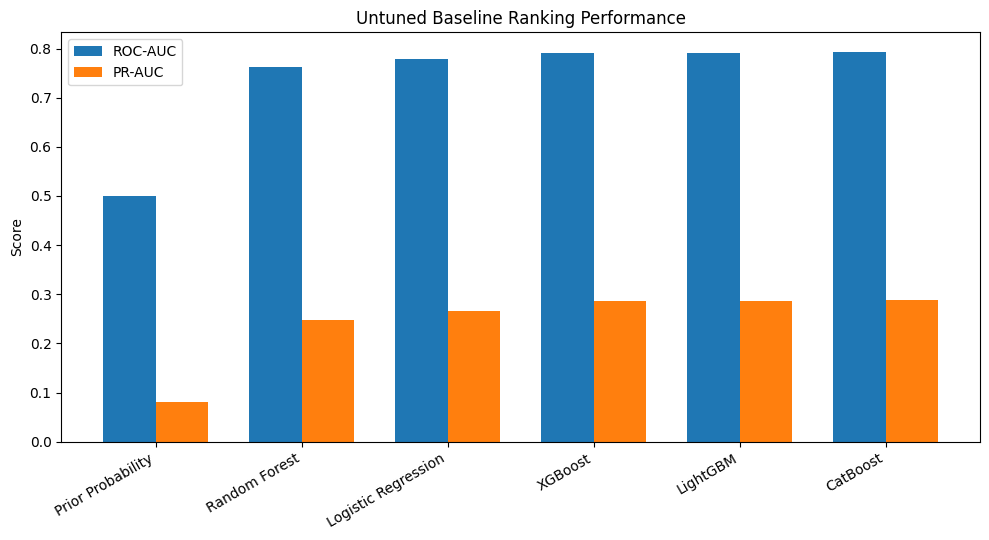

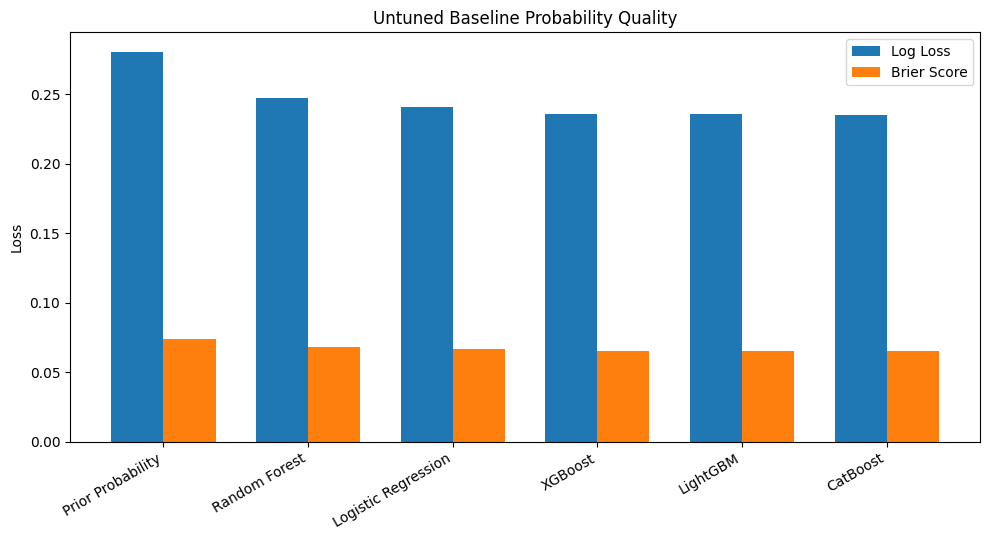

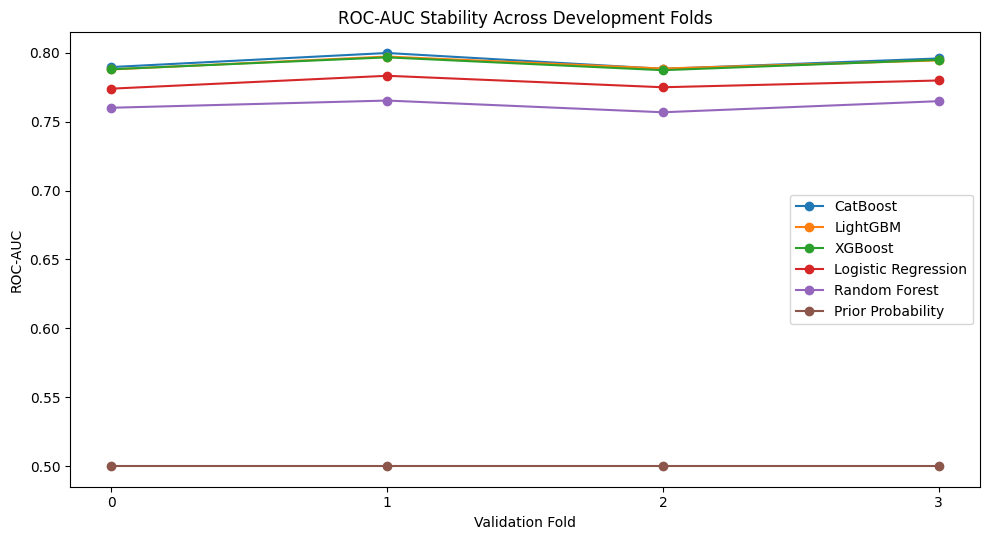

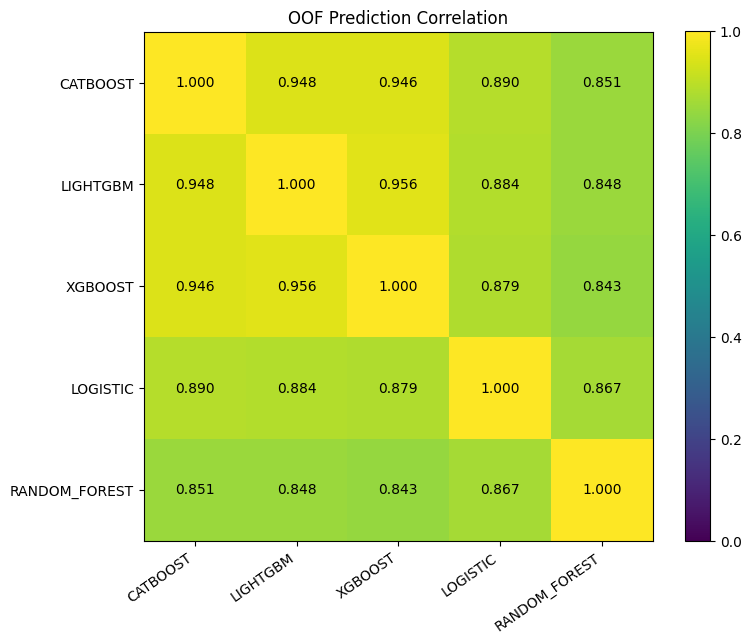

STEP 2 COMPLETE — ROBUST UNTUNED BASELINE BENCHMARKING VERIFIED
Status: STEP_2_COMPLETE
Development rows: 246,009
Compact predictors: 1369
Lockbox rows accessed: 0
Models completed: 6
Nonlinear models completed: 4
Best ROC-AUC model: CatBoost
Best ROC-AUC: 0.793372
Best PR-AUC model: CatBoost
Validation review items: 0
Validation failures: 0
Step 2 checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step2_summary.json


In [17]:
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


class Step2ResultAggregator:
    def __init__(self, runner, config, directories, paths, fold_registry, compact_features, result_schema):
        self.runner = runner
        self.config = config
        self.directories = directories
        self.paths = paths
        self.fold_registry = fold_registry.copy()
        self.compact_features = compact_features
        self.result_schema = result_schema
        self.model_order = runner.FULL_TRAINING_ORDER
        self.fold_metrics_path = Path(runner.fold_metrics_path)
        self.validation_path = Path(directories["metrics"]) / "step2_validation_report.csv"
        self.results_path = Path(directories["metrics"]) / "step2_baseline_oof_metrics.csv"
        self.delta_path = Path(directories["metrics"]) / "step2_pairwise_deltas.csv"
        self.correlation_path = Path(directories["metrics"]) / "step2_prediction_correlation.csv"
        self.overlap_path = Path(directories["metrics"]) / "step2_top10_overlap.csv"
        self.summary_path = Path(directories["checkpoints"]) / "step2_summary.json"

        assert self.fold_metrics_path.exists(), f"Missing fold metrics: {self.fold_metrics_path}"
        assert Path(paths["lockbox_control"]).exists(), f"Missing lockbox control: {paths['lockbox_control']}"

        self.fold_results = pd.read_csv(self.fold_metrics_path)

        with open(paths["lockbox_control"], "r", encoding="utf-8") as file:
            self.lockbox_control = json.load(file)

        self.development_registry = self.fold_registry.loc[
            self.fold_registry["dataset_role"].eq("DEVELOPMENT"),
            ["row_position", ID_COLUMN, TARGET_COLUMN, "outer_fold"]
        ].sort_values("row_position").reset_index(drop=True)

        self.validation_records = []
        self.overall_records = []
        self.oof_tables = {}

    @staticmethod
    def _hash(data):
        payload = json.dumps(data, sort_keys=True, default=str).encode("utf-8")
        return hashlib.blake2b(payload, digest_size=16).hexdigest()

    @staticmethod
    def _numeric(series):
        return pd.to_numeric(series, errors="coerce")

    def _prediction_path(self, model_key, validation_fold):
        model_slug = self.config["models"][model_key]["slug"]
        return Path(self.runner.full_root) / model_slug / f"full_fold_{validation_fold}_predictions.parquet"

    def _record_validation(self, check, passed, observed, expected=True, review=False):
        status = "PASS" if passed else ("REVIEW" if review else "FAIL")
        self.validation_records.append({"check": check, "status": status, "observed": observed, "expected": expected})

    def _load_complete_oof(self, model_key):
        model_config = self.config["models"][model_key]
        model_fold_results = self.fold_results.loc[self.fold_results["model_key"].eq(model_key)].copy()
        successful_mask = model_fold_results["status"].fillna("").astype(str).str.startswith("PASS")
        successful_fold_count = int(successful_mask.sum())
        required_fold_count = len(self.config["development_folds"])

        completed = successful_fold_count == required_fold_count
        self._record_validation(f"{model_key}_FOUR_FOLDS_COMPLETE", completed, successful_fold_count, required_fold_count, review=not model_config["required"])

        if not completed:
            return None, model_fold_results

        prediction_tables = []

        for validation_fold in self.config["development_folds"]:
            prediction_path = self._prediction_path(model_key, validation_fold)

            if not prediction_path.exists():
                self._record_validation(f"{model_key}_FOLD_{validation_fold}_FILE_EXISTS", False, str(prediction_path), "Existing file")
                return None, model_fold_results

            fold_prediction = pd.read_parquet(prediction_path)
            expected_fold_registry = self.development_registry.loc[self.development_registry["outer_fold"].eq(validation_fold)].sort_values("row_position").reset_index(drop=True)
            fold_prediction = fold_prediction.sort_values("row_position").reset_index(drop=True)

            fold_checks = {
                "ROW_COUNT": len(fold_prediction) == len(expected_fold_registry),
                "ROW_POSITION": np.array_equal(fold_prediction["row_position"].to_numpy(), expected_fold_registry["row_position"].to_numpy()),
                "IDENTIFIER": np.array_equal(fold_prediction[ID_COLUMN].to_numpy(), expected_fold_registry[ID_COLUMN].to_numpy()),
                "TARGET": np.array_equal(fold_prediction[TARGET_COLUMN].to_numpy(dtype=np.int8), expected_fold_registry[TARGET_COLUMN].to_numpy(dtype=np.int8)),
                "FOLD_VALUE": fold_prediction["outer_fold"].eq(validation_fold).all()
            }

            for check_name, passed in fold_checks.items():
                self._record_validation(f"{model_key}_FOLD_{validation_fold}_{check_name}", passed, passed, True)

            if not all(fold_checks.values()):
                return None, model_fold_results

            prediction_tables.append(fold_prediction)

        oof_table = pd.concat(prediction_tables, ignore_index=True).sort_values("row_position").reset_index(drop=True)
        probability = pd.to_numeric(oof_table["probability"], errors="coerce")

        complete_checks = {
            "ROW_COUNT": len(oof_table) == len(self.development_registry),
            "ROW_POSITION_ALIGNMENT": np.array_equal(oof_table["row_position"].to_numpy(), self.development_registry["row_position"].to_numpy()),
            "IDENTIFIER_ALIGNMENT": np.array_equal(oof_table[ID_COLUMN].to_numpy(), self.development_registry[ID_COLUMN].to_numpy()),
            "TARGET_ALIGNMENT": np.array_equal(oof_table[TARGET_COLUMN].to_numpy(dtype=np.int8), self.development_registry[TARGET_COLUMN].to_numpy(dtype=np.int8)),
            "FOLD_COVERAGE": set(oof_table["outer_fold"].unique()) == set(self.config["development_folds"]),
            "UNIQUE_ROW_POSITION": oof_table["row_position"].is_unique,
            "UNIQUE_IDENTIFIER": oof_table[ID_COLUMN].is_unique,
            "FINITE_PROBABILITY": np.isfinite(probability).all(),
            "PROBABILITY_RANGE": probability.between(0, 1, inclusive="both").all(),
            "ZERO_LOCKBOX_ROWS": int(oof_table["outer_fold"].eq(self.config["lockbox_fold"]).sum()) == 0
        }

        for check_name, passed in complete_checks.items():
            self._record_validation(f"{model_key}_OOF_{check_name}", passed, passed, True)

        if not all(complete_checks.values()):
            return None, model_fold_results

        output_path = Path(self.directories["oof"]) / f"step2_{model_config['slug']}_oof.parquet"
        oof_table.to_parquet(output_path, index=False, compression="zstd")
        reloaded_oof = pd.read_parquet(output_path)

        reload_valid = len(reloaded_oof) == len(oof_table) and np.array_equal(reloaded_oof["row_position"].to_numpy(), oof_table["row_position"].to_numpy())
        self._record_validation(f"{model_key}_OOF_RELOAD", reload_valid, reload_valid, True)

        if not reload_valid:
            return None, model_fold_results

        return oof_table, model_fold_results

    def _summarise_model(self, model_key, oof_table, model_fold_results):
        model_config = self.config["models"][model_key]
        metrics = evaluate_predictions(oof_table[TARGET_COLUMN], oof_table["probability"])

        fold_auc = self._numeric(model_fold_results["roc_auc"])
        fold_pr_auc = self._numeric(model_fold_results["pr_auc"])
        fold_log_loss = self._numeric(model_fold_results["log_loss"])
        fit_seconds = self._numeric(model_fold_results["fit_seconds"])
        prediction_seconds = self._numeric(model_fold_results["prediction_seconds"])
        best_iterations = self._numeric(model_fold_results["best_iteration"])
        encoded_counts = self._numeric(model_fold_results["encoded_feature_count"])

        model_status = "PASS_WITH_CONVERGENCE_REVIEW" if model_fold_results["status"].fillna("").astype(str).str.contains("CONVERGENCE_REVIEW").any() else "PASS"
        output_path = Path(self.directories["oof"]) / f"step2_{model_config['slug']}_oof.parquet"

        return {
            "model_key": model_key,
            "model_id": model_config["model_id"],
            "model_family": model_config["family"],
            "feature_set": "NONE" if model_key == "PRIOR" else "COMPACT",
            "feature_count": 0 if model_key == "PRIOR" else len(self.compact_features),
            "encoded_feature_count_mean": float(encoded_counts.mean()) if encoded_counts.notna().any() else 0.0,
            **metrics,
            "fold_roc_auc_mean": float(fold_auc.mean()),
            "fold_roc_auc_std": float(fold_auc.std(ddof=1)),
            "fold_roc_auc_min": float(fold_auc.min()),
            "fold_roc_auc_max": float(fold_auc.max()),
            "fold_roc_auc_gap": float(fold_auc.max() - fold_auc.min()),
            "fold_pr_auc_mean": float(fold_pr_auc.mean()),
            "fold_pr_auc_std": float(fold_pr_auc.std(ddof=1)),
            "fold_log_loss_mean": float(fold_log_loss.mean()),
            "total_fit_seconds": float(fit_seconds.sum()),
            "mean_fit_seconds": float(fit_seconds.mean()),
            "total_prediction_seconds": float(prediction_seconds.sum()),
            "best_iteration_mean": float(best_iterations.mean()),
            "primary_profile_folds": int(model_fold_results["profile_used"].fillna("").eq("primary").sum()),
            "safe_profile_folds": int(model_fold_results["profile_used"].fillna("").eq("safe").sum()),
            "checkpoint_reused_folds": int(model_fold_results["checkpoint_reused"].fillna(False).astype(bool).sum()),
            "convergence_review_folds": int(model_fold_results["status"].fillna("").astype(str).str.contains("CONVERGENCE_REVIEW").sum()),
            "oof_path": str(output_path),
            "status": model_status
        }

    def aggregate(self):
        for model_key in self.model_order:
            oof_table, model_fold_results = self._load_complete_oof(model_key)

            if oof_table is None:
                continue

            self.oof_tables[model_key] = oof_table
            self.overall_records.append(self._summarise_model(model_key, oof_table, model_fold_results))

        results = pd.DataFrame(self.overall_records)

        if results.empty:
            raise RuntimeError("No complete model was available for Step 2 aggregation.")

        results = results.sort_values("roc_auc", ascending=False).reset_index(drop=True)
        results.to_csv(self.results_path, index=False)

        return results

    def build_validation_report(self, results):
        completed_models = results["model_key"].tolist()
        nonlinear_models = [model_key for model_key in ["RANDOM_FOREST", "LIGHTGBM", "XGBOOST", "CATBOOST"] if model_key in completed_models]

        prior_auc = np.nan

        if "PRIOR" in completed_models:
            prior_auc = float(results.loc[results["model_key"].eq("PRIOR"), "roc_auc"].iloc[0])

        hard_checks = [
            ("PRIOR_COMPLETED", "PRIOR" in completed_models, "PRIOR" in completed_models, True),
            ("LOGISTIC_COMPLETED", "LOGISTIC" in completed_models, "LOGISTIC" in completed_models, True),
            ("AT_LEAST_TWO_NONLINEAR_MODELS", len(nonlinear_models) >= 2, len(nonlinear_models), 2),
            ("LOCKBOX_REMAINS_SEALED", self.lockbox_control.get("status") == "SEALED" and int(self.lockbox_control.get("evaluation_count", -1)) == 0, self.lockbox_control.get("status"), "SEALED"),
            ("PRIOR_AUC_SANITY", np.isfinite(prior_auc) and abs(prior_auc - 0.5) <= 0.02, prior_auc, 0.5),
            ("COMPLETED_MODEL_IDS_UNIQUE", results["model_id"].is_unique, results["model_id"].nunique(), len(results))
        ]

        for check, passed, observed, expected in hard_checks:
            self._record_validation(check, passed, observed, expected)

        validation_report = pd.DataFrame(self.validation_records)
        validation_report.to_csv(self.validation_path, index=False)

        return validation_report, nonlinear_models

    def build_comparisons(self, results):
        if "LOGISTIC" in results["model_key"].tolist():
            logistic_result = results.loc[results["model_key"].eq("LOGISTIC")].iloc[0]

            deltas = results.assign(
                roc_auc_delta_vs_logistic=results["roc_auc"] - logistic_result["roc_auc"],
                pr_auc_delta_vs_logistic=results["pr_auc"] - logistic_result["pr_auc"],
                log_loss_improvement_vs_logistic=logistic_result["log_loss"] - results["log_loss"],
                brier_improvement_vs_logistic=logistic_result["brier_score"] - results["brier_score"]
            )[["model_key", "model_family", "roc_auc_delta_vs_logistic", "pr_auc_delta_vs_logistic", "log_loss_improvement_vs_logistic", "brier_improvement_vs_logistic"]]
        else:
            deltas = pd.DataFrame(columns=["model_key", "model_family", "roc_auc_delta_vs_logistic", "pr_auc_delta_vs_logistic", "log_loss_improvement_vs_logistic", "brier_improvement_vs_logistic"])

        deltas.to_csv(self.delta_path, index=False)

        actual_models = [model_key for model_key in results["model_key"].tolist() if model_key != "PRIOR"]

        if len(actual_models) >= 2:
            probability_frame = pd.DataFrame({model_key: self.oof_tables[model_key]["probability"].to_numpy() for model_key in actual_models})
            prediction_correlation = probability_frame.corr()

            top_count = max(1, int(np.ceil(len(probability_frame) * 0.10)))
            top_risk_sets = {model_key: set(np.argpartition(-probability_frame[model_key].to_numpy(), top_count - 1)[:top_count]) for model_key in actual_models}
            top10_overlap = pd.DataFrame(index=actual_models, columns=actual_models, dtype=float)

            for first_model in actual_models:
                for second_model in actual_models:
                    intersection = len(top_risk_sets[first_model].intersection(top_risk_sets[second_model]))
                    top10_overlap.loc[first_model, second_model] = intersection / top_count
        else:
            prediction_correlation = pd.DataFrame()
            top10_overlap = pd.DataFrame()

        prediction_correlation.to_csv(self.correlation_path)
        top10_overlap.to_csv(self.overlap_path)

        return deltas, prediction_correlation, top10_overlap

    def update_master_registry(self, results):
        master_rows = []

        for result in results.itertuples(index=False):
            model_config = self.config["models"][result.model_key]

            master_rows.append({
                "model_id": result.model_id,
                "model_family": result.model_family,
                "stage": "DEVELOPMENT_CONFIRMATION",
                "protocol": "DEVELOPMENT_CV",
                "feature_set": result.feature_set,
                "fold": "OOF_0_3",
                "training_rows": len(self.development_registry),
                "validation_rows": len(self.development_registry),
                "feature_count": int(result.feature_count),
                "roc_auc": result.roc_auc,
                "pr_auc": result.pr_auc,
                "log_loss": result.log_loss,
                "brier_score": result.brier_score,
                "ks_statistic": result.ks_statistic,
                "calibration_slope": result.calibration_slope,
                "calibration_intercept": result.calibration_intercept,
                "fit_seconds": result.total_fit_seconds,
                "prediction_seconds": result.total_prediction_seconds,
                "best_iteration": result.best_iteration_mean,
                "parameter_id": self._hash(model_config),
                "prediction_path": result.oof_path,
                "model_path": "",
                "status": result.status,
                "notes": "UNTUNED_COMPACT_FOUR_FOLD_DEVELOPMENT_OOF"
            })

        step2_rows = pd.DataFrame(master_rows, columns=self.result_schema)

        if Path(self.paths["model_comparison"]).exists():
            master_registry = pd.read_csv(self.paths["model_comparison"]).reindex(columns=self.result_schema)
        else:
            master_registry = pd.DataFrame(columns=self.result_schema)

        master_registry = master_registry.loc[~master_registry["model_id"].isin(step2_rows["model_id"])].copy()
        master_registry = pd.concat([master_registry, step2_rows], ignore_index=True)
        master_registry.to_csv(self.paths["model_comparison"], index=False)

    def create_figures(self, results, prediction_correlation):
        plot_results = results.sort_values("roc_auc").reset_index(drop=True)
        positions = np.arange(len(plot_results))
        width = 0.36

        ranking_path = Path(self.directories["figures"]) / "step2_baseline_ranking_performance.png"
        quality_path = Path(self.directories["figures"]) / "step2_baseline_probability_quality.png"
        stability_path = Path(self.directories["figures"]) / "step2_baseline_fold_stability.png"
        correlation_path = Path(self.directories["figures"]) / "step2_prediction_correlation.png"

        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.bar(positions - width / 2, plot_results["roc_auc"], width, label="ROC-AUC")
        ax.bar(positions + width / 2, plot_results["pr_auc"], width, label="PR-AUC")
        ax.set_xticks(positions)
        ax.set_xticklabels(plot_results["model_family"], rotation=30, ha="right")
        ax.set_title("Untuned Baseline Ranking Performance")
        ax.set_ylabel("Score")
        ax.legend()
        fig.tight_layout()
        fig.savefig(ranking_path, dpi=160, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.bar(positions - width / 2, plot_results["log_loss"], width, label="Log Loss")
        ax.bar(positions + width / 2, plot_results["brier_score"], width, label="Brier Score")
        ax.set_xticks(positions)
        ax.set_xticklabels(plot_results["model_family"], rotation=30, ha="right")
        ax.set_title("Untuned Baseline Probability Quality")
        ax.set_ylabel("Loss")
        ax.legend()
        fig.tight_layout()
        fig.savefig(quality_path, dpi=160, bbox_inches="tight")
        plt.show()

        successful_folds = self.fold_results.loc[self.fold_results["status"].fillna("").astype(str).str.startswith("PASS")].copy()

        fig, ax = plt.subplots(figsize=(10, 5.5))

        for model_key in results["model_key"].tolist():
            model_rows = successful_folds.loc[successful_folds["model_key"].eq(model_key)].sort_values("validation_fold")

            if not model_rows.empty:
                ax.plot(model_rows["validation_fold"], self._numeric(model_rows["roc_auc"]), marker="o", label=self.config["models"][model_key]["family"])

        ax.set_xticks(self.config["development_folds"])
        ax.set_title("ROC-AUC Stability Across Development Folds")
        ax.set_xlabel("Validation Fold")
        ax.set_ylabel("ROC-AUC")
        ax.legend()
        fig.tight_layout()
        fig.savefig(stability_path, dpi=160, bbox_inches="tight")
        plt.show()

        if not prediction_correlation.empty:
            fig, ax = plt.subplots(figsize=(8, 6.5))
            image = ax.imshow(prediction_correlation.to_numpy(), vmin=0, vmax=1)
            ax.set_xticks(np.arange(len(prediction_correlation.columns)))
            ax.set_yticks(np.arange(len(prediction_correlation.index)))
            ax.set_xticklabels(prediction_correlation.columns, rotation=35, ha="right")
            ax.set_yticklabels(prediction_correlation.index)

            for row_index in range(len(prediction_correlation.index)):
                for column_index in range(len(prediction_correlation.columns)):
                    ax.text(column_index, row_index, f"{prediction_correlation.iloc[row_index, column_index]:.3f}", ha="center", va="center")

            ax.set_title("OOF Prediction Correlation")
            fig.colorbar(image, ax=ax)
            fig.tight_layout()
            fig.savefig(correlation_path, dpi=160, bbox_inches="tight")
            plt.show()

    def save_summary(self, results, validation_report, nonlinear_models):
        hard_failures = validation_report["status"].eq("FAIL")
        review_items = validation_report["status"].eq("REVIEW")
        status = "STEP_2_COMPLETE_WITH_OPTIONAL_MODEL_REVIEW" if review_items.any() else "STEP_2_COMPLETE"

        summary = {
            "status": status,
            "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
            "protocol": "DEVELOPMENT_CV",
            "feature_set": "COMPACT",
            "compact_features": len(self.compact_features),
            "development_rows": len(self.development_registry),
            "lockbox_rows_accessed": 0,
            "models_requested": len(self.model_order),
            "models_completed": len(results),
            "nonlinear_models_completed": len(nonlinear_models),
            "best_roc_auc_model": results.sort_values("roc_auc", ascending=False).iloc[0]["model_family"],
            "best_roc_auc": float(results["roc_auc"].max()),
            "best_pr_auc_model": results.sort_values("pr_auc", ascending=False).iloc[0]["model_family"],
            "best_pr_auc": float(results["pr_auc"].max()),
            "best_log_loss_model": results.sort_values("log_loss").iloc[0]["model_family"],
            "best_brier_model": results.sort_values("brier_score").iloc[0]["model_family"],
            "validation_passes": int(validation_report["status"].eq("PASS").sum()),
            "validation_reviews": int(review_items.sum()),
            "validation_failures": int(hard_failures.sum()),
            "results_path": str(self.results_path),
            "validation_path": str(self.validation_path),
            "next_step": "STEP_3_LINEAR_CLASSIFICATION_RESEARCH"
        }

        with open(self.summary_path, "w", encoding="utf-8") as file:
            json.dump(summary, file, indent=2)

        return summary, hard_failures

    def run(self):
        results = self.aggregate()
        validation_report, nonlinear_models = self.build_validation_report(results)
        deltas, prediction_correlation, top10_overlap = self.build_comparisons(results)
        self.update_master_registry(results)

        display_columns = ["model_family", "feature_count", "roc_auc", "pr_auc", "log_loss", "brier_score", "ks_statistic", "capture_top_10", "lift_top_10", "fold_roc_auc_std", "total_fit_seconds", "primary_profile_folds", "safe_profile_folds", "status"]

        display(results.reindex(columns=display_columns))

        if not deltas.empty:
            display(deltas)

        if not prediction_correlation.empty:
            display(prediction_correlation)

        if not top10_overlap.empty:
            display(top10_overlap)

        display(validation_report)

        self.create_figures(results, prediction_correlation)
        summary, hard_failures = self.save_summary(results, validation_report, nonlinear_models)

        show_report("STEP 2 COMPLETE — ROBUST UNTUNED BASELINE BENCHMARKING VERIFIED", [
            ("Status", summary["status"]),
            ("Development rows", f"{summary['development_rows']:,}"),
            ("Compact predictors", summary["compact_features"]),
            ("Lockbox rows accessed", summary["lockbox_rows_accessed"]),
            ("Models completed", summary["models_completed"]),
            ("Nonlinear models completed", summary["nonlinear_models_completed"]),
            ("Best ROC-AUC model", summary["best_roc_auc_model"]),
            ("Best ROC-AUC", f"{summary['best_roc_auc']:.6f}"),
            ("Best PR-AUC model", summary["best_pr_auc_model"]),
            ("Validation review items", summary["validation_reviews"]),
            ("Validation failures", summary["validation_failures"]),
            ("Step 2 checkpoint", self.summary_path)
        ])

        if hard_failures.any():
            failed_checks = validation_report.loc[hard_failures, "check"].tolist()
            raise RuntimeError(f"Step 2 hard validation failed: {failed_checks}")

        return results, validation_report, prediction_correlation, top10_overlap


required_objects = ["STEP2_RUNNER", "STEP2_CONFIG", "FOLD_REGISTRY", "COMPACT_FEATURES", "RESULT_SCHEMA"]

missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Run Steps 2.1–2.4 first. Missing objects: {missing_objects}"

STEP2_AGGREGATOR = Step2ResultAggregator(
    runner=STEP2_RUNNER,
    config=STEP2_CONFIG,
    directories=DIRS,
    paths=PATHS,
    fold_registry=FOLD_REGISTRY,
    compact_features=COMPACT_FEATURES,
    result_schema=RESULT_SCHEMA
)

STEP2_BASELINE_RESULTS, STEP2_VALIDATION_REPORT, STEP2_PREDICTION_CORRELATION, STEP2_TOP10_OVERLAP = STEP2_AGGREGATOR.run()

# Step 3 — Linear Classification Research

## Research Aim

This stage investigates whether alternative regularisation strategies improve the established Logistic Regression baseline.

The study examines:

- Discrimination and probability quality
- L2, L1, and Elastic Net regularisation
- Model convergence
- Coefficient sparsity
- Stability across development folds
- Prediction diversity relative to the boosting models

## Experimental Boundary

- Feature set: Compact
- Screening split: Development fold 0
- Confirmation splits: Development folds 1–3
- Reference model: Step 2 Logistic Regression
- Lockbox fold 4: Sealed
- Test data: Not accessed

## Interruption Recovery

Each completed candidate–fold fit is saved immediately. Under normal conditions, every execution cell is run once. After an interruption, rerunning the same cell skips completed fits and continues with the remaining work.

## Step 3.1 — Define the Regularisation Study

Six fixed Logistic Regression configurations are evaluated:

- L2 regularisation with three values of `C`
- L1 regularisation with two values of `C`
- Elastic Net regularisation

`L2, C = 1.0` acts as a reproducibility control against the Step 2 Logistic Regression result.

The configurations are fixed before observing the screening results.

In [3]:
import gc
import json
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import display

required_objects = ["DIRS", "STEP2_DATA_PATH", "STEP2_DATA_MANIFEST", "STEP2_FOLD_RESULTS", "STEP2_BASELINE_RESULTS", "STEP2_OOF_PATHS", "DEVELOPMENT_REGISTRY", "LOCKBOX_CONTROL", "COMPACT_FEATURES", "ID_COLUMN", "TARGET_COLUMN"]
missing_objects = [name for name in required_objects if name not in globals()]

assert not missing_objects, f"Run Steps 0–2 or the temporary restore cell first: {missing_objects}"
assert LOCKBOX_CONTROL["status"] == "SEALED" and int(LOCKBOX_CONTROL["evaluation_count"]) == 0

linear_study_root = DIRS["checkpoints"] / "linear_regularisation_study_v1"
linear_cache_dir = linear_study_root / "fold_cache"
linear_runs_dir = linear_study_root / "candidate_runs"
linear_metrics_dir = DIRS["metrics"] / "linear_regularisation_study_v1"
linear_oof_dir = DIRS["oof"] / "linear_regularisation_study_v1"
linear_figures_dir = DIRS["figures"] / "linear_regularisation_study_v1"
linear_explanations_dir = DIRS["explanations"] / "linear_regularisation_study_v1"

for path in [linear_study_root, linear_cache_dir, linear_runs_dir, linear_metrics_dir, linear_oof_dir, linear_figures_dir, linear_explanations_dir]:
    path.mkdir(parents=True, exist_ok=True)

linear_candidates = {
    "L2_C0_1": {"family": "L2", "penalty": "l2", "C": 0.1, "l1_ratio": None},
    "L2_C1": {"family": "L2", "penalty": "l2", "C": 1.0, "l1_ratio": None},
    "L2_C10": {"family": "L2", "penalty": "l2", "C": 10.0, "l1_ratio": None},
    "L1_C0_1": {"family": "L1", "penalty": "l1", "C": 0.1, "l1_ratio": None},
    "L1_C1": {"family": "L1", "penalty": "l1", "C": 1.0, "l1_ratio": None},
    "ELASTIC_NET_C1_R05": {"family": "ELASTIC_NET", "penalty": "elasticnet", "C": 1.0, "l1_ratio": 0.5}
}

development_folds = [0, 1, 2, 3]
maximum_iterations = 1000
convergence_tolerance = 1e-4
random_state = 42

experiment_contract = {
    "candidates": linear_candidates,
    "development_folds": development_folds,
    "screening_fold": 0,
    "confirmation_folds": [1, 2, 3],
    "maximum_iterations": maximum_iterations,
    "convergence_tolerance": convergence_tolerance,
    "feature_set": "COMPACT"
}

with open(linear_study_root / "experiment_contract.json", "w", encoding="utf-8") as file:
    json.dump(experiment_contract, file, indent=2)

display(STEP2_BASELINE_RESULTS[["model_key", "model_family", "roc_auc", "pr_auc", "log_loss", "brier_score"]].sort_values("roc_auc", ascending=False).reset_index(drop=True))

print("=" * 90)
print("LINEAR REGULARISATION STUDY DEFINED")
print(f"Candidate configurations: {len(linear_candidates)}")
print(f"Maximum iterations: {maximum_iterations}")
print(f"Convergence tolerance: {convergence_tolerance}")
print("Step 2 Logistic reference reused: YES")
print(f"Lockbox status: {LOCKBOX_CONTROL['status']}")
print("Training performed: NO")
print("=" * 90)

,model_key,model_family,roc_auc,pr_auc,log_loss,brier_score
0,CATBOOST,CatBoost,0.793372,0.288452,0.235049,0.065469
1,LIGHTGBM,LightGBM,0.791953,0.287065,0.235479,0.065569
2,XGBOOST,XGBoost,0.791686,0.287068,0.235500,0.065564
3,LOGISTIC,Logistic Regression,0.777949,0.265180,0.240784,0.066672
4,RANDOM_FOREST,Random Forest,0.761699,0.247733,0.247430,0.068090
5,PRIOR,Prior Probability,0.499998,0.080729,0.280546,0.074212


LINEAR REGULARISATION STUDY DEFINED
Candidate configurations: 6
Maximum iterations: 1000
Convergence tolerance: 0.0001
Step 2 Logistic reference reused: YES
Lockbox status: SEALED
Training performed: NO


## Step 3.2 — Prepare Fold-Safe Data and Fit Logistic Models

Three reusable functions support the experiment:

- `evaluate_probabilities()` calculates the evaluation metrics.
- `prepare_linear_fold()` fits preprocessing only on the training portion of a fold.
- `fit_linear_candidate()` trains and saves one candidate–fold result.

A fold is preprocessed once and the resulting matrices are reused across its candidate models.

In [4]:
def evaluate_probabilities(y_true, probability):
    y_true = np.asarray(y_true, dtype=np.int8)
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)
    fpr, tpr, _ = roc_curve(y_true, probability)
    top_count = max(1, int(np.ceil(len(y_true) * 0.10)))
    top_positions = np.argpartition(-probability, top_count - 1)[:top_count]
    capture = float(y_true[top_positions].sum() / max(y_true.sum(), 1))

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "ks_statistic": float(np.max(tpr - fpr)),
        "capture_top_10": capture,
        "lift_top_10": capture / 0.10
    }


def prepare_linear_fold(fold):
    fold_dir = linear_cache_dir / f"fold_{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    manifest_path = fold_dir / "manifest.json"
    X_train_path = fold_dir / "X_train.npz"
    X_valid_path = fold_dir / "X_valid.npz"
    y_train_path = fold_dir / "y_train.npy"
    y_valid_path = fold_dir / "y_valid.npy"
    metadata_path = fold_dir / "validation_metadata.parquet"
    feature_names_path = fold_dir / "encoded_features.csv"
    preprocessor_path = fold_dir / "preprocessor.joblib"

    required_paths = [X_train_path, X_valid_path, y_train_path, y_valid_path, metadata_path, feature_names_path, preprocessor_path]

    if manifest_path.exists() and all(path.exists() for path in required_paths):
        with open(manifest_path, "r", encoding="utf-8") as file:
            manifest = json.load(file)

        if manifest.get("feature_hash") == STEP2_DATA_MANIFEST["feature_hash"]:
            X_train = sparse.load_npz(X_train_path).tocsr()
            X_valid = sparse.load_npz(X_valid_path).tocsr()
            y_train = np.load(y_train_path)
            y_valid = np.load(y_valid_path)
            metadata = pd.read_parquet(metadata_path)
            feature_names = pd.read_csv(feature_names_path)["feature"].astype(str).to_numpy()

            return X_train, X_valid, y_train, y_valid, metadata, feature_names, manifest

    start = time.perf_counter()
    selected_columns = list(dict.fromkeys(["row_position", ID_COLUMN, TARGET_COLUMN, "outer_fold"] + COMPACT_FEATURES))
    data = pd.read_parquet(STEP2_DATA_PATH, columns=selected_columns)

    train = data.loc[data["outer_fold"].ne(fold)].reset_index(drop=True)
    valid = data.loc[data["outer_fold"].eq(fold)].sort_values("row_position").reset_index(drop=True)

    numeric_features = [feature for feature in STEP2_DATA_MANIFEST["numeric_features"] if feature in COMPACT_FEATURES]
    categorical_features = [feature for feature in STEP2_DATA_MANIFEST["categorical_features"] if feature in COMPACT_FEATURES]
    untyped_features = [feature for feature in COMPACT_FEATURES if feature not in set(numeric_features + categorical_features)]
    numeric_features += untyped_features

    for feature in numeric_features:
        train[feature] = pd.to_numeric(train[feature], errors="coerce").astype(np.float32)
        valid[feature] = pd.to_numeric(valid[feature], errors="coerce").astype(np.float32)

    for feature in categorical_features:
        train[feature] = train[feature].astype("string").fillna("__MISSING__").astype(str)
        valid[feature] = valid[feature].astype("string").fillna("__MISSING__").astype(str)

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32, sparse_output=True)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32, sparse=True)

    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median", keep_empty_features=True)), ("scaler", StandardScaler(with_mean=False))])
    preprocessor = ColumnTransformer([("numeric", numeric_pipeline, numeric_features), ("categorical", encoder, categorical_features)], remainder="drop", sparse_threshold=1.0, n_jobs=-1)

    X_train = sparse.csr_matrix(preprocessor.fit_transform(train[COMPACT_FEATURES]), dtype=np.float32)
    X_valid = sparse.csr_matrix(preprocessor.transform(valid[COMPACT_FEATURES]), dtype=np.float32)
    X_train.sort_indices()
    X_valid.sort_indices()

    y_train = train[TARGET_COLUMN].to_numpy(dtype=np.int8)
    y_valid = valid[TARGET_COLUMN].to_numpy(dtype=np.int8)
    metadata = valid[["row_position", ID_COLUMN, TARGET_COLUMN, "outer_fold"]].copy()
    feature_names = preprocessor.get_feature_names_out().astype(str)

    sparse.save_npz(X_train_path, X_train, compressed=True)
    sparse.save_npz(X_valid_path, X_valid, compressed=True)
    np.save(y_train_path, y_train)
    np.save(y_valid_path, y_valid)
    metadata.to_parquet(metadata_path, index=False, compression="zstd")
    pd.DataFrame({"feature": feature_names}).to_csv(feature_names_path, index=False)
    joblib.dump(preprocessor, preprocessor_path, compress=3)

    total_cells = X_train.shape[0] * X_train.shape[1] + X_valid.shape[0] * X_valid.shape[1]
    matrix_bytes = X_train.data.nbytes + X_train.indices.nbytes + X_train.indptr.nbytes + X_valid.data.nbytes + X_valid.indices.nbytes + X_valid.indptr.nbytes

    manifest = {
        "fold": int(fold),
        "feature_hash": STEP2_DATA_MANIFEST["feature_hash"],
        "training_rows": int(len(y_train)),
        "validation_rows": int(len(y_valid)),
        "encoded_features": int(X_train.shape[1]),
        "matrix_density": float((X_train.nnz + X_valid.nnz) / total_cells),
        "matrix_size_mb": float(matrix_bytes / 2**20),
        "preparation_seconds": float(time.perf_counter() - start)
    }

    with open(manifest_path, "w", encoding="utf-8") as file:
        json.dump(manifest, file, indent=2)

    del data, train, valid
    gc.collect()

    return X_train, X_valid, y_train, y_valid, metadata, feature_names, manifest


def fit_linear_candidate(candidate_name, fold, prepared_fold=None):
    run_dir = linear_runs_dir / candidate_name / f"fold_{fold}"
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_path = run_dir / "metrics.json"
    prediction_path = run_dir / "predictions.parquet"
    coefficient_path = run_dir / "coefficients.parquet"
    model_path = run_dir / "model.joblib"
    completed_paths = [metrics_path, prediction_path, coefficient_path, model_path]

    if all(path.exists() for path in completed_paths):
        with open(metrics_path, "r", encoding="utf-8") as file:
            return json.load(file)

    if prepared_fold is None:
        prepared_fold = prepare_linear_fold(fold)

    X_train, X_valid, y_train, y_valid, metadata, feature_names, _ = prepared_fold
    candidate = linear_candidates[candidate_name]

    model_parameters = {"C": candidate["C"], "penalty": candidate["penalty"], "solver": "saga", "max_iter": maximum_iterations, "tol": convergence_tolerance, "random_state": random_state}

    if candidate["penalty"] == "elasticnet":
        model_parameters["l1_ratio"] = candidate["l1_ratio"]

    model = LogisticRegression(**model_parameters)
    start = time.perf_counter()

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always", ConvergenceWarning)
        model.fit(X_train, y_train)

    fit_seconds = time.perf_counter() - start
    convergence_warning = any(issubclass(item.category, ConvergenceWarning) for item in captured_warnings)
    probability = model.predict_proba(X_valid)[:, 1].astype(np.float32)
    coefficients = np.asarray(model.coef_[0], dtype=np.float64)
    nonzero_coefficients = int(np.count_nonzero(np.abs(coefficients) > 1e-8))

    prediction_table = metadata.copy()
    prediction_table["probability"] = probability

    coefficient_table = pd.DataFrame({"candidate": candidate_name, "family": candidate["family"], "fold": fold, "feature": feature_names, "coefficient": coefficients})

    prediction_table.to_parquet(prediction_path, index=False, compression="zstd")
    coefficient_table.to_parquet(coefficient_path, index=False, compression="zstd")
    joblib.dump(model, model_path, compress=3)

    metrics = {
        "candidate": candidate_name,
        "family": candidate["family"],
        "penalty": candidate["penalty"],
        "C": candidate["C"],
        "l1_ratio": candidate["l1_ratio"],
        "fold": int(fold),
        **evaluate_probabilities(y_valid, probability),
        "fit_seconds": float(fit_seconds),
        "iterations": int(model.n_iter_[0]),
        "converged": not convergence_warning,
        "encoded_features": int(len(coefficients)),
        "nonzero_coefficients": nonzero_coefficients,
        "zero_fraction": float(1 - nonzero_coefficients / max(len(coefficients), 1))
    }

    temporary_metrics = metrics_path.with_suffix(".tmp.json")

    with open(temporary_metrics, "w", encoding="utf-8") as file:
        json.dump(metrics, file, indent=2)

    temporary_metrics.replace(metrics_path)

    del model
    gc.collect()

    return metrics


print("Core linear research functions are ready.")

Core linear research functions are ready.


## Step 3.3 — Screen the Regularisation Configurations

All six configurations are evaluated on development fold 0 using the same prepared matrices.

The execution cell runs every incomplete configuration sequentially. Each completed fit is saved immediately.

Under normal conditions, run the cell once. After an interruption, rerun it to skip completed fits and continue from the first incomplete configuration.

In [5]:
screening_fold = prepare_linear_fold(0)
screening_manifest = screening_fold[-1]

print("=" * 90)
print("SCREENING MATRIX READY")
print(f"Training rows: {screening_manifest['training_rows']:,}")
print(f"Validation rows: {screening_manifest['validation_rows']:,}")
print(f"Encoded features: {screening_manifest['encoded_features']:,}")
print(f"Matrix size: {screening_manifest['matrix_size_mb']:.1f} MB")
print(f"Preparation time: {screening_manifest['preparation_seconds'] / 60:.2f} minutes")
print("=" * 90)

for candidate_name in linear_candidates:
    metrics_path = linear_runs_dir / candidate_name / "fold_0" / "metrics.json"

    if metrics_path.exists():
        print(f"Skipped completed fit: {candidate_name}")
        continue

    result = fit_linear_candidate(candidate_name, 0, screening_fold)
    print(f"Completed: {candidate_name} | AUC: {result['roc_auc']:.6f} | Iterations: {result['iterations']} | Time: {result['fit_seconds'] / 60:.2f} min | Converged: {result['converged']}")

del screening_fold
gc.collect()

screening_records = []

for candidate_name in linear_candidates:
    metrics_path = linear_runs_dir / candidate_name / "fold_0" / "metrics.json"

    if metrics_path.exists():
        with open(metrics_path, "r", encoding="utf-8") as file:
            screening_records.append(json.load(file))

screening_status = pd.DataFrame(screening_records).sort_values("roc_auc", ascending=False).reset_index(drop=True)
remaining_fits = len(linear_candidates) - len(screening_status)

if not screening_status.empty:
    display(screening_status[["candidate", "family", "roc_auc", "pr_auc", "log_loss", "brier_score", "iterations", "converged", "zero_fraction", "fit_seconds"]])

print("=" * 90)
print("REGULARISATION SCREENING FINISHED")
print(f"Completed fits: {len(screening_status)}/{len(linear_candidates)}")
print(f"Remaining fits: {remaining_fits}")
print("All completed results were saved.")
print("=" * 90)

SCREENING MATRIX READY
Training rows: 184,506
Validation rows: 61,503
Encoded features: 1,499
Matrix size: 1458.7 MB
Preparation time: 0.98 minutes
Completed: L2_C0_1 | AUC: 0.774515 | Iterations: 1000 | Time: 12.25 min | Converged: False
Completed: L2_C1 | AUC: 0.774515 | Iterations: 1000 | Time: 12.32 min | Converged: False
Completed: L2_C10 | AUC: 0.774516 | Iterations: 1000 | Time: 12.28 min | Converged: False
Completed: L1_C0_1 | AUC: 0.772298 | Iterations: 347 | Time: 9.33 min | Converged: True
Completed: L1_C1 | AUC: 0.772273 | Iterations: 280 | Time: 7.82 min | Converged: True
Completed: ELASTIC_NET_C1_R05 | AUC: 0.772271 | Iterations: 285 | Time: 8.57 min | Converged: True


,candidate,family,roc_auc,pr_auc,log_loss,brier_score,iterations,converged,zero_fraction,fit_seconds
0,L2_C10,L2,0.774516,0.261278,0.241987,0.066884,1000,False,0.001334,736.746580
1,L2_C0_1,L2,0.774515,0.261275,0.241987,0.066885,1000,False,0.001334,734.967573
2,L2_C1,L2,0.774515,0.261273,0.241987,0.066885,1000,False,0.001334,739.356261
3,L1_C0_1,L1,0.772298,0.259978,0.242433,0.066974,347,True,0.124750,560.046971
4,L1_C1,L1,0.772273,0.259941,0.242427,0.066974,280,True,0.015344,469.448876
5,ELASTIC_NET_C1_R05,ELASTIC_NET,0.772271,0.259938,0.242427,0.066974,285,True,0.008005,514.433729


REGULARISATION SCREENING FINISHED
Completed fits: 6/6
Remaining fits: 0
All completed results were saved.


## Step 3.4 — Select the Sparse Linear Alternative

The screening evidence is compared with the frozen Step 2 Logistic Regression result on the same validation fold.

A candidate proceeds to development confirmation when it:

- converges successfully.
- remains within 0.0025 ROC-AUC of the reference.
- sets at least 5% of its coefficients to zero.

Among the eligible candidates, the configuration with the strongest sparsity is selected. ROC-AUC is used as the secondary selection criterion.

The selected model is treated as a sparse alternative, not automatically as the performance champion.

In [15]:
# Step 3.4 — Screening Review and Candidate Selection

screening_records = []

for candidate_name in linear_candidates:
    metrics_path = linear_runs_dir / candidate_name / "fold_0" / "metrics.json"
    prediction_path = linear_runs_dir / candidate_name / "fold_0" / "predictions.parquet"

    assert metrics_path.exists(), f"Missing screening metrics: {candidate_name}"
    assert prediction_path.exists(), f"Missing screening predictions: {candidate_name}"

    with open(metrics_path, "r", encoding="utf-8") as file:
        screening_records.append(json.load(file))

screening_results = pd.DataFrame(screening_records)

reference_fold = STEP2_FOLD_RESULTS.loc[
    STEP2_FOLD_RESULTS["model_key"].eq("LOGISTIC")
    & STEP2_FOLD_RESULTS["validation_fold"].eq(0)
].iloc[0]

logistic_fold0 = (
    pd.read_parquet(STEP2_OOF_PATHS["LOGISTIC"])
    .query("outer_fold == 0")
    .sort_values("row_position")
    .reset_index(drop=True)
)

catboost_fold0 = (
    pd.read_parquet(STEP2_OOF_PATHS["CATBOOST"])
    .query("outer_fold == 0")
    .sort_values("row_position")
    .reset_index(drop=True)
)

correlation_records = []

for candidate_name in linear_candidates:
    candidate_prediction = (
        pd.read_parquet(
            linear_runs_dir
            / candidate_name
            / "fold_0"
            / "predictions.parquet"
        )
        .sort_values("row_position")
        .reset_index(drop=True)
    )

    assert np.array_equal(
        candidate_prediction["row_position"].to_numpy(),
        logistic_fold0["row_position"].to_numpy()
    )

    correlation_records.append({
        "candidate": candidate_name,
        "correlation_with_logistic": float(
            np.corrcoef(
                candidate_prediction["probability"],
                logistic_fold0["probability"]
            )[0, 1]
        ),
        "correlation_with_catboost": float(
            np.corrcoef(
                candidate_prediction["probability"],
                catboost_fold0["probability"]
            )[0, 1]
        )
    })

screening_results = screening_results.merge(
    pd.DataFrame(correlation_records),
    on="candidate"
)

screening_results["auc_delta_vs_reference"] = (
    screening_results["roc_auc"] - float(reference_fold["roc_auc"])
)

screening_results["pr_auc_delta_vs_reference"] = (
    screening_results["pr_auc"] - float(reference_fold["pr_auc"])
)

screening_results["log_loss_gain_vs_reference"] = (
    float(reference_fold["log_loss"]) - screening_results["log_loss"]
)

screening_results["brier_gain_vs_reference"] = (
    float(reference_fold["brier_score"]) - screening_results["brier_score"]
)

control_row = screening_results.loc[
    screening_results["candidate"].eq("L2_C1")
].iloc[0]

control_gap = abs(
    float(control_row["roc_auc"])
    - float(reference_fold["roc_auc"])
)

assert control_gap <= 0.002, (
    f"L2 C=1 reproducibility gap is too large: {control_gap:.6f}"
)

eligible_candidates = screening_results.loc[
    screening_results["converged"].astype(bool)
    & screening_results["auc_delta_vs_reference"].ge(-0.0025)
    & screening_results["zero_fraction"].ge(0.05)
].copy()

assert not eligible_candidates.empty, (
    "No converged sparse candidate remained within the permitted AUC range."
)

selected_candidates = (
    eligible_candidates
    .sort_values(
        ["zero_fraction", "roc_auc"],
        ascending=[False, False]
    )
    .head(1)["candidate"]
    .tolist()
)

screening_results = (
    screening_results
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

screening_results.to_csv(
    linear_metrics_dir / "screening_results.csv",
    index=False
)

selection_summary = {
    "selected_candidates": selected_candidates,
    "selection_role": "SPARSE_ALTERNATIVE",
    "selection_rule": {
        "convergence_required": True,
        "minimum_auc_delta": -0.0025,
        "minimum_zero_fraction": 0.05,
        "primary_ranking": "zero_fraction",
        "secondary_ranking": "roc_auc"
    },
    "reference_reproducibility_gap": control_gap
}

with open(
    linear_study_root / "selected_candidates.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(selection_summary, file, indent=2)

display(
    screening_results[[
        "candidate",
        "family",
        "roc_auc",
        "auc_delta_vs_reference",
        "pr_auc",
        "log_loss",
        "brier_score",
        "zero_fraction",
        "iterations",
        "converged",
        "correlation_with_catboost"
    ]]
)

print("=" * 90)
print("SCREENING REVIEW COMPLETE")
print(f"Reference reproducibility gap: {control_gap:.6f}")
print(f"Selected sparse alternative: {selected_candidates}")
print("=" * 90)

,candidate,family,roc_auc,auc_delta_vs_reference,pr_auc,log_loss,brier_score,zero_fraction,iterations,converged,correlation_with_catboost
0,L2_C10,L2,0.774516,0.000591,0.261278,0.241987,0.066884,0.001334,1000,False,0.891315
1,L2_C0_1,L2,0.774515,0.000591,0.261275,0.241987,0.066885,0.001334,1000,False,0.891311
2,L2_C1,L2,0.774515,0.000590,0.261273,0.241987,0.066885,0.001334,1000,False,0.891308
3,L1_C0_1,L1,0.772298,-0.001627,0.259978,0.242433,0.066974,0.124750,347,True,0.887275
4,L1_C1,L1,0.772273,-0.001652,0.259941,0.242427,0.066974,0.015344,280,True,0.886967
5,ELASTIC_NET_C1_R05,ELASTIC_NET,0.772271,-0.001654,0.259938,0.242427,0.066974,0.008005,285,True,0.886962


SCREENING REVIEW COMPLETE
Reference reproducibility gap: 0.000590
Selected sparse alternative: ['L1_C0_1']


## Step 3.5 — Confirm the Sparse Alternative

The selected sparse configuration is evaluated on development folds 1, 2, and 3.

The fold-0 result is retained from the screening experiment.

Each completed fold is saved independently. Under normal conditions, this cell is executed once. Following an interruption, rerunning the cell skips completed folds and continues with the remaining work.

In [ ]:
# Step 3.5 — Development-Fold Confirmation

class LinearDevelopmentConfirmation:
    confirmation_folds = [1, 2, 3]

    @staticmethod
    def _load_selected_candidates():
        if "selected_candidates" in globals():
            candidates = list(globals()["selected_candidates"])
        else:
            with open(
                linear_study_root / "selected_candidates.json",
                "r",
                encoding="utf-8"
            ) as file:
                candidates = json.load(file)["selected_candidates"]

        assert candidates, "No sparse alternative was selected."
        return candidates

    @staticmethod
    def _completed(candidate_name, fold):
        metrics_path = (
            linear_runs_dir
            / candidate_name
            / f"fold_{fold}"
            / "metrics.json"
        )
        return metrics_path.exists()

    @classmethod
    def _confirm_fold(cls, fold, candidates):
        pending_candidates = [
            candidate_name
            for candidate_name in candidates
            if not cls._completed(candidate_name, fold)
        ]

        if not pending_candidates:
            print(f"Fold {fold}: completed result reused.")
            return

        prepared_fold = prepare_linear_fold(fold)
        fold_manifest = prepared_fold[-1]

        print("=" * 90)
        print(f"FOLD {fold} DATA READY")
        print(f"Training rows: {fold_manifest['training_rows']:,}")
        print(f"Validation rows: {fold_manifest['validation_rows']:,}")
        print(f"Encoded features: {fold_manifest['encoded_features']:,}")
        print(f"Matrix size: {fold_manifest['matrix_size_mb']:.1f} MB")
        print("=" * 90)

        for candidate_name in pending_candidates:
            result = fit_linear_candidate(
                candidate_name,
                fold,
                prepared_fold
            )

            print(
                f"Completed: {candidate_name} | "
                f"Fold: {fold} | "
                f"AUC: {result['roc_auc']:.6f} | "
                f"PR-AUC: {result['pr_auc']:.6f} | "
                f"Iterations: {result['iterations']} | "
                f"Time: {result['fit_seconds'] / 60:.2f} min | "
                f"Converged: {result['converged']}"
            )

        del prepared_fold
        gc.collect()

    @staticmethod
    def _collect_results(candidates):
        records = []

        for candidate_name in candidates:
            for fold in development_folds:
                metrics_path = (
                    linear_runs_dir
                    / candidate_name
                    / f"fold_{fold}"
                    / "metrics.json"
                )

                if metrics_path.exists():
                    with open(metrics_path, "r", encoding="utf-8") as file:
                        records.append(json.load(file))

        if not records:
            return pd.DataFrame()

        return (
            pd.DataFrame(records)
            .sort_values(["candidate", "fold"])
            .reset_index(drop=True)
        )

    @staticmethod
    def _display_results(results):
        display(
            results[[
                "candidate",
                "fold",
                "roc_auc",
                "pr_auc",
                "log_loss",
                "brier_score",
                "zero_fraction",
                "iterations",
                "converged",
                "fit_seconds"
            ]]
        )

    @classmethod
    def run(cls):
        candidates = cls._load_selected_candidates()

        for fold in cls.confirmation_folds:
            cls._confirm_fold(fold, candidates)

        results = cls._collect_results(candidates)
        expected_fits = len(candidates) * len(development_folds)
        remaining_fits = expected_fits - len(results)

        if not results.empty:
            cls._display_results(results)

        print("=" * 90)
        print("DEVELOPMENT CONFIRMATION FINISHED")
        print(f"Completed candidate-fold fits: {len(results)}/{expected_fits}")
        print(f"Remaining fits: {remaining_fits}")
        print("All completed results were saved.")
        print("=" * 90)

        assert remaining_fits == 0, (
            "Confirmation is incomplete. Rerun this cell after the interruption."
        )

        return results


confirmation_results = LinearDevelopmentConfirmation.run()

FOLD 1 DATA READY
Training rows: 184,507
Validation rows: 61,502
Encoded features: 1,499
Matrix size: 1457.2 MB
Completed: L1_C0_1 | Fold: 1 | AUC: 0.779499 | PR-AUC: 0.265723 | Iterations: 331 | Time: 8.68 min | Converged: True
FOLD 2 DATA READY
Training rows: 184,507
Validation rows: 61,502
Encoded features: 1,499
Matrix size: 1458.7 MB
Completed: L1_C0_1 | Fold: 2 | AUC: 0.771712 | PR-AUC: 0.260257 | Iterations: 332 | Time: 8.72 min | Converged: True
FOLD 3 DATA READY
Training rows: 184,507
Validation rows: 61,502
Encoded features: 1,499
Matrix size: 1458.7 MB
Completed: L1_C0_1 | Fold: 3 | AUC: 0.775989 | PR-AUC: 0.262509 | Iterations: 327 | Time: 8.60 min | Converged: True


,candidate,fold,roc_auc,pr_auc,log_loss,brier_score,zero_fraction,iterations,converged,fit_seconds
0,L1_C0_1,0,0.772298,0.259978,0.242433,0.066974,0.124750,347,True,560.046971
1,L1_C0_1,1,0.779499,0.265723,0.240928,0.066758,0.096731,331,True,520.758063
2,L1_C0_1,2,0.771712,0.260257,0.242655,0.067045,0.103402,332,True,523.251571
3,L1_C0_1,3,0.775989,0.262509,0.241968,0.066903,0.098732,327,True,516.130143


DEVELOPMENT CONFIRMATION FINISHED
Completed candidate-fold fits: 4/4
Remaining fits: 0
All completed results were saved.


## Step 3.6 — Interpret the Linear Regularisation Evidence

The final analysis compares the Step 2 Logistic Regression reference with the confirmed sparse alternative.

The evidence includes:

- complete four-fold development OOF performance.
- fold-wise ROC-AUC difference from the reference.
- performance–sparsity trade-off.
- stable risk-increasing and risk-reducing coefficients.
- coefficient behaviour across development folds.
- diagnostic blending value relative to CatBoost.

A Logistic coefficient represents conditional influence on predicted log-odds. It does not represent the standalone predictive performance of a feature.

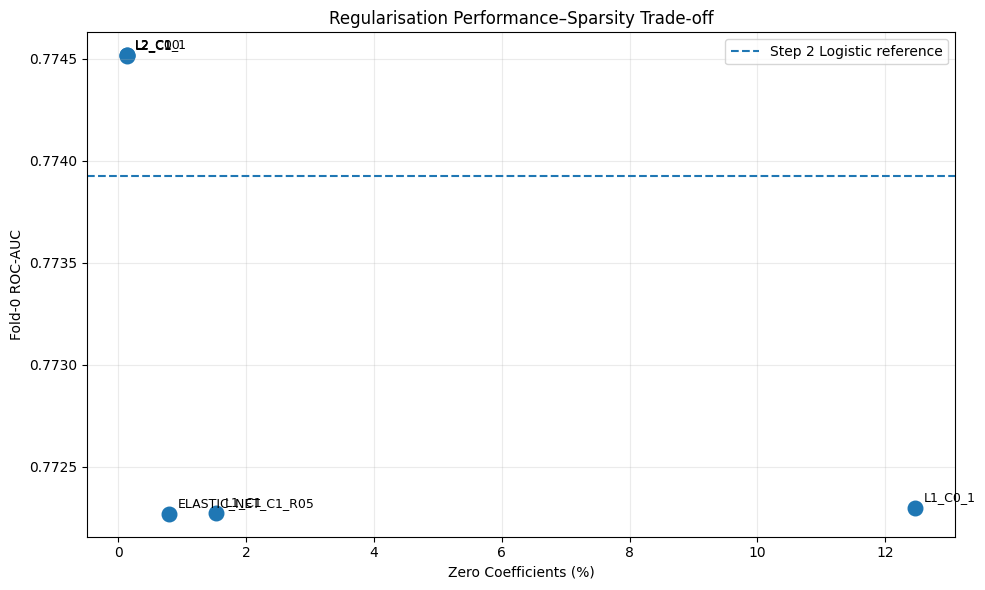

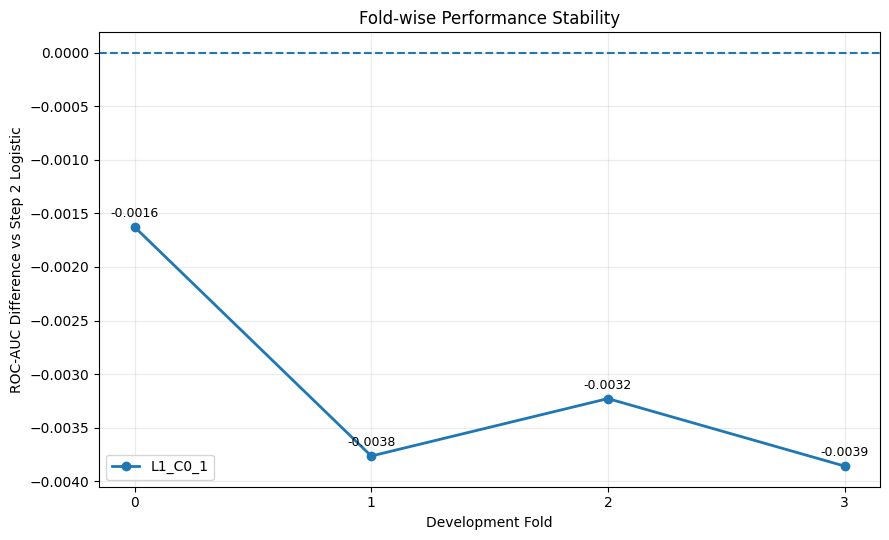

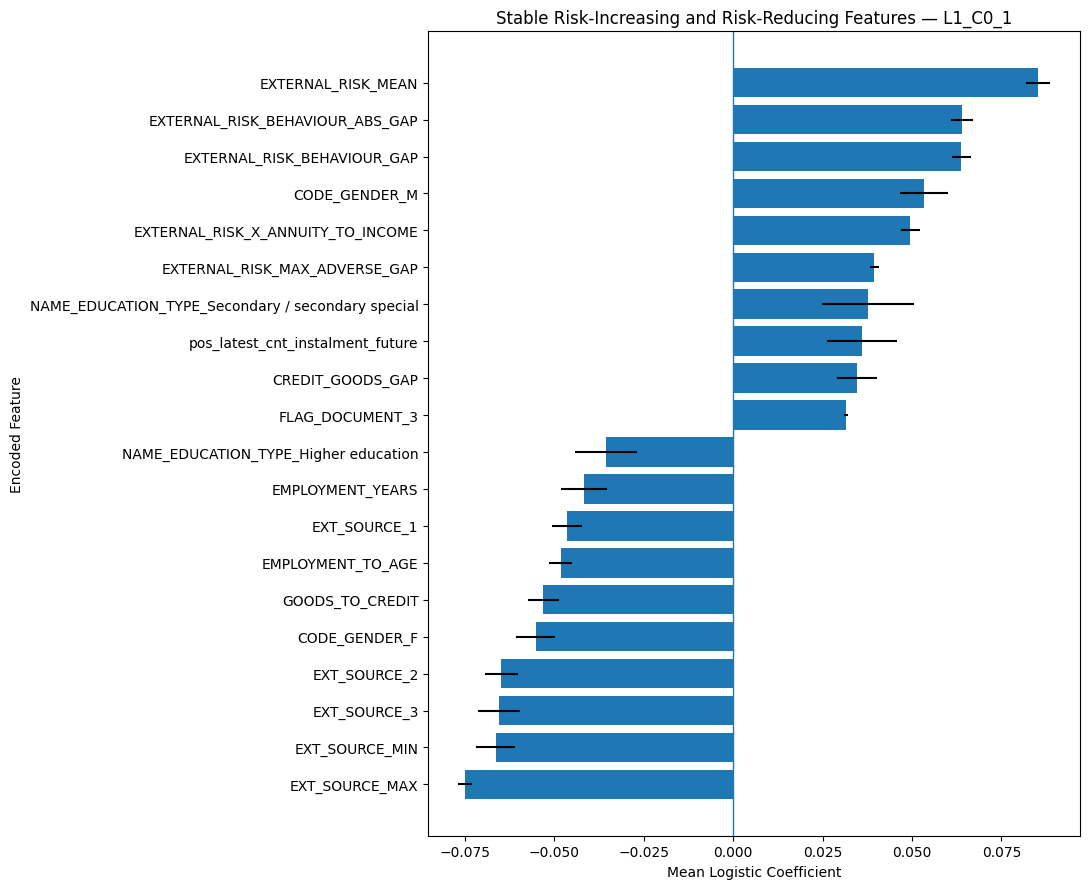

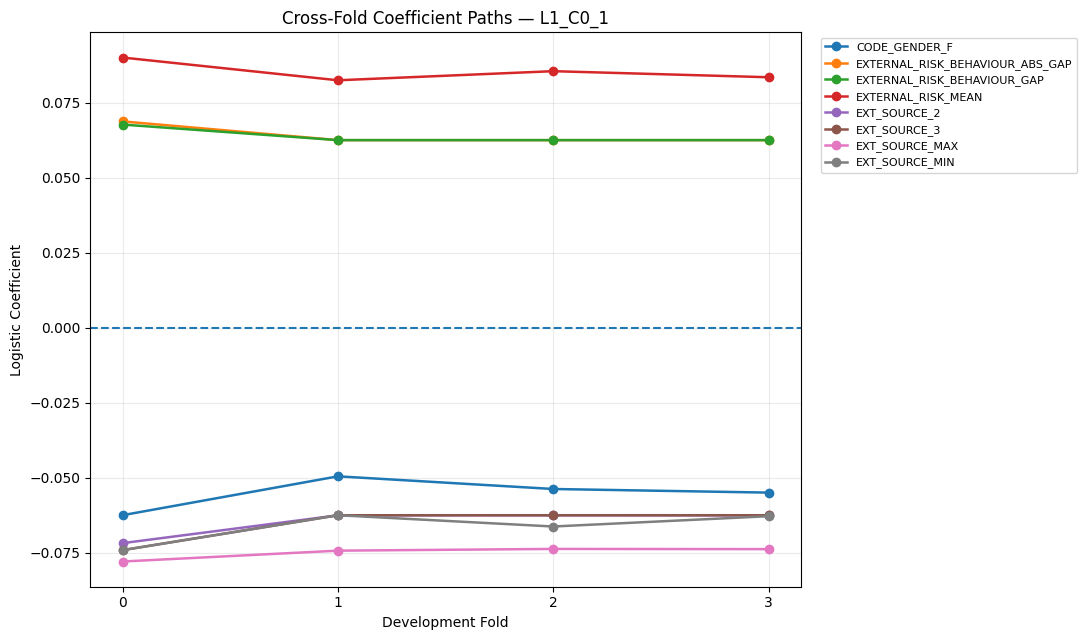

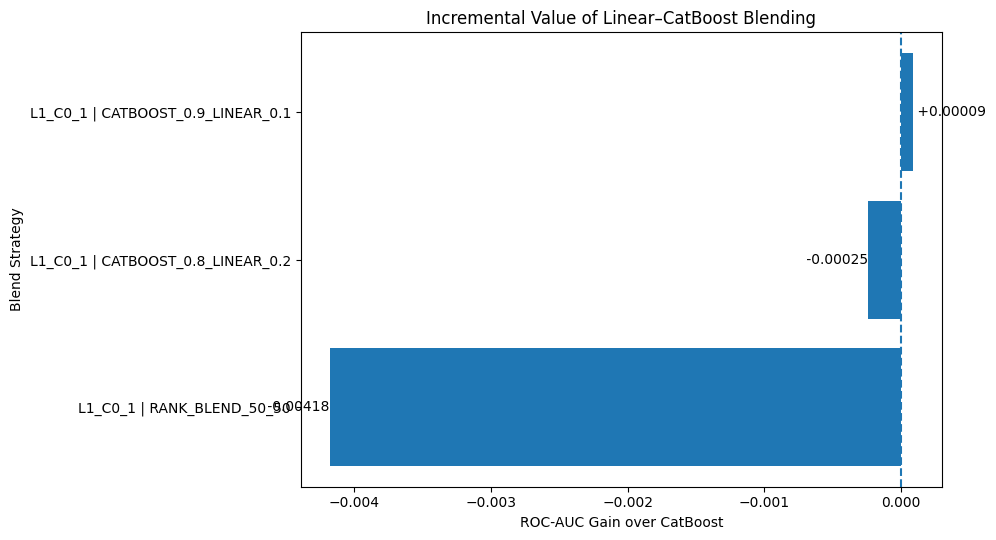

,candidate,family,roc_auc,auc_delta_vs_reference,zero_fraction,iterations,converged
0,L2_C10,L2,0.774516,0.000591,0.001334,1000,False
1,L2_C0_1,L2,0.774515,0.000591,0.001334,1000,False
2,L2_C1,L2,0.774515,0.000590,0.001334,1000,False
3,L1_C0_1,L1,0.772298,-0.001627,0.124750,347,True
4,L1_C1,L1,0.772273,-0.001652,0.015344,280,True
5,ELASTIC_NET_C1_R05,ELASTIC_NET,0.772271,-0.001654,0.008005,285,True


,model,roc_auc,pr_auc,log_loss,brier_score,ks_statistic,capture_top_10,lift_top_10,fold_auc_mean,fold_auc_std,fold_auc_gap,improved_folds_vs_reference,fit_seconds,iterations_mean,non_converged_folds,zero_fraction
0,STEP2_LOGISTIC_REFERENCE,0.777949,0.265180,0.240784,0.066672,0.41951,0.360222,3.602216,0.777995,0.004363,0.009340,0,1476.744472,453.75,0,NaN
1,L1_C0_1,0.774792,0.261483,0.241996,0.066920,0.41666,0.353575,3.535750,0.774874,0.003618,0.007786,0,2120.186747,334.25,0,0.105904


,candidate,fold,auc_delta
0,L1_C0_1,0,-0.001627
1,L1_C0_1,1,-0.003767
2,L1_C0_1,2,-0.003230
3,L1_C0_1,3,-0.003860


,candidate,display_feature,mean_coefficient,coefficient_std,stable_sign
0,L1_C0_1,EXT_SOURCE_MAX,-0.074953,0.002008,True
1,L1_C0_1,EXT_SOURCE_MIN,-0.066445,0.005421,True
2,L1_C0_1,EXT_SOURCE_3,-0.065421,0.005809,True
3,L1_C0_1,EXT_SOURCE_2,-0.064864,0.004634,True
4,L1_C0_1,CODE_GENDER_F,-0.055197,0.005395,True
5,L1_C0_1,GOODS_TO_CREDIT,-0.053099,0.004379,True
6,L1_C0_1,EMPLOYMENT_TO_AGE,-0.048246,0.003223,True
7,L1_C0_1,EXT_SOURCE_1,-0.046473,0.004218,True
8,L1_C0_1,EMPLOYMENT_YEARS,-0.041629,0.006486,True
9,L1_C0_1,NAME_EDUCATION_TYPE_Higher education,-0.035547,0.008594,True


,model,blend,roc_auc
0,L1_C0_1,CATBOOST_0.9_LINEAR_0.1,0.793458
1,STEP2_CATBOOST,BASELINE,0.793372
2,L1_C0_1,CATBOOST_0.8_LINEAR_0.2,0.793126
3,L1_C0_1,RANK_BLEND_50_50,0.789195


,check,status,observed
0,REGULARISATION_SCREENING_COMPLETE,PASS,6
1,SPARSE_ALTERNATIVE_SELECTED,PASS,['L1_C0_1']
2,DEVELOPMENT_CONFIRMATION_COMPLETE,PASS,1
3,REFERENCE_REPRODUCIBILITY,PASS,0.00059
4,OOF_ALIGNMENT,PASS,True
5,FINITE_PROBABILITIES,PASS,True
6,RESEARCH_PLOTS_COMPLETE,PASS,5
7,LOCKBOX_REMAINS_SEALED,PASS,SEALED


LINEAR CLASSIFICATION RESEARCH COMPLETE
Decision: REFERENCE_RETAINED_WITH_SPARSE_ALTERNATIVE
Performance champion: STEP2_LOGISTIC_REFERENCE
Sparse alternative: L1_C0_1
Best linear ROC-AUC: 0.777949
Research plots created: 5/5
Lockbox rows accessed: 0
Next stage: Tree and Bagging Research


In [18]:
# Step 3.6 — Final OOF Analysis and Linear-Model Interpretation

class LinearResearchAnalysis:
    @staticmethod
    def _format_feature_name(feature, maximum_length=58):
        name = str(feature).replace("numeric__", "").replace("categorical__", "")
        return name if len(name) <= maximum_length else name[:maximum_length - 3] + "..."

    @staticmethod
    def _save_plot(fig, filename):
        fig.tight_layout()
        fig.savefig(linear_figures_dir / filename, dpi=180, bbox_inches="tight")
        plt.show()
        plt.close(fig)

    @classmethod
    def _plot_performance_sparsity(cls, results, reference_auc):
        plot_data = results.copy()
        plot_data["zero_percentage"] = plot_data["zero_fraction"] * 100

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(plot_data["zero_percentage"], plot_data["roc_auc"], s=110)

        for row in plot_data.itertuples(index=False):
            ax.annotate(row.candidate, (row.zero_percentage, row.roc_auc), xytext=(6, 5), textcoords="offset points", fontsize=9)

        ax.axhline(reference_auc, linestyle="--", label="Step 2 Logistic reference")
        ax.set_xlabel("Zero Coefficients (%)")
        ax.set_ylabel("Fold-0 ROC-AUC")
        ax.set_title("Regularisation Performance–Sparsity Trade-off")
        ax.grid(alpha=0.25)
        ax.legend()

        cls._save_plot(fig, "performance_sparsity_tradeoff.png")

    @classmethod
    def _plot_fold_auc_difference(cls, fold_differences):
        fig, ax = plt.subplots(figsize=(9, 5.5))

        for candidate_name, candidate_data in fold_differences.groupby("candidate"):
            candidate_data = candidate_data.sort_values("fold")
            ax.plot(candidate_data["fold"], candidate_data["auc_delta"], marker="o", linewidth=2, label=candidate_name)

            for row in candidate_data.itertuples(index=False):
                ax.annotate(f"{row.auc_delta:+.4f}", (row.fold, row.auc_delta), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=9)

        ax.axhline(0, linestyle="--")
        ax.set_xticks(development_folds)
        ax.set_xlabel("Development Fold")
        ax.set_ylabel("ROC-AUC Difference vs Step 2 Logistic")
        ax.set_title("Fold-wise Performance Stability")
        ax.grid(alpha=0.25)
        ax.legend()

        cls._save_plot(fig, "fold_auc_difference.png")

    @classmethod
    def _plot_directional_features(cls, feature_table, candidate_name):
        plot_data = feature_table.sort_values("mean_coefficient").copy()

        fig, ax = plt.subplots(figsize=(11, 9))
        ax.barh(plot_data["display_feature"], plot_data["mean_coefficient"], xerr=plot_data["coefficient_std"].fillna(0))
        ax.axvline(0, linewidth=1)
        ax.set_xlabel("Mean Logistic Coefficient")
        ax.set_ylabel("Encoded Feature")
        ax.set_title(f"Stable Risk-Increasing and Risk-Reducing Features — {candidate_name}")

        cls._save_plot(fig, "stable_directional_features.png")

    @classmethod
    def _plot_coefficient_paths(cls, coefficients, selected_features, candidate_name):
        plot_data = coefficients.loc[
            coefficients["candidate"].eq(candidate_name)
            & coefficients["feature"].isin(selected_features)
        ].copy()

        plot_data["display_feature"] = plot_data["feature"].map(cls._format_feature_name)

        fig, ax = plt.subplots(figsize=(11, 6.5))

        for feature_name, feature_data in plot_data.groupby("display_feature"):
            feature_data = feature_data.sort_values("fold")
            ax.plot(feature_data["fold"], feature_data["coefficient"], marker="o", linewidth=1.8, label=feature_name)

        ax.axhline(0, linestyle="--")
        ax.set_xticks(development_folds)
        ax.set_xlabel("Development Fold")
        ax.set_ylabel("Logistic Coefficient")
        ax.set_title(f"Cross-Fold Coefficient Paths — {candidate_name}")
        ax.grid(alpha=0.25)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

        cls._save_plot(fig, "coefficient_paths.png")

    @classmethod
    def _plot_blend_gain(cls, blend_results):
        baseline_auc = float(blend_results.loc[blend_results["blend"].eq("BASELINE"), "roc_auc"].iloc[0])
        plot_data = blend_results.loc[~blend_results["blend"].eq("BASELINE")].copy()

        assert not plot_data.empty, "No linear blend result was created."

        plot_data["auc_gain"] = plot_data["roc_auc"] - baseline_auc
        plot_data["display_name"] = plot_data["model"] + " | " + plot_data["blend"]
        plot_data = plot_data.sort_values("auc_gain")

        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.barh(plot_data["display_name"], plot_data["auc_gain"])
        ax.axvline(0, linestyle="--")

        for position, gain in enumerate(plot_data["auc_gain"]):
            ax.text(gain, position, f" {gain:+.5f}", va="center", ha="left" if gain >= 0 else "right")

        ax.set_xlabel("ROC-AUC Gain over CatBoost")
        ax.set_ylabel("Blend Strategy")
        ax.set_title("Incremental Value of Linear–CatBoost Blending")

        cls._save_plot(fig, "blend_auc_gain.png")

    @classmethod
    def run(cls):
        if "screening_results" in globals():
            screening = globals()["screening_results"].copy()
        else:
            screening = pd.read_csv(linear_metrics_dir / "screening_results.csv")

        if "selected_candidates" in globals():
            candidates = list(globals()["selected_candidates"])
        else:
            with open(linear_study_root / "selected_candidates.json", "r", encoding="utf-8") as file:
                candidates = json.load(file)["selected_candidates"]

        assert candidates, "No confirmed sparse alternative was found."

        for candidate_name in candidates:
            for fold in development_folds:
                run_dir = linear_runs_dir / candidate_name / f"fold_{fold}"
                required_files = [run_dir / "metrics.json", run_dir / "predictions.parquet", run_dir / "coefficients.parquet"]
                assert all(path.exists() for path in required_files), f"Missing confirmed result: {candidate_name}, fold {fold}"

        logistic_oof = pd.read_parquet(STEP2_OOF_PATHS["LOGISTIC"]).sort_values("row_position").reset_index(drop=True)
        catboost_oof = pd.read_parquet(STEP2_OOF_PATHS["CATBOOST"]).sort_values("row_position").reset_index(drop=True)
        lightgbm_oof = pd.read_parquet(STEP2_OOF_PATHS["LIGHTGBM"]).sort_values("row_position").reset_index(drop=True)
        xgboost_oof = pd.read_parquet(STEP2_OOF_PATHS["XGBOOST"]).sort_values("row_position").reset_index(drop=True)

        for prediction_table in [catboost_oof, lightgbm_oof, xgboost_oof]:
            assert np.array_equal(prediction_table["row_position"].to_numpy(), logistic_oof["row_position"].to_numpy())

        reference_folds = (
            STEP2_FOLD_RESULTS
            .loc[STEP2_FOLD_RESULTS["model_key"].eq("LOGISTIC")]
            .sort_values("validation_fold")
            .reset_index(drop=True)
        )

        reference_fold_auc = float(
            reference_folds.loc[
                reference_folds["validation_fold"].eq(0),
                "roc_auc"
            ].iloc[0]
        )

        if "auc_delta_vs_reference" not in screening.columns:
            screening["auc_delta_vs_reference"] = screening["roc_auc"] - reference_fold_auc

        reference_iterations = (
            float(pd.to_numeric(reference_folds["best_iteration"], errors="coerce").mean())
            if "best_iteration" in reference_folds.columns else np.nan
        )

        reference_non_converged = (
            int(reference_folds["status"].astype(str).str.contains("CONVERGENCE_REVIEW").sum())
            if "status" in reference_folds.columns else 0
        )

        overall_records = [{
            "model": "STEP2_LOGISTIC_REFERENCE",
            **evaluate_probabilities(logistic_oof[TARGET_COLUMN], logistic_oof["probability"]),
            "fold_auc_mean": float(reference_folds["roc_auc"].mean()),
            "fold_auc_std": float(reference_folds["roc_auc"].std(ddof=1)),
            "fold_auc_gap": float(reference_folds["roc_auc"].max() - reference_folds["roc_auc"].min()),
            "improved_folds_vs_reference": 0,
            "fit_seconds": float(reference_folds["fit_seconds"].sum()),
            "iterations_mean": reference_iterations,
            "non_converged_folds": reference_non_converged,
            "zero_fraction": np.nan
        }]

        confirmed_oof = {}
        coefficient_tables = []
        fold_difference_records = []

        for candidate_name in candidates:
            prediction_parts, metric_parts, coefficient_parts = [], [], []

            for fold in development_folds:
                run_dir = linear_runs_dir / candidate_name / f"fold_{fold}"
                prediction_parts.append(pd.read_parquet(run_dir / "predictions.parquet"))
                coefficient_parts.append(pd.read_parquet(run_dir / "coefficients.parquet"))

                with open(run_dir / "metrics.json", "r", encoding="utf-8") as file:
                    metric_parts.append(json.load(file))

            candidate_oof = pd.concat(prediction_parts, ignore_index=True).sort_values("row_position").reset_index(drop=True)
            candidate_fold_metrics = pd.DataFrame(metric_parts).sort_values("fold").reset_index(drop=True)
            candidate_coefficients = pd.concat(coefficient_parts, ignore_index=True)

            assert np.array_equal(candidate_oof["row_position"].to_numpy(), DEVELOPMENT_REGISTRY["row_position"].to_numpy())

            candidate_fold_metrics["auc_delta_vs_reference"] = (
                candidate_fold_metrics["roc_auc"].to_numpy()
                - reference_folds["roc_auc"].to_numpy()
            )

            for row in candidate_fold_metrics.itertuples(index=False):
                fold_difference_records.append({
                    "candidate": candidate_name,
                    "fold": int(row.fold),
                    "auc_delta": float(row.auc_delta_vs_reference)
                })

            overall_records.append({
                "model": candidate_name,
                **evaluate_probabilities(candidate_oof[TARGET_COLUMN], candidate_oof["probability"]),
                "fold_auc_mean": float(candidate_fold_metrics["roc_auc"].mean()),
                "fold_auc_std": float(candidate_fold_metrics["roc_auc"].std(ddof=1)),
                "fold_auc_gap": float(candidate_fold_metrics["roc_auc"].max() - candidate_fold_metrics["roc_auc"].min()),
                "improved_folds_vs_reference": int(candidate_fold_metrics["auc_delta_vs_reference"].gt(0).sum()),
                "fit_seconds": float(candidate_fold_metrics["fit_seconds"].sum()),
                "iterations_mean": float(candidate_fold_metrics["iterations"].mean()),
                "non_converged_folds": int((~candidate_fold_metrics["converged"]).sum()),
                "zero_fraction": float(candidate_fold_metrics["zero_fraction"].mean())
            })

            candidate_oof.to_parquet(linear_oof_dir / f"{candidate_name.lower()}_oof.parquet", index=False, compression="zstd")
            candidate_fold_metrics.to_csv(linear_metrics_dir / f"{candidate_name.lower()}_fold_metrics.csv", index=False)

            confirmed_oof[candidate_name] = candidate_oof
            coefficient_tables.append(candidate_coefficients)

        linear_oof_results = pd.DataFrame(overall_records).sort_values("roc_auc", ascending=False).reset_index(drop=True)
        linear_oof_results.to_csv(linear_metrics_dir / "oof_results.csv", index=False)

        fold_differences = pd.DataFrame(fold_difference_records)
        fold_differences.to_csv(linear_metrics_dir / "fold_auc_differences.csv", index=False)

        probability_table = pd.DataFrame({
            "STEP2_LOGISTIC": logistic_oof["probability"].to_numpy(),
            "STEP2_CATBOOST": catboost_oof["probability"].to_numpy(),
            "STEP2_LIGHTGBM": lightgbm_oof["probability"].to_numpy(),
            "STEP2_XGBOOST": xgboost_oof["probability"].to_numpy(),
            **{candidate_name: table["probability"].to_numpy() for candidate_name, table in confirmed_oof.items()}
        })

        prediction_correlation = probability_table.corr()
        prediction_correlation.to_csv(linear_metrics_dir / "prediction_correlation.csv")

        target = logistic_oof[TARGET_COLUMN].to_numpy(dtype=np.int8)
        catboost_probability = catboost_oof["probability"].to_numpy()

        blend_records = [{
            "model": "STEP2_CATBOOST",
            "blend": "BASELINE",
            "roc_auc": float(roc_auc_score(target, catboost_probability))
        }]

        for candidate_name, candidate_table in confirmed_oof.items():
            linear_probability = candidate_table["probability"].to_numpy()

            for linear_weight in [0.10, 0.20]:
                blended_probability = (1 - linear_weight) * catboost_probability + linear_weight * linear_probability

                blend_records.append({
                    "model": candidate_name,
                    "blend": f"CATBOOST_{1-linear_weight:.1f}_LINEAR_{linear_weight:.1f}",
                    "roc_auc": float(roc_auc_score(target, blended_probability))
                })

            rank_blend = (
                0.5 * pd.Series(catboost_probability).rank(pct=True).to_numpy()
                + 0.5 * pd.Series(linear_probability).rank(pct=True).to_numpy()
            )

            blend_records.append({
                "model": candidate_name,
                "blend": "RANK_BLEND_50_50",
                "roc_auc": float(roc_auc_score(target, rank_blend))
            })

        blend_results = pd.DataFrame(blend_records)
        blend_results.to_csv(linear_metrics_dir / "blend_diagnostics.csv", index=False)

        all_coefficients = pd.concat(coefficient_tables, ignore_index=True)
        all_coefficients.to_parquet(linear_explanations_dir / "coefficients_by_fold.parquet", index=False, compression="zstd")

        coefficient_stability = (
            all_coefficients
            .groupby(["candidate", "feature"], observed=True)
            .agg(
                folds_present=("fold", "nunique"),
                mean_coefficient=("coefficient", "mean"),
                coefficient_std=("coefficient", "std"),
                positive_folds=("coefficient", lambda values: int((np.asarray(values) > 1e-8).sum())),
                negative_folds=("coefficient", lambda values: int((np.asarray(values) < -1e-8).sum())),
                zero_folds=("coefficient", lambda values: int((np.abs(np.asarray(values)) <= 1e-8).sum()))
            )
            .reset_index()
        )

        coefficient_stability["absolute_mean"] = coefficient_stability["mean_coefficient"].abs()
        coefficient_stability["stable_sign"] = (
            coefficient_stability["folds_present"].eq(4)
            & (
                coefficient_stability["positive_folds"].eq(4)
                | coefficient_stability["negative_folds"].eq(4)
            )
        )
        coefficient_stability["relative_variation"] = (
            coefficient_stability["coefficient_std"]
            / coefficient_stability["absolute_mean"].clip(lower=1e-8)
        )

        coefficient_stability.to_csv(linear_explanations_dir / "coefficient_stability.csv", index=False)

        interpretation_model = candidates[0]
        model_stability = coefficient_stability.loc[
            coefficient_stability["candidate"].eq(interpretation_model)
        ].copy()

        stable_features = model_stability.loc[
            model_stability["stable_sign"]
            & model_stability["absolute_mean"].gt(1e-8)
        ].copy()

        if len(stable_features) < 20:
            stable_features = model_stability.loc[
                model_stability["folds_present"].ge(3)
                & model_stability["absolute_mean"].gt(1e-8)
            ].copy()

        strongest_positive = stable_features.nlargest(10, "mean_coefficient")
        strongest_negative = stable_features.nsmallest(10, "mean_coefficient")

        top_directional_features = (
            pd.concat([strongest_negative, strongest_positive])
            .drop_duplicates("feature")
            .sort_values("mean_coefficient")
            .copy()
        )

        top_directional_features["display_feature"] = top_directional_features["feature"].map(cls._format_feature_name)
        top_directional_features.to_csv(linear_explanations_dir / "top_directional_features.csv", index=False)

        coefficient_path_features = (
            model_stability
            .loc[
                model_stability["folds_present"].ge(3)
                & model_stability["absolute_mean"].gt(1e-8)
            ]
            .sort_values(["stable_sign", "absolute_mean"], ascending=[False, False])
            .head(8)["feature"]
            .tolist()
        )

        assert not top_directional_features.empty, "No coefficient interpretation features were found."
        assert coefficient_path_features, "No coefficient path features were found."

        cls._plot_performance_sparsity(screening, reference_fold_auc)
        cls._plot_fold_auc_difference(fold_differences)
        cls._plot_directional_features(top_directional_features, interpretation_model)
        cls._plot_coefficient_paths(all_coefficients, coefficient_path_features, interpretation_model)
        cls._plot_blend_gain(blend_results)

        expected_plot_files = [
            "performance_sparsity_tradeoff.png",
            "fold_auc_difference.png",
            "stable_directional_features.png",
            "coefficient_paths.png",
            "blend_auc_gain.png"
        ]

        missing_plots = [
            filename
            for filename in expected_plot_files
            if not (linear_figures_dir / filename).exists()
        ]

        control_gap = float(
            screening.loc[
                screening["candidate"].eq("L2_C1"),
                "auc_delta_vs_reference"
            ].abs().iloc[0]
        )

        alignment_valid = all(
            np.array_equal(table["row_position"].to_numpy(), DEVELOPMENT_REGISTRY["row_position"].to_numpy())
            for table in confirmed_oof.values()
        )

        finite_probabilities = all(
            np.isfinite(table["probability"]).all()
            for table in [logistic_oof, catboost_oof, lightgbm_oof, xgboost_oof, *confirmed_oof.values()]
        )

        validation_report = pd.DataFrame([
            {"check": "REGULARISATION_SCREENING_COMPLETE", "status": "PASS" if len(screening) == len(linear_candidates) else "FAIL", "observed": len(screening)},
            {"check": "SPARSE_ALTERNATIVE_SELECTED", "status": "PASS" if bool(candidates) else "FAIL", "observed": str(candidates)},
            {"check": "DEVELOPMENT_CONFIRMATION_COMPLETE", "status": "PASS" if len(confirmed_oof) == len(candidates) else "FAIL", "observed": len(confirmed_oof)},
            {"check": "REFERENCE_REPRODUCIBILITY", "status": "PASS" if control_gap <= 0.002 else "FAIL", "observed": control_gap},
            {"check": "OOF_ALIGNMENT", "status": "PASS" if alignment_valid else "FAIL", "observed": alignment_valid},
            {"check": "FINITE_PROBABILITIES", "status": "PASS" if finite_probabilities else "FAIL", "observed": finite_probabilities},
            {"check": "RESEARCH_PLOTS_COMPLETE", "status": "PASS" if not missing_plots else "FAIL", "observed": len(expected_plot_files) - len(missing_plots)},
            {
                "check": "LOCKBOX_REMAINS_SEALED",
                "status": "PASS" if LOCKBOX_CONTROL["status"] == "SEALED" and int(LOCKBOX_CONTROL["evaluation_count"]) == 0 else "FAIL",
                "observed": LOCKBOX_CONTROL["status"]
            }
        ])

        validation_report.to_csv(linear_metrics_dir / "validation_report.csv", index=False)
        assert not validation_report["status"].eq("FAIL").any()

        performance_champion = linear_oof_results.iloc[0]["model"]
        sparse_alternative = candidates[0]

        decision = (
            "REFERENCE_RETAINED_WITH_SPARSE_ALTERNATIVE"
            if performance_champion == "STEP2_LOGISTIC_REFERENCE"
            else "ALTERNATIVE_LINEAR_MODEL_CONFIRMED"
        )

        linear_summary = {
            "status": "LINEAR_CLASSIFICATION_RESEARCH_COMPLETE",
            "decision": decision,
            "screened_configurations": len(linear_candidates),
            "confirmed_configurations": candidates,
            "performance_champion": performance_champion,
            "sparse_alternative": sparse_alternative,
            "best_linear_roc_auc": float(linear_oof_results.iloc[0]["roc_auc"]),
            "research_plots": expected_plot_files,
            "lockbox_rows_accessed": 0,
            "next_stage": "TREE_AND_BAGGING_RESEARCH"
        }

        with open(linear_study_root / "summary.json", "w", encoding="utf-8") as file:
            json.dump(linear_summary, file, indent=2)

        display(
            screening[[
                "candidate", "family", "roc_auc",
                "auc_delta_vs_reference", "zero_fraction",
                "iterations", "converged"
            ]]
        )

        display(linear_oof_results)
        display(fold_differences.sort_values(["candidate", "fold"]).reset_index(drop=True))

        display(
            top_directional_features[[
                "candidate", "display_feature",
                "mean_coefficient", "coefficient_std",
                "stable_sign"
            ]].reset_index(drop=True)
        )

        display(blend_results.sort_values("roc_auc", ascending=False).reset_index(drop=True))
        display(validation_report)

        print("=" * 90)
        print("LINEAR CLASSIFICATION RESEARCH COMPLETE")
        print(f"Decision: {decision}")
        print(f"Performance champion: {performance_champion}")
        print(f"Sparse alternative: {sparse_alternative}")
        print(f"Best linear ROC-AUC: {linear_summary['best_linear_roc_auc']:.6f}")
        print(f"Research plots created: {len(expected_plot_files)}/5")
        print("Lockbox rows accessed: 0")
        print("Next stage: Tree and Bagging Research")
        print("=" * 90)

        return {
            "screening_results": screening,
            "oof_results": linear_oof_results,
            "fold_differences": fold_differences,
            "prediction_correlation": prediction_correlation,
            "blend_results": blend_results,
            "coefficient_stability": coefficient_stability,
            "top_directional_features": top_directional_features,
            "validation_report": validation_report,
            "summary": linear_summary
        }


linear_research_outputs = LinearResearchAnalysis.run()

## Linear Classification Decision

The Step 2 Logistic Regression remains the linear performance champion.  
The confirmed L1 model with `C = 0.1` reduced the active coefficient set by approximately 10.6%, but its development OOF ROC-AUC decreased from 0.777949 to 0.774792 and it underperformed the reference on all four development folds.

The L1 model is therefore retained as an interpretable sparse alternative rather than as the primary linear model. Its 10% probability blend with CatBoost produced a small diagnostic ROC-AUC gain of approximately 0.000086, so it remains eligible for controlled blending analysis in Step 10.

No lockbox data were accessed.

# Step 4 — Tree and Bagging Research 🌲

## Research Aim

This stage investigates whether randomised tree ensembles can improve the verified Random Forest baseline or provide useful prediction diversity for later ensemble modelling.

The study examines:

- Random Forest and Extra Trees architectures
- Feature subsampling strategies
- Discrimination and probability quality
- Fold-to-fold stability
- Tree complexity and computational efficiency
- Feature-importance stability
- Prediction diversity relative to CatBoost

## Experimental Boundary

- **Feature set:** Compact
- **Screening split:** Development fold 0
- **Confirmation splits:** Development folds 1–3
- **Reference model:** Step 2 Random Forest
- **Lockbox fold 4:** Sealed
- **Test data:** Not accessed

## Interruption Recovery

Each completed candidate–fold fit is saved immediately. Under normal conditions, each execution cell is run once. Following an interruption, rerunning the same cell skips completed fits and continues with the remaining work.

## Step 4.1 — Define the Tree-Ensemble Study 🌲

Four fixed tree-ensemble configurations are evaluated:

- Random Forest with square-root feature sampling
- Random Forest with wider feature sampling
- Extra Trees with square-root feature sampling
- Extra Trees with wider feature sampling

The configurations isolate two architectural decisions:

1. **Split generation:** optimised splits versus randomised splits
2. **Feature sampling:** narrow versus wider candidate-feature sets

The verified Step 2 Random Forest remains the frozen tree reference.

In [19]:
# Step 4.1 — Tree-Ensemble Research Contract

import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score, roc_curve
from sklearn.preprocessing import OrdinalEncoder
from IPython.display import display

required_objects = [
    "DIRS", "STEP2_DATA_PATH", "STEP2_DATA_MANIFEST",
    "STEP2_FOLD_RESULTS", "STEP2_BASELINE_RESULTS",
    "STEP2_OOF_PATHS", "DEVELOPMENT_REGISTRY",
    "LOCKBOX_CONTROL", "COMPACT_FEATURES",
    "ID_COLUMN", "TARGET_COLUMN"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

assert not missing_objects, (
    f"Run Steps 0–3 or the temporary restore cell first: {missing_objects}"
)

assert LOCKBOX_CONTROL["status"] == "SEALED"
assert int(LOCKBOX_CONTROL["evaluation_count"]) == 0
assert "RANDOM_FOREST" in STEP2_OOF_PATHS
assert "CATBOOST" in STEP2_OOF_PATHS

tree_study_root = DIRS["checkpoints"] / "tree_bagging_study_v1"
tree_cache_dir = tree_study_root / "fold_cache"
tree_runs_dir = tree_study_root / "candidate_runs"
tree_metrics_dir = DIRS["metrics"] / "tree_bagging_study_v1"
tree_oof_dir = DIRS["oof"] / "tree_bagging_study_v1"
tree_figures_dir = DIRS["figures"] / "tree_bagging_study_v1"
tree_explanations_dir = DIRS["explanations"] / "tree_bagging_study_v1"

for path in [
    tree_study_root,
    tree_cache_dir,
    tree_runs_dir,
    tree_metrics_dir,
    tree_oof_dir,
    tree_figures_dir,
    tree_explanations_dir
]:
    path.mkdir(parents=True, exist_ok=True)

tree_candidates = {
    "RF_SQRT": {
        "family": "RANDOM_FOREST",
        "max_features": "sqrt"
    },
    "RF_WIDE": {
        "family": "RANDOM_FOREST",
        "max_features": 0.15
    },
    "ET_SQRT": {
        "family": "EXTRA_TREES",
        "max_features": "sqrt"
    },
    "ET_WIDE": {
        "family": "EXTRA_TREES",
        "max_features": 0.15
    }
}

tree_training_parameters = {
    "n_estimators": 300,
    "criterion": "gini",
    "max_depth": 18,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "random_state": 42,
    "n_jobs": -1
}

development_folds = [0, 1, 2, 3]
screening_fold = 0
confirmation_folds = [1, 2, 3]

tree_experiment_contract = {
    "candidates": tree_candidates,
    "training_parameters": tree_training_parameters,
    "development_folds": development_folds,
    "screening_fold": screening_fold,
    "confirmation_folds": confirmation_folds,
    "feature_set": "COMPACT",
    "reference_model": "STEP2_RANDOM_FOREST"
}

with open(
    tree_study_root / "experiment_contract.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(tree_experiment_contract, file, indent=2)

reference_columns = [
    column for column in [
        "model_key", "model_family", "roc_auc",
        "pr_auc", "log_loss", "brier_score"
    ]
    if column in STEP2_BASELINE_RESULTS.columns
]

display(
    STEP2_BASELINE_RESULTS[reference_columns]
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

print("=" * 90)
print("TREE AND BAGGING STUDY DEFINED")
print(f"Candidate configurations: {len(tree_candidates)}")
print(f"Trees per configuration: {tree_training_parameters['n_estimators']}")
print(f"Maximum depth: {tree_training_parameters['max_depth']}")
print(f"Minimum samples per leaf: {tree_training_parameters['min_samples_leaf']}")
print("Step 2 Random Forest reference reused: YES")
print(f"Lockbox status: {LOCKBOX_CONTROL['status']}")
print("Training performed: NO")
print("=" * 90)

,model_key,model_family,roc_auc,pr_auc,log_loss,brier_score
0,CATBOOST,CatBoost,0.793372,0.288452,0.235049,0.065469
1,LIGHTGBM,LightGBM,0.791953,0.287065,0.235479,0.065569
2,XGBOOST,XGBoost,0.791686,0.287068,0.235500,0.065564
3,LOGISTIC,Logistic Regression,0.777949,0.265180,0.240784,0.066672
4,RANDOM_FOREST,Random Forest,0.761699,0.247733,0.247430,0.068090
5,PRIOR,Prior Probability,0.499998,0.080729,0.280546,0.074212


TREE AND BAGGING STUDY DEFINED
Candidate configurations: 4
Trees per configuration: 300
Maximum depth: 18
Minimum samples per leaf: 10
Step 2 Random Forest reference reused: YES
Lockbox status: SEALED
Training performed: NO


## Step 4.2 — Prepare Tree-Ready Fold Data 🧰

Tree ensembles do not require standardisation or one-hot encoding.

The preprocessing strategy is:

- **Numeric predictors:** median imputation
- **Categorical predictors:** ordinal encoding
- **Unknown categories:** encoded as `-1`
- **Missing categories:** represented by an explicit missing label
- **Output type:** dense `float32` matrix

Preprocessing is fitted only on each fold's training rows. The prepared matrices are saved once and reused by every tree candidate.

In [20]:
# Step 4.2 — Fold-Safe Tree Data Workspace

class TreeDataWorkspace:
    @staticmethod
    def _paths(fold):
        fold_dir = tree_cache_dir / f"fold_{fold}"
        fold_dir.mkdir(parents=True, exist_ok=True)

        return {
            "directory": fold_dir,
            "manifest": fold_dir / "manifest.json",
            "X_train": fold_dir / "X_train.npy",
            "X_valid": fold_dir / "X_valid.npy",
            "y_train": fold_dir / "y_train.npy",
            "y_valid": fold_dir / "y_valid.npy",
            "metadata": fold_dir / "validation_metadata.parquet",
            "features": fold_dir / "feature_names.csv",
            "preprocessor": fold_dir / "preprocessor.joblib"
        }

    @classmethod
    def load_fold(cls, fold):
        paths = cls._paths(fold)

        required_paths = [
            paths["manifest"], paths["X_train"], paths["X_valid"],
            paths["y_train"], paths["y_valid"], paths["metadata"],
            paths["features"], paths["preprocessor"]
        ]

        assert all(path.exists() for path in required_paths), (
            f"Prepared data for fold {fold} is incomplete."
        )

        with open(paths["manifest"], "r", encoding="utf-8") as file:
            manifest = json.load(file)

        return {
            "X_train": np.load(paths["X_train"], mmap_mode="r"),
            "X_valid": np.load(paths["X_valid"], mmap_mode="r"),
            "y_train": np.load(paths["y_train"], mmap_mode="r"),
            "y_valid": np.load(paths["y_valid"], mmap_mode="r"),
            "metadata": pd.read_parquet(paths["metadata"]),
            "feature_names": pd.read_csv(paths["features"])["feature"].astype(str).to_numpy(),
            "manifest": manifest
        }

    @classmethod
    def prepare_fold(cls, fold):
        paths = cls._paths(fold)

        if paths["manifest"].exists():
            with open(paths["manifest"], "r", encoding="utf-8") as file:
                manifest = json.load(file)

            cache_valid = (
                manifest.get("feature_hash") == STEP2_DATA_MANIFEST["feature_hash"]
                and all(
                    paths[name].exists()
                    for name in [
                        "X_train", "X_valid", "y_train",
                        "y_valid", "metadata",
                        "features", "preprocessor"
                    ]
                )
            )

            if cache_valid:
                return cls.load_fold(fold)

        start = time.perf_counter()

        selected_columns = list(dict.fromkeys(
            ["row_position", ID_COLUMN, TARGET_COLUMN, "outer_fold"]
            + COMPACT_FEATURES
        ))

        data = pd.read_parquet(
            STEP2_DATA_PATH,
            columns=selected_columns
        )

        train = (
            data.loc[data["outer_fold"].ne(fold)]
            .reset_index(drop=True)
        )

        valid = (
            data.loc[data["outer_fold"].eq(fold)]
            .sort_values("row_position")
            .reset_index(drop=True)
        )

        numeric_features = [
            feature
            for feature in STEP2_DATA_MANIFEST["numeric_features"]
            if feature in COMPACT_FEATURES
        ]

        categorical_features = [
            feature
            for feature in STEP2_DATA_MANIFEST["categorical_features"]
            if feature in COMPACT_FEATURES
        ]

        typed_features = set(numeric_features + categorical_features)

        numeric_features += [
            feature
            for feature in COMPACT_FEATURES
            if feature not in typed_features
        ]

        for feature in numeric_features:
            train[feature] = pd.to_numeric(
                train[feature],
                errors="coerce"
            ).astype(np.float32)

            valid[feature] = pd.to_numeric(
                valid[feature],
                errors="coerce"
            ).astype(np.float32)

        for feature in categorical_features:
            train[feature] = (
                train[feature]
                .astype("string")
                .fillna("__MISSING__")
                .astype(str)
            )

            valid[feature] = (
                valid[feature]
                .astype("string")
                .fillna("__MISSING__")
                .astype(str)
            )

        categorical_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            dtype=np.float32
        )

        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    SimpleImputer(
                        strategy="median",
                        keep_empty_features=True
                    ),
                    numeric_features
                ),
                (
                    "categorical",
                    categorical_encoder,
                    categorical_features
                )
            ],
            remainder="drop",
            n_jobs=1
        )

        X_train = np.asarray(
            preprocessor.fit_transform(train[COMPACT_FEATURES]),
            dtype=np.float32,
            order="C"
        )

        X_valid = np.asarray(
            preprocessor.transform(valid[COMPACT_FEATURES]),
            dtype=np.float32,
            order="C"
        )

        y_train = train[TARGET_COLUMN].to_numpy(dtype=np.int8)
        y_valid = valid[TARGET_COLUMN].to_numpy(dtype=np.int8)

        validation_metadata = valid[[
            "row_position",
            ID_COLUMN,
            TARGET_COLUMN,
            "outer_fold"
        ]].copy()

        feature_names = (
            preprocessor
            .get_feature_names_out()
            .astype(str)
        )

        np.save(paths["X_train"], X_train)
        np.save(paths["X_valid"], X_valid)
        np.save(paths["y_train"], y_train)
        np.save(paths["y_valid"], y_valid)

        validation_metadata.to_parquet(
            paths["metadata"],
            index=False,
            compression="zstd"
        )

        pd.DataFrame({
            "feature": feature_names
        }).to_csv(
            paths["features"],
            index=False
        )

        joblib.dump(
            preprocessor,
            paths["preprocessor"],
            compress=3
        )

        matrix_size_mb = (
            X_train.nbytes + X_valid.nbytes
        ) / 2**20

        manifest = {
            "fold": int(fold),
            "feature_hash": STEP2_DATA_MANIFEST["feature_hash"],
            "training_rows": int(len(y_train)),
            "validation_rows": int(len(y_valid)),
            "features": int(X_train.shape[1]),
            "numeric_features": int(len(numeric_features)),
            "categorical_features": int(len(categorical_features)),
            "matrix_size_mb": float(matrix_size_mb),
            "preparation_seconds": float(
                time.perf_counter() - start
            )
        }

        with open(
            paths["manifest"],
            "w",
            encoding="utf-8"
        ) as file:
            json.dump(manifest, file, indent=2)

        del data, train, valid
        del X_train, X_valid, y_train, y_valid
        gc.collect()

        return cls.load_fold(fold)


print("TreeDataWorkspace is ready.")

TreeDataWorkspace is ready.


## Step 4.3 — Screen the Tree Ensembles 🧪

The four candidates are evaluated on the same development split.

### Experimental Split

- **Training:** Folds 1–3
- **Validation:** Fold 0
- **Reference:** Step 2 Random Forest
- **Lockbox:** Sealed

The model-fitting function remains visible to preserve a clear scikit-learn workflow. Each completed candidate is saved immediately.

Under normal conditions, run the screening cell once. Following an interruption, rerun the same cell to skip completed candidates and continue with the remaining work.

In [21]:
# Step 4.3 — Visible Tree Evaluation and Model-Fitting Functions

def evaluate_tree_probabilities(y_true, probability):
    y_true = np.asarray(y_true, dtype=np.int8)

    probability = np.clip(
        np.asarray(probability, dtype=np.float64),
        1e-7,
        1 - 1e-7
    )

    fpr, tpr, _ = roc_curve(y_true, probability)

    top_count = max(
        1,
        int(np.ceil(len(y_true) * 0.10))
    )

    top_positions = np.argpartition(
        -probability,
        top_count - 1
    )[:top_count]

    capture = float(
        y_true[top_positions].sum()
        / max(y_true.sum(), 1)
    )

    return {
        "roc_auc": float(
            roc_auc_score(y_true, probability)
        ),
        "pr_auc": float(
            average_precision_score(y_true, probability)
        ),
        "log_loss": float(
            log_loss(
                y_true,
                probability,
                labels=[0, 1]
            )
        ),
        "brier_score": float(
            brier_score_loss(y_true, probability)
        ),
        "ks_statistic": float(
            np.max(tpr - fpr)
        ),
        "capture_top_10": capture,
        "lift_top_10": capture / 0.10
    }


def fit_tree_candidate(candidate_name, fold, prepared_fold=None):
    run_dir = (
        tree_runs_dir
        / candidate_name
        / f"fold_{fold}"
    )

    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_path = run_dir / "metrics.json"
    prediction_path = run_dir / "predictions.parquet"
    importance_path = run_dir / "feature_importance.parquet"
    model_path = run_dir / "model.joblib"

    completed_paths = [
        metrics_path,
        prediction_path,
        importance_path,
        model_path
    ]

    if all(path.exists() for path in completed_paths):
        with open(metrics_path, "r", encoding="utf-8") as file:
            return json.load(file)

    if prepared_fold is None:
        prepared_fold = TreeDataWorkspace.prepare_fold(fold)

    X_train = prepared_fold["X_train"]
    X_valid = prepared_fold["X_valid"]
    y_train = prepared_fold["y_train"]
    y_valid = prepared_fold["y_valid"]
    metadata = prepared_fold["metadata"]
    feature_names = prepared_fold["feature_names"]

    candidate = tree_candidates[candidate_name]

    model_parameters = {
        **tree_training_parameters,
        "max_features": candidate["max_features"]
    }

    if candidate["family"] == "RANDOM_FOREST":
        model = RandomForestClassifier(
            **model_parameters,
            bootstrap=True,
            max_samples=0.80
        )
    else:
        model = ExtraTreesClassifier(
            **model_parameters,
            bootstrap=False
        )

    fit_start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start

    prediction_start = time.perf_counter()
    probability = model.predict_proba(X_valid)[:, 1]
    prediction_seconds = (
        time.perf_counter() - prediction_start
    )

    tree_depths = np.array([
        estimator.tree_.max_depth
        for estimator in model.estimators_
    ])

    leaf_counts = np.array([
        estimator.tree_.n_leaves
        for estimator in model.estimators_
    ])

    prediction_table = metadata.copy()
    prediction_table["probability"] = probability.astype(np.float32)

    importance_table = pd.DataFrame({
        "candidate": candidate_name,
        "family": candidate["family"],
        "fold": int(fold),
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    prediction_table.to_parquet(
        prediction_path,
        index=False,
        compression="zstd"
    )

    importance_table.to_parquet(
        importance_path,
        index=False,
        compression="zstd"
    )

    joblib.dump(
        model,
        model_path,
        compress=3
    )

    metrics = {
        "candidate": candidate_name,
        "family": candidate["family"],
        "fold": int(fold),
        **evaluate_tree_probabilities(
            y_valid,
            probability
        ),
        "fit_seconds": float(fit_seconds),
        "prediction_seconds": float(prediction_seconds),
        "n_estimators": int(len(model.estimators_)),
        "mean_tree_depth": float(tree_depths.mean()),
        "maximum_tree_depth": int(tree_depths.max()),
        "mean_leaf_count": float(leaf_counts.mean()),
        "maximum_leaf_count": int(leaf_counts.max()),
        "max_features": candidate["max_features"],
        "model_size_mb": float(
            model_path.stat().st_size / 2**20
        )
    }

    temporary_metrics_path = (
        metrics_path.with_suffix(".tmp.json")
    )

    with open(
        temporary_metrics_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(metrics, file, indent=2)

    temporary_metrics_path.replace(metrics_path)

    del model
    gc.collect()

    return metrics


print("Tree evaluation and model-fitting functions are ready.")

Tree evaluation and model-fitting functions are ready.


In [22]:
# Step 4.3 — Tree-Ensemble Screening

screening_data = TreeDataWorkspace.prepare_fold(screening_fold)
screening_manifest = screening_data["manifest"]

print("=" * 90)
print("TREE SCREENING DATA READY")
print(f"Training rows: {screening_manifest['training_rows']:,}")
print(f"Validation rows: {screening_manifest['validation_rows']:,}")
print(f"Features: {screening_manifest['features']:,}")
print(f"Matrix size: {screening_manifest['matrix_size_mb']:.1f} MB")
print(
    f"Preparation time: "
    f"{screening_manifest['preparation_seconds'] / 60:.2f} minutes"
)
print("=" * 90)

for candidate_name in tree_candidates:
    metrics_path = (
        tree_runs_dir
        / candidate_name
        / f"fold_{screening_fold}"
        / "metrics.json"
    )

    if metrics_path.exists():
        print(f"Skipped completed fit: {candidate_name}")
        continue

    result = fit_tree_candidate(
        candidate_name,
        screening_fold,
        screening_data
    )

    print(
        f"Completed: {candidate_name} | "
        f"AUC: {result['roc_auc']:.6f} | "
        f"PR-AUC: {result['pr_auc']:.6f} | "
        f"Depth: {result['mean_tree_depth']:.1f} | "
        f"Leaves: {result['mean_leaf_count']:.1f} | "
        f"Time: {result['fit_seconds'] / 60:.2f} min"
    )

del screening_data
gc.collect()

screening_records = []

for candidate_name in tree_candidates:
    metrics_path = (
        tree_runs_dir
        / candidate_name
        / f"fold_{screening_fold}"
        / "metrics.json"
    )

    if metrics_path.exists():
        with open(metrics_path, "r", encoding="utf-8") as file:
            screening_records.append(json.load(file))

tree_screening_status = (
    pd.DataFrame(screening_records)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

remaining_fits = (
    len(tree_candidates)
    - len(tree_screening_status)
)

display(
    tree_screening_status[[
        "candidate",
        "family",
        "roc_auc",
        "pr_auc",
        "log_loss",
        "brier_score",
        "fit_seconds",
        "prediction_seconds",
        "mean_tree_depth",
        "mean_leaf_count",
        "model_size_mb"
    ]]
)

print("=" * 90)
print("TREE-ENSEMBLE SCREENING FINISHED")
print(
    f"Completed fits: "
    f"{len(tree_screening_status)}/{len(tree_candidates)}"
)
print(f"Remaining fits: {remaining_fits}")
print("All completed results were saved.")
print("=" * 90)

assert remaining_fits == 0, (
    "Screening is incomplete. Rerun this cell after the interruption."
)

TREE SCREENING DATA READY
Training rows: 184,506
Validation rows: 61,503
Features: 1,369
Matrix size: 1284.7 MB
Preparation time: 0.48 minutes
Completed: RF_SQRT | AUC: 0.759665 | PR-AUC: 0.250696 | Depth: 18.0 | Leaves: 1913.4 | Time: 0.83 min
Completed: RF_WIDE | AUC: 0.758832 | PR-AUC: 0.249109 | Depth: 18.0 | Leaves: 1531.6 | Time: 4.24 min
Completed: ET_SQRT | AUC: 0.759233 | PR-AUC: 0.242395 | Depth: 18.0 | Leaves: 3243.7 | Time: 0.86 min
Completed: ET_WIDE | AUC: 0.760320 | PR-AUC: 0.249073 | Depth: 18.0 | Leaves: 3377.6 | Time: 4.42 min


,candidate,family,roc_auc,pr_auc,log_loss,brier_score,fit_seconds,prediction_seconds,mean_tree_depth,mean_leaf_count,model_size_mb
0,ET_WIDE,EXTRA_TREES,0.760320,0.249073,0.245817,0.067699,265.187552,0.468824,18.0,3377.586667,44.184628
1,RF_SQRT,RANDOM_FOREST,0.759665,0.250696,0.246236,0.067775,49.900803,0.581308,18.0,1913.446667,26.289207
2,ET_SQRT,EXTRA_TREES,0.759233,0.242395,0.249895,0.068662,51.896837,0.549965,18.0,3243.680000,42.637194
3,RF_WIDE,RANDOM_FOREST,0.758832,0.249109,0.245691,0.067623,254.103935,0.442867,18.0,1531.566667,21.424916


TREE-ENSEMBLE SCREENING FINISHED
Completed fits: 4/4
Remaining fits: 0
All completed results were saved.


## Step 4.4 — Review the Screening Evidence 🔍

The candidates are compared with the frozen Step 2 Random Forest result on the same validation fold.

The strongest screening candidate always proceeds to full development confirmation so that the final decision is based on complete OOF evidence.

A second candidate proceeds only when it:

- belongs to a different ensemble family.
- remains within 0.002 ROC-AUC of the strongest candidate.
- remains reasonably competitive with the Random Forest reference.
- offers useful diversity, efficiency, or lower tree complexity.

A maximum of two candidates is confirmed.

In [23]:
# Step 4.4 — Screening Review and Candidate Selection

screening_records = []

for candidate_name in tree_candidates:
    metrics_path = (
        tree_runs_dir
        / candidate_name
        / f"fold_{screening_fold}"
        / "metrics.json"
    )

    prediction_path = (
        tree_runs_dir
        / candidate_name
        / f"fold_{screening_fold}"
        / "predictions.parquet"
    )

    assert metrics_path.exists(), (
        f"Missing screening metrics: {candidate_name}"
    )

    assert prediction_path.exists(), (
        f"Missing screening predictions: {candidate_name}"
    )

    with open(metrics_path, "r", encoding="utf-8") as file:
        screening_records.append(json.load(file))

tree_screening_results = pd.DataFrame(screening_records)

reference_fold = STEP2_FOLD_RESULTS.loc[
    STEP2_FOLD_RESULTS["model_key"].eq("RANDOM_FOREST")
    & STEP2_FOLD_RESULTS["validation_fold"].eq(screening_fold)
].iloc[0]

random_forest_fold0 = (
    pd.read_parquet(STEP2_OOF_PATHS["RANDOM_FOREST"])
    .query("outer_fold == @screening_fold")
    .sort_values("row_position")
    .reset_index(drop=True)
)

catboost_fold0 = (
    pd.read_parquet(STEP2_OOF_PATHS["CATBOOST"])
    .query("outer_fold == @screening_fold")
    .sort_values("row_position")
    .reset_index(drop=True)
)

correlation_records = []

for candidate_name in tree_candidates:
    candidate_prediction = (
        pd.read_parquet(
            tree_runs_dir
            / candidate_name
            / f"fold_{screening_fold}"
            / "predictions.parquet"
        )
        .sort_values("row_position")
        .reset_index(drop=True)
    )

    assert np.array_equal(
        candidate_prediction["row_position"].to_numpy(),
        random_forest_fold0["row_position"].to_numpy()
    )

    correlation_records.append({
        "candidate": candidate_name,
        "correlation_with_reference": float(
            np.corrcoef(
                candidate_prediction["probability"],
                random_forest_fold0["probability"]
            )[0, 1]
        ),
        "correlation_with_catboost": float(
            np.corrcoef(
                candidate_prediction["probability"],
                catboost_fold0["probability"]
            )[0, 1]
        )
    })

tree_screening_results = tree_screening_results.merge(
    pd.DataFrame(correlation_records),
    on="candidate"
)

tree_screening_results["auc_delta_vs_reference"] = (
    tree_screening_results["roc_auc"]
    - float(reference_fold["roc_auc"])
)

tree_screening_results["pr_auc_delta_vs_reference"] = (
    tree_screening_results["pr_auc"]
    - float(reference_fold["pr_auc"])
)

tree_screening_results["log_loss_gain_vs_reference"] = (
    float(reference_fold["log_loss"])
    - tree_screening_results["log_loss"]
)

tree_screening_results["brier_gain_vs_reference"] = (
    float(reference_fold["brier_score"])
    - tree_screening_results["brier_score"]
)

tree_screening_results = (
    tree_screening_results
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

strongest_candidate = tree_screening_results.iloc[0]
selected_tree_candidates = [
    strongest_candidate["candidate"]
]

second_candidate_pool = tree_screening_results.loc[
    tree_screening_results["candidate"].ne(
        strongest_candidate["candidate"]
    )
    & tree_screening_results["family"].ne(
        strongest_candidate["family"]
    )
    & tree_screening_results["roc_auc"].ge(
        strongest_candidate["roc_auc"] - 0.002
    )
    & tree_screening_results["auc_delta_vs_reference"].ge(-0.003)
].copy()

if not second_candidate_pool.empty:
    second_candidate = (
        second_candidate_pool
        .sort_values(
            [
                "correlation_with_catboost",
                "fit_seconds",
                "mean_tree_depth"
            ],
            ascending=[True, True, True]
        )
        .iloc[0]
    )

    selected_tree_candidates.append(
        second_candidate["candidate"]
    )

selected_tree_candidates = selected_tree_candidates[:2]

tree_screening_results.to_csv(
    tree_metrics_dir / "screening_results.csv",
    index=False
)

selection_summary = {
    "selected_candidates": selected_tree_candidates,
    "selection_rule": {
        "first_candidate": "highest_screening_roc_auc",
        "second_candidate_maximum_auc_gap": 0.002,
        "second_candidate_minimum_reference_delta": -0.003,
        "different_family_required": True
    }
}

with open(
    tree_study_root / "selected_candidates.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(selection_summary, file, indent=2)

display(
    tree_screening_results[[
        "candidate",
        "family",
        "roc_auc",
        "auc_delta_vs_reference",
        "pr_auc",
        "log_loss",
        "brier_score",
        "fit_seconds",
        "mean_tree_depth",
        "mean_leaf_count",
        "correlation_with_reference",
        "correlation_with_catboost"
    ]]
)

print("=" * 90)
print("TREE SCREENING REVIEW COMPLETE")
print(
    f"Reference fold-0 AUC: "
    f"{float(reference_fold['roc_auc']):.6f}"
)
print(f"Selected candidates: {selected_tree_candidates}")
print(f"Selected count: {len(selected_tree_candidates)}")
print("=" * 90)

,candidate,family,roc_auc,auc_delta_vs_reference,pr_auc,log_loss,brier_score,fit_seconds,mean_tree_depth,mean_leaf_count,correlation_with_reference,correlation_with_catboost
0,ET_WIDE,EXTRA_TREES,0.760320,0.000257,0.249073,0.245817,0.067699,265.187552,18.0,3377.586667,0.963767,0.851551
1,RF_SQRT,RANDOM_FOREST,0.759665,-0.000399,0.250696,0.246236,0.067775,49.900803,18.0,1913.446667,0.981702,0.847385
2,ET_SQRT,EXTRA_TREES,0.759233,-0.000831,0.242395,0.249895,0.068662,51.896837,18.0,3243.680000,0.956694,0.824591
3,RF_WIDE,RANDOM_FOREST,0.758832,-0.001232,0.249109,0.245691,0.067623,254.103935,18.0,1531.566667,0.965316,0.852251


TREE SCREENING REVIEW COMPLETE
Reference fold-0 AUC: 0.760064
Selected candidates: ['ET_WIDE', 'RF_SQRT']
Selected count: 2


## Step 4.5 — Confirm the Selected Tree Ensembles ✅

The selected candidates are evaluated on development folds 1, 2, and 3.

The fold-0 results are retained from screening. Each completed candidate–fold fit is saved independently.

Under normal conditions, run this cell once. Following an interruption, rerunning the cell skips completed fits and continues with the remaining work.

In [24]:
# Step 4.5 — Development-Fold Confirmation

class TreeDevelopmentConfirmation:
    confirmation_folds = [1, 2, 3]

    @staticmethod
    def _load_candidates():
        if "selected_tree_candidates" in globals():
            candidates = list(
                globals()["selected_tree_candidates"]
            )
        else:
            with open(
                tree_study_root / "selected_candidates.json",
                "r",
                encoding="utf-8"
            ) as file:
                candidates = json.load(file)["selected_candidates"]

        assert candidates, "No tree candidate was selected."
        return candidates

    @staticmethod
    def _completed(candidate_name, fold):
        return (
            tree_runs_dir
            / candidate_name
            / f"fold_{fold}"
            / "metrics.json"
        ).exists()

    @classmethod
    def _confirm_fold(cls, fold, candidates):
        pending_candidates = [
            candidate_name
            for candidate_name in candidates
            if not cls._completed(candidate_name, fold)
        ]

        if not pending_candidates:
            print(f"Fold {fold}: completed results reused.")
            return

        prepared_fold = TreeDataWorkspace.prepare_fold(fold)
        manifest = prepared_fold["manifest"]

        print("=" * 90)
        print(f"FOLD {fold} TREE DATA READY")
        print(f"Training rows: {manifest['training_rows']:,}")
        print(f"Validation rows: {manifest['validation_rows']:,}")
        print(f"Features: {manifest['features']:,}")
        print(f"Matrix size: {manifest['matrix_size_mb']:.1f} MB")
        print("=" * 90)

        for candidate_name in pending_candidates:
            result = fit_tree_candidate(
                candidate_name,
                fold,
                prepared_fold
            )

            print(
                f"Completed: {candidate_name} | "
                f"Fold: {fold} | "
                f"AUC: {result['roc_auc']:.6f} | "
                f"PR-AUC: {result['pr_auc']:.6f} | "
                f"Depth: {result['mean_tree_depth']:.1f} | "
                f"Leaves: {result['mean_leaf_count']:.1f} | "
                f"Time: {result['fit_seconds'] / 60:.2f} min"
            )

        del prepared_fold
        gc.collect()

    @staticmethod
    def _collect_results(candidates):
        records = []

        for candidate_name in candidates:
            for fold in development_folds:
                metrics_path = (
                    tree_runs_dir
                    / candidate_name
                    / f"fold_{fold}"
                    / "metrics.json"
                )

                if metrics_path.exists():
                    with open(
                        metrics_path,
                        "r",
                        encoding="utf-8"
                    ) as file:
                        records.append(json.load(file))

        if not records:
            return pd.DataFrame()

        return (
            pd.DataFrame(records)
            .sort_values(["candidate", "fold"])
            .reset_index(drop=True)
        )

    @classmethod
    def run(cls):
        candidates = cls._load_candidates()

        for fold in cls.confirmation_folds:
            cls._confirm_fold(fold, candidates)

        results = cls._collect_results(candidates)

        expected_fits = (
            len(candidates)
            * len(development_folds)
        )

        remaining_fits = expected_fits - len(results)

        if not results.empty:
            display(
                results[[
                    "candidate",
                    "fold",
                    "roc_auc",
                    "pr_auc",
                    "log_loss",
                    "brier_score",
                    "fit_seconds",
                    "prediction_seconds",
                    "mean_tree_depth",
                    "mean_leaf_count",
                    "model_size_mb"
                ]]
            )

        print("=" * 90)
        print("TREE DEVELOPMENT CONFIRMATION FINISHED")
        print(
            f"Completed candidate-fold fits: "
            f"{len(results)}/{expected_fits}"
        )
        print(f"Remaining fits: {remaining_fits}")
        print("All completed results were saved.")
        print("=" * 90)

        assert remaining_fits == 0, (
            "Confirmation is incomplete. "
            "Rerun this cell after the interruption."
        )

        return results


tree_confirmation_results = (
    TreeDevelopmentConfirmation.run()
)

FOLD 1 TREE DATA READY
Training rows: 184,507
Validation rows: 61,502
Features: 1,369
Matrix size: 1284.7 MB
Completed: ET_WIDE | Fold: 1 | AUC: 0.767907 | PR-AUC: 0.259590 | Depth: 18.0 | Leaves: 3380.2 | Time: 4.43 min
Completed: RF_SQRT | Fold: 1 | AUC: 0.766553 | PR-AUC: 0.258669 | Depth: 18.0 | Leaves: 1901.6 | Time: 0.81 min
FOLD 2 TREE DATA READY
Training rows: 184,507
Validation rows: 61,502
Features: 1,369
Matrix size: 1284.7 MB
Completed: ET_WIDE | Fold: 2 | AUC: 0.760894 | PR-AUC: 0.247702 | Depth: 18.0 | Leaves: 3391.6 | Time: 4.37 min
Completed: RF_SQRT | Fold: 2 | AUC: 0.757842 | PR-AUC: 0.246636 | Depth: 18.0 | Leaves: 1918.0 | Time: 0.78 min
FOLD 3 TREE DATA READY
Training rows: 184,507
Validation rows: 61,502
Features: 1,369
Matrix size: 1284.7 MB
Completed: ET_WIDE | Fold: 3 | AUC: 0.766242 | PR-AUC: 0.250072 | Depth: 18.0 | Leaves: 3396.6 | Time: 4.35 min
Completed: RF_SQRT | Fold: 3 | AUC: 0.765253 | PR-AUC: 0.251559 | Depth: 18.0 | Leaves: 1909.5 | Time: 0.78 min


,candidate,fold,roc_auc,pr_auc,log_loss,brier_score,fit_seconds,prediction_seconds,mean_tree_depth,mean_leaf_count,model_size_mb
0,ET_WIDE,0,0.760320,0.249073,0.245817,0.067699,265.187552,0.468824,18.0,3377.586667,44.184628
1,ET_WIDE,1,0.767907,0.259590,0.243961,0.067347,265.552463,0.567947,18.0,3380.203333,44.288000
2,ET_WIDE,2,0.760894,0.247702,0.245770,0.067738,261.934715,0.633222,18.0,3391.626667,44.412227
3,ET_WIDE,3,0.766242,0.250072,0.244605,0.067533,261.283667,0.581312,18.0,3396.563333,44.435938
4,RF_SQRT,0,0.759665,0.250696,0.246236,0.067775,49.900803,0.581308,18.0,1913.446667,26.289207
5,RF_SQRT,1,0.766553,0.258669,0.244675,0.067478,48.509386,0.496576,18.0,1901.560000,26.126435
6,RF_SQRT,2,0.757842,0.246636,0.246771,0.067914,46.788716,0.465643,18.0,1918.006667,26.294074
7,RF_SQRT,3,0.765253,0.251559,0.245136,0.067609,46.874929,0.464768,18.0,1909.483333,26.222115


TREE DEVELOPMENT CONFIRMATION FINISHED
Completed candidate-fold fits: 8/8
Remaining fits: 0
All completed results were saved.


## Step 4.6 — Interpret the Tree-Ensemble Evidence 📊

The final analysis compares the confirmed candidates with the Step 2 Random Forest reference.

The evidence includes:

- Complete four-fold development OOF performance
- Fold-wise ROC-AUC improvement over the reference
- Performance relative to computational cost
- Stable tree-based feature importance
- Cumulative feature-importance concentration
- Prediction diversity and diagnostic blending with CatBoost

Tree feature importance measures predictive split contribution. It does not establish a causal relationship between a feature and default risk.

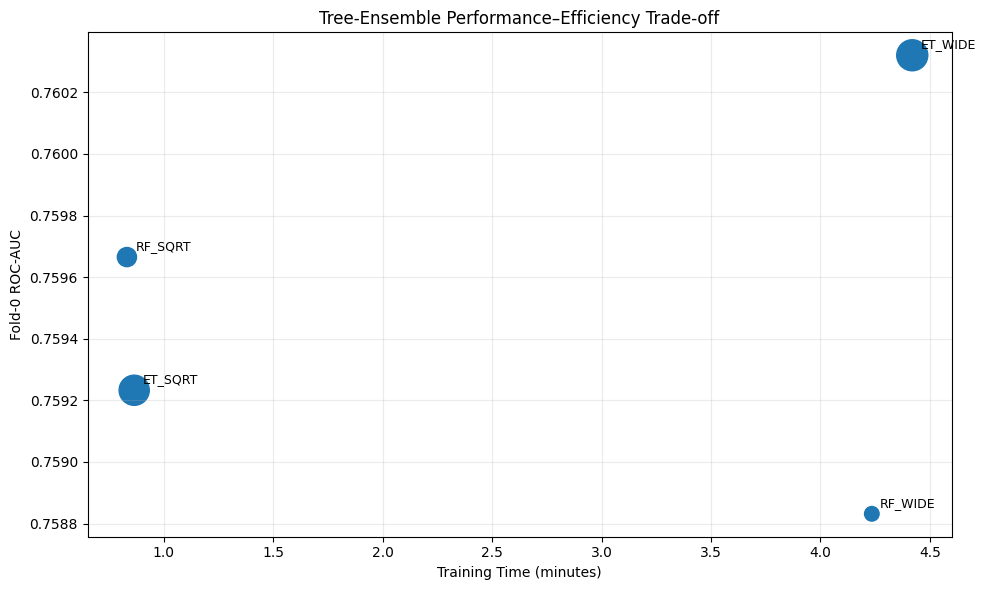

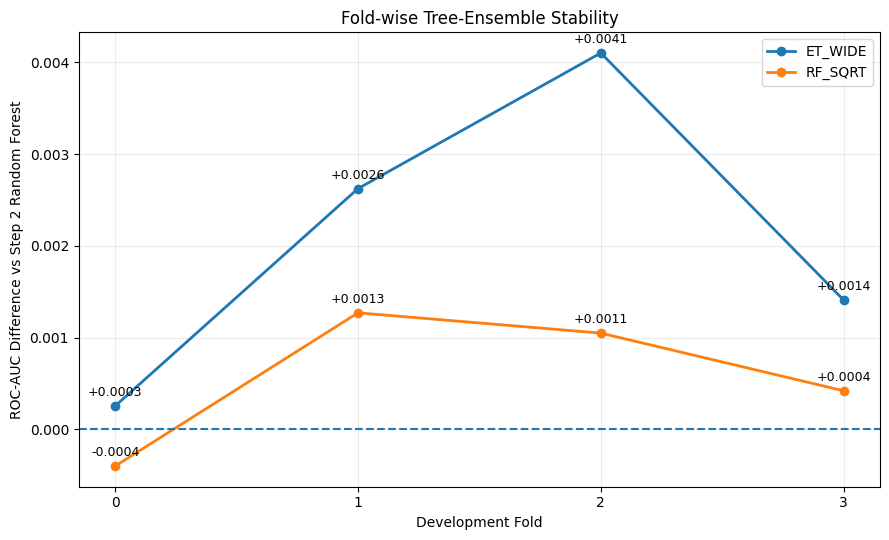

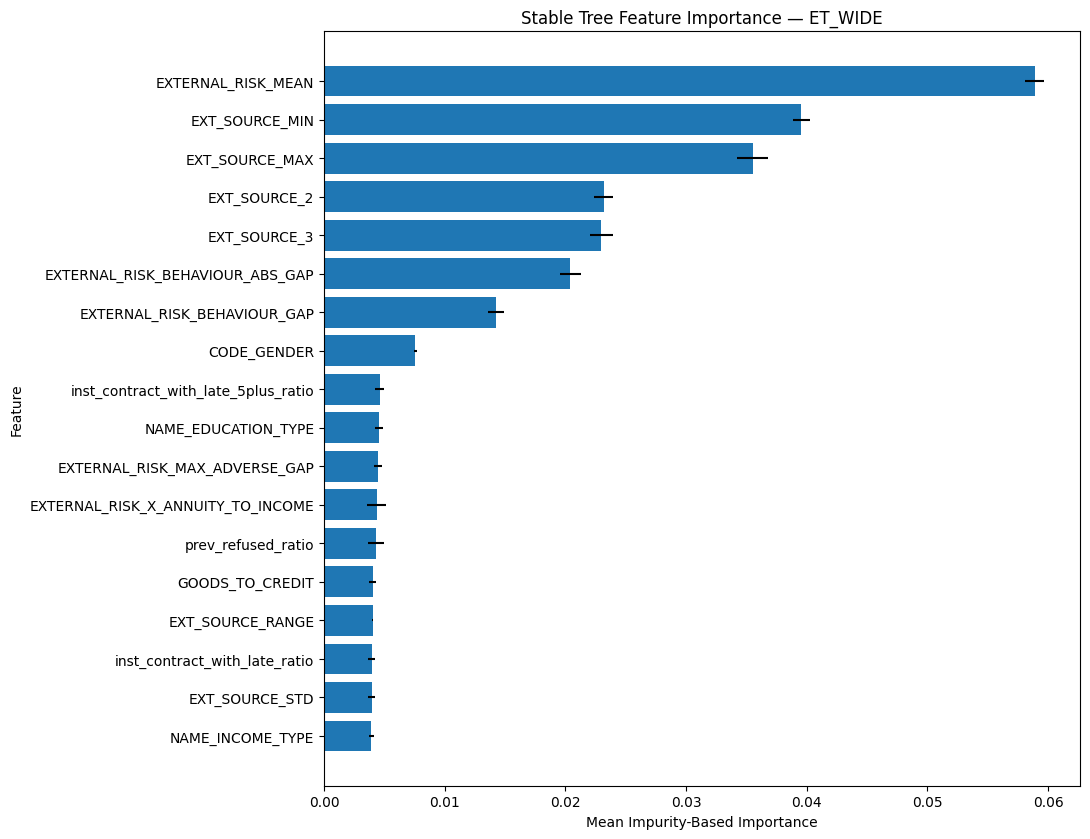

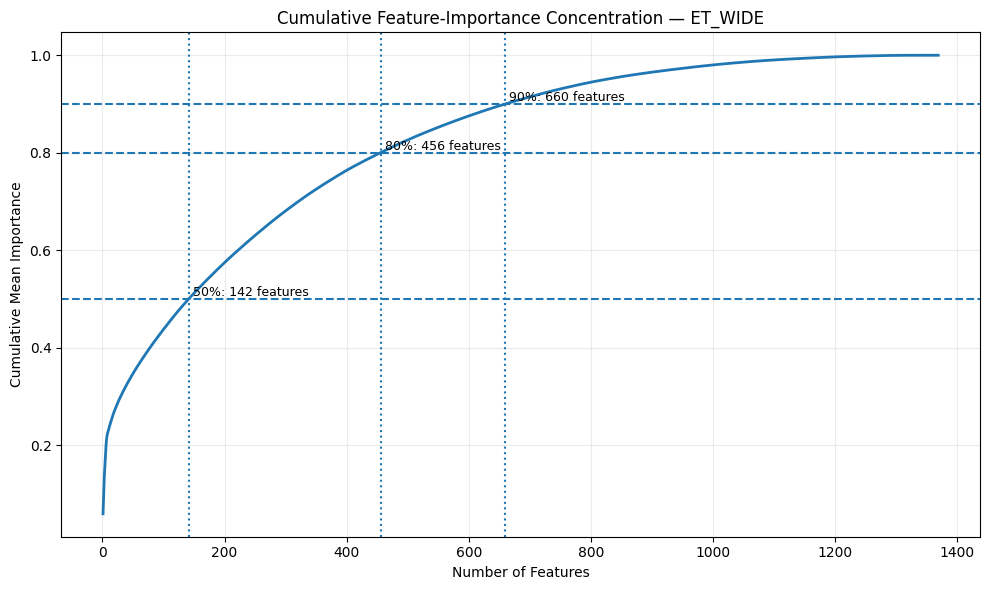

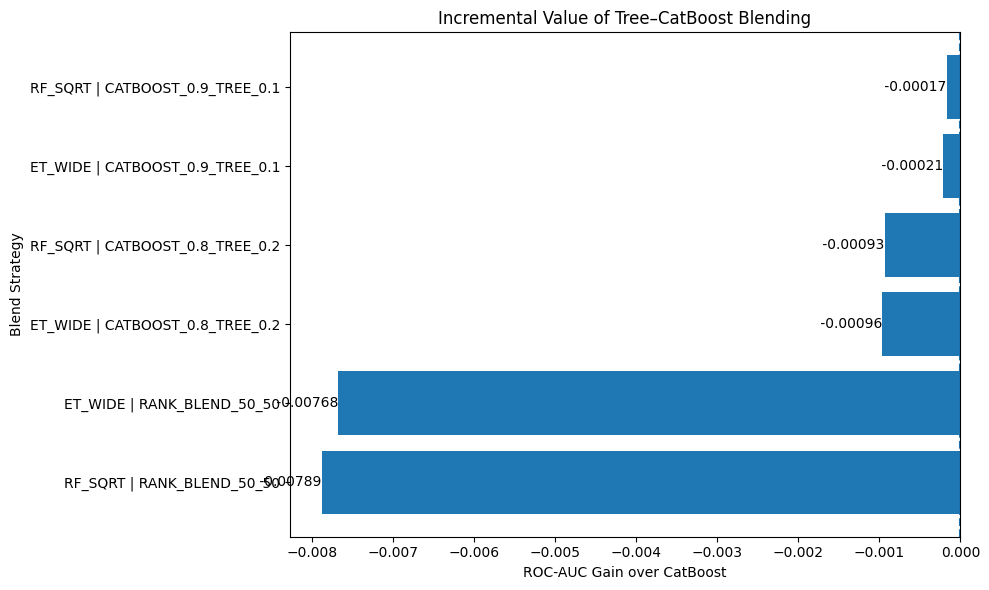

,candidate,family,roc_auc,auc_delta_vs_reference,fit_seconds,mean_tree_depth,mean_leaf_count,correlation_with_catboost
0,ET_WIDE,EXTRA_TREES,0.760320,0.000257,265.187552,18.0,3377.586667,0.851551
1,RF_SQRT,RANDOM_FOREST,0.759665,-0.000399,49.900803,18.0,1913.446667,0.847385
2,ET_SQRT,EXTRA_TREES,0.759233,-0.000831,51.896837,18.0,3243.680000,0.824591
3,RF_WIDE,RANDOM_FOREST,0.758832,-0.001232,254.103935,18.0,1531.566667,0.852251


,model,roc_auc,pr_auc,log_loss,brier_score,ks_statistic,capture_top_10,lift_top_10,fold_auc_mean,fold_auc_std,fold_auc_gap,improved_folds_vs_reference,fit_seconds,prediction_seconds,mean_tree_depth,mean_leaf_count
0,ET_WIDE,0.763795,0.251056,0.245038,0.067579,0.395441,0.345569,3.455690,0.763841,0.003803,0.007586,4,1053.958397,2.251306,18.0,3386.495000
1,RF_SQRT,0.762297,0.251522,0.245704,0.067694,0.391889,0.345619,3.456193,0.762328,0.004228,0.008712,3,192.073834,2.008295,18.0,1910.624167
2,STEP2_RANDOM_FOREST_REFERENCE,0.761699,0.247733,0.247430,0.068090,0.390282,0.344814,3.448137,0.761742,0.004058,0.008491,0,97.513241,1.439335,NaN,NaN


,candidate,fold,auc_delta
0,ET_WIDE,0,0.000257
1,ET_WIDE,1,0.002625
2,ET_WIDE,2,0.004102
3,ET_WIDE,3,0.001411
4,RF_SQRT,0,-0.000399
5,RF_SQRT,1,0.001271
6,RF_SQRT,2,0.001050
7,RF_SQRT,3,0.000422


,candidate,feature,mean_importance,importance_std,top_20_frequency
0,ET_WIDE,numeric__EXTERNAL_RISK_MEAN,0.058891,0.000774,4
1,ET_WIDE,numeric__EXT_SOURCE_MIN,0.039546,0.000692,4
2,ET_WIDE,numeric__EXT_SOURCE_MAX,0.035531,0.001297,4
3,ET_WIDE,numeric__EXT_SOURCE_2,0.023196,0.000783,4
4,ET_WIDE,numeric__EXT_SOURCE_3,0.022970,0.000952,4
5,ET_WIDE,numeric__EXTERNAL_RISK_BEHAVIOUR_ABS_GAP,0.020422,0.000888,4
6,ET_WIDE,numeric__EXTERNAL_RISK_BEHAVIOUR_GAP,0.014248,0.000633,4
7,ET_WIDE,categorical__CODE_GENDER,0.007558,0.000126,4
8,ET_WIDE,numeric__inst_contract_with_late_5plus_ratio,0.004602,0.000404,4
9,ET_WIDE,categorical__NAME_EDUCATION_TYPE,0.004530,0.000343,4


,model,blend,roc_auc
0,STEP2_CATBOOST,BASELINE,0.793372
1,RF_SQRT,CATBOOST_0.9_TREE_0.1,0.793202
2,ET_WIDE,CATBOOST_0.9_TREE_0.1,0.793160
3,RF_SQRT,CATBOOST_0.8_TREE_0.2,0.792437
4,ET_WIDE,CATBOOST_0.8_TREE_0.2,0.792411
5,ET_WIDE,RANK_BLEND_50_50,0.785688
6,RF_SQRT,RANK_BLEND_50_50,0.785486


,check,status,observed
0,TREE_SCREENING_COMPLETE,PASS,4
1,CANDIDATES_SELECTED,PASS,"['ET_WIDE', 'RF_SQRT']"
2,DEVELOPMENT_CONFIRMATION_COMPLETE,PASS,2
3,OOF_ALIGNMENT,PASS,True
4,FINITE_PROBABILITIES,PASS,True
5,FEATURE_IMPORTANCE_COMPLETE,PASS,18
6,RESEARCH_PLOTS_COMPLETE,PASS,5
7,LOCKBOX_REMAINS_SEALED,PASS,SEALED


TREE AND BAGGING RESEARCH COMPLETE
Decision: NEW_TREE_REFERENCE_CONFIRMED
Tree reference: ET_WIDE
Strongest confirmed model: ET_WIDE
Strongest confirmed ROC-AUC: 0.763795
Best CatBoost blend gain: +0.000000
Research plots created: 5/5
Lockbox rows accessed: 0
Next stage: Gradient Boosting Screening


In [25]:
# Step 4.6 — Final Tree-Ensemble Analysis

class TreeResearchAnalysis:
    @staticmethod
    def _format_feature_name(feature, maximum_length=58):
        name = (
            str(feature)
            .replace("numeric__", "")
            .replace("categorical__", "")
        )

        return (
            name
            if len(name) <= maximum_length
            else name[:maximum_length - 3] + "..."
        )

    @staticmethod
    def _save_plot(fig, filename):
        fig.tight_layout()

        fig.savefig(
            tree_figures_dir / filename,
            dpi=180,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

    @staticmethod
    def _safe_sum(frame, candidates):
        for column in candidates:
            if column in frame.columns:
                return float(
                    pd.to_numeric(
                        frame[column],
                        errors="coerce"
                    ).sum()
                )

        return np.nan

    @classmethod
    def _plot_screening_efficiency(cls, screening_results):
        plot_data = screening_results.copy()

        leaf_min = plot_data["mean_leaf_count"].min()
        leaf_range = (
            plot_data["mean_leaf_count"].max()
            - leaf_min
        )

        plot_data["point_size"] = (
            110
            + 390
            * (
                plot_data["mean_leaf_count"] - leaf_min
            )
            / max(leaf_range, 1e-9)
        )

        fig, ax = plt.subplots(figsize=(10, 6))

        ax.scatter(
            plot_data["fit_seconds"] / 60,
            plot_data["roc_auc"],
            s=plot_data["point_size"]
        )

        for row in plot_data.itertuples(index=False):
            ax.annotate(
                row.candidate,
                (
                    row.fit_seconds / 60,
                    row.roc_auc
                ),
                xytext=(6, 5),
                textcoords="offset points",
                fontsize=9
            )

        ax.set_xlabel("Training Time (minutes)")
        ax.set_ylabel("Fold-0 ROC-AUC")
        ax.set_title(
            "Tree-Ensemble Performance–Efficiency Trade-off"
        )
        ax.grid(alpha=0.25)

        cls._save_plot(
            fig,
            "screening_performance_efficiency.png"
        )

    @classmethod
    def _plot_fold_auc_difference(cls, fold_differences):
        fig, ax = plt.subplots(figsize=(9, 5.5))

        for candidate_name, candidate_data in (
            fold_differences.groupby("candidate")
        ):
            candidate_data = candidate_data.sort_values("fold")

            ax.plot(
                candidate_data["fold"],
                candidate_data["auc_delta"],
                marker="o",
                linewidth=2,
                label=candidate_name
            )

            for row in candidate_data.itertuples(index=False):
                ax.annotate(
                    f"{row.auc_delta:+.4f}",
                    (row.fold, row.auc_delta),
                    xytext=(0, 7),
                    textcoords="offset points",
                    ha="center",
                    fontsize=9
                )

        ax.axhline(0, linestyle="--")
        ax.set_xticks(development_folds)
        ax.set_xlabel("Development Fold")
        ax.set_ylabel(
            "ROC-AUC Difference vs Step 2 Random Forest"
        )
        ax.set_title("Fold-wise Tree-Ensemble Stability")
        ax.grid(alpha=0.25)
        ax.legend()

        cls._save_plot(
            fig,
            "fold_auc_difference.png"
        )

    @classmethod
    def _plot_feature_importance(
        cls,
        feature_table,
        candidate_name
    ):
        plot_data = (
            feature_table
            .sort_values("mean_importance")
            .copy()
        )

        plot_data["display_feature"] = (
            plot_data["feature"]
            .map(cls._format_feature_name)
        )

        fig, ax = plt.subplots(figsize=(11, 8.5))

        ax.barh(
            plot_data["display_feature"],
            plot_data["mean_importance"],
            xerr=plot_data["importance_std"].fillna(0)
        )

        ax.set_xlabel("Mean Impurity-Based Importance")
        ax.set_ylabel("Feature")
        ax.set_title(
            f"Stable Tree Feature Importance — {candidate_name}"
        )

        cls._save_plot(
            fig,
            "stable_feature_importance.png"
        )

    @classmethod
    def _plot_cumulative_importance(
        cls,
        feature_table,
        candidate_name
    ):
        plot_data = (
            feature_table
            .sort_values(
                "mean_importance",
                ascending=False
            )
            .reset_index(drop=True)
            .copy()
        )

        total_importance = max(
            plot_data["mean_importance"].sum(),
            1e-12
        )

        plot_data["cumulative_importance"] = (
            plot_data["mean_importance"].cumsum()
            / total_importance
        )

        feature_counts = {}

        for threshold in [0.50, 0.80, 0.90]:
            feature_counts[threshold] = int(
                np.searchsorted(
                    plot_data["cumulative_importance"],
                    threshold
                )
                + 1
            )

        fig, ax = plt.subplots(figsize=(10, 6))

        ax.plot(
            np.arange(1, len(plot_data) + 1),
            plot_data["cumulative_importance"],
            linewidth=2
        )

        for threshold, count in feature_counts.items():
            ax.axhline(threshold, linestyle="--")
            ax.axvline(count, linestyle=":")
            ax.text(
                count,
                threshold,
                f" {int(threshold * 100)}%: {count} features",
                va="bottom",
                fontsize=9
            )

        ax.set_xlabel("Number of Features")
        ax.set_ylabel("Cumulative Mean Importance")
        ax.set_title(
            f"Cumulative Feature-Importance Concentration — {candidate_name}"
        )
        ax.grid(alpha=0.25)

        cls._save_plot(
            fig,
            "cumulative_feature_importance.png"
        )

        return feature_counts

    @classmethod
    def _plot_blend_gain(cls, blend_results):
        baseline_auc = float(
            blend_results.loc[
                blend_results["blend"].eq("BASELINE"),
                "roc_auc"
            ].iloc[0]
        )

        plot_data = blend_results.loc[
            ~blend_results["blend"].eq("BASELINE")
        ].copy()

        assert not plot_data.empty, (
            "No tree blend result was created."
        )

        plot_data["auc_gain"] = (
            plot_data["roc_auc"] - baseline_auc
        )

        plot_data["display_name"] = (
            plot_data["model"]
            + " | "
            + plot_data["blend"]
        )

        plot_data = plot_data.sort_values("auc_gain")

        fig, ax = plt.subplots(figsize=(10, 6))

        ax.barh(
            plot_data["display_name"],
            plot_data["auc_gain"]
        )

        ax.axvline(0, linestyle="--")

        for position, gain in enumerate(
            plot_data["auc_gain"]
        ):
            ax.text(
                gain,
                position,
                f" {gain:+.5f}",
                va="center",
                ha="left" if gain >= 0 else "right"
            )

        ax.set_xlabel("ROC-AUC Gain over CatBoost")
        ax.set_ylabel("Blend Strategy")
        ax.set_title(
            "Incremental Value of Tree–CatBoost Blending"
        )

        cls._save_plot(
            fig,
            "blend_auc_gain.png"
        )

    @classmethod
    def run(cls):
        screening_results = pd.read_csv(
            tree_metrics_dir / "screening_results.csv"
        )

        with open(
            tree_study_root / "selected_candidates.json",
            "r",
            encoding="utf-8"
        ) as file:
            selected_candidates = json.load(file)[
                "selected_candidates"
            ]

        assert selected_candidates, (
            "No tree candidate was selected."
        )

        for candidate_name in selected_candidates:
            for fold in development_folds:
                run_dir = (
                    tree_runs_dir
                    / candidate_name
                    / f"fold_{fold}"
                )

                required_files = [
                    run_dir / "metrics.json",
                    run_dir / "predictions.parquet",
                    run_dir / "feature_importance.parquet"
                ]

                assert all(
                    path.exists()
                    for path in required_files
                ), (
                    f"Missing result: "
                    f"{candidate_name}, fold {fold}"
                )

        random_forest_oof = (
            pd.read_parquet(
                STEP2_OOF_PATHS["RANDOM_FOREST"]
            )
            .sort_values("row_position")
            .reset_index(drop=True)
        )

        catboost_oof = (
            pd.read_parquet(
                STEP2_OOF_PATHS["CATBOOST"]
            )
            .sort_values("row_position")
            .reset_index(drop=True)
        )

        reference_folds = (
            STEP2_FOLD_RESULTS
            .loc[
                STEP2_FOLD_RESULTS["model_key"]
                .eq("RANDOM_FOREST")
            ]
            .sort_values("validation_fold")
            .reset_index(drop=True)
        )

        overall_records = [{
            "model": "STEP2_RANDOM_FOREST_REFERENCE",
            **evaluate_tree_probabilities(
                random_forest_oof[TARGET_COLUMN],
                random_forest_oof["probability"]
            ),
            "fold_auc_mean": float(
                reference_folds["roc_auc"].mean()
            ),
            "fold_auc_std": float(
                reference_folds["roc_auc"].std(ddof=1)
            ),
            "fold_auc_gap": float(
                reference_folds["roc_auc"].max()
                - reference_folds["roc_auc"].min()
            ),
            "improved_folds_vs_reference": 0,
            "fit_seconds": cls._safe_sum(
                reference_folds,
                ["fit_seconds"]
            ),
            "prediction_seconds": cls._safe_sum(
                reference_folds,
                ["prediction_seconds", "predict_seconds"]
            ),
            "mean_tree_depth": np.nan,
            "mean_leaf_count": np.nan
        }]

        confirmed_oof = {}
        importance_tables = []
        fold_difference_records = []

        for candidate_name in selected_candidates:
            prediction_parts = []
            metric_parts = []
            importance_parts = []

            for fold in development_folds:
                run_dir = (
                    tree_runs_dir
                    / candidate_name
                    / f"fold_{fold}"
                )

                prediction_parts.append(
                    pd.read_parquet(
                        run_dir / "predictions.parquet"
                    )
                )

                importance_parts.append(
                    pd.read_parquet(
                        run_dir
                        / "feature_importance.parquet"
                    )
                )

                with open(
                    run_dir / "metrics.json",
                    "r",
                    encoding="utf-8"
                ) as file:
                    metric_parts.append(json.load(file))

            candidate_oof = (
                pd.concat(
                    prediction_parts,
                    ignore_index=True
                )
                .sort_values("row_position")
                .reset_index(drop=True)
            )

            candidate_fold_metrics = (
                pd.DataFrame(metric_parts)
                .sort_values("fold")
                .reset_index(drop=True)
            )

            candidate_importance = pd.concat(
                importance_parts,
                ignore_index=True
            )

            assert np.array_equal(
                candidate_oof["row_position"].to_numpy(),
                DEVELOPMENT_REGISTRY[
                    "row_position"
                ].to_numpy()
            )

            candidate_fold_metrics[
                "auc_delta_vs_reference"
            ] = (
                candidate_fold_metrics[
                    "roc_auc"
                ].to_numpy()
                - reference_folds[
                    "roc_auc"
                ].to_numpy()
            )

            for row in (
                candidate_fold_metrics
                .itertuples(index=False)
            ):
                fold_difference_records.append({
                    "candidate": candidate_name,
                    "fold": int(row.fold),
                    "auc_delta": float(
                        row.auc_delta_vs_reference
                    )
                })

            overall_records.append({
                "model": candidate_name,
                **evaluate_tree_probabilities(
                    candidate_oof[TARGET_COLUMN],
                    candidate_oof["probability"]
                ),
                "fold_auc_mean": float(
                    candidate_fold_metrics[
                        "roc_auc"
                    ].mean()
                ),
                "fold_auc_std": float(
                    candidate_fold_metrics[
                        "roc_auc"
                    ].std(ddof=1)
                ),
                "fold_auc_gap": float(
                    candidate_fold_metrics[
                        "roc_auc"
                    ].max()
                    - candidate_fold_metrics[
                        "roc_auc"
                    ].min()
                ),
                "improved_folds_vs_reference": int(
                    candidate_fold_metrics[
                        "auc_delta_vs_reference"
                    ].gt(0).sum()
                ),
                "fit_seconds": float(
                    candidate_fold_metrics[
                        "fit_seconds"
                    ].sum()
                ),
                "prediction_seconds": float(
                    candidate_fold_metrics[
                        "prediction_seconds"
                    ].sum()
                ),
                "mean_tree_depth": float(
                    candidate_fold_metrics[
                        "mean_tree_depth"
                    ].mean()
                ),
                "mean_leaf_count": float(
                    candidate_fold_metrics[
                        "mean_leaf_count"
                    ].mean()
                )
            })

            candidate_oof.to_parquet(
                tree_oof_dir
                / f"{candidate_name.lower()}_oof.parquet",
                index=False,
                compression="zstd"
            )

            candidate_fold_metrics.to_csv(
                tree_metrics_dir
                / f"{candidate_name.lower()}_fold_metrics.csv",
                index=False
            )

            confirmed_oof[candidate_name] = candidate_oof
            importance_tables.append(candidate_importance)

        tree_oof_results = (
            pd.DataFrame(overall_records)
            .sort_values(
                "roc_auc",
                ascending=False
            )
            .reset_index(drop=True)
        )

        tree_oof_results.to_csv(
            tree_metrics_dir / "oof_results.csv",
            index=False
        )

        fold_differences = pd.DataFrame(
            fold_difference_records
        )

        fold_differences.to_csv(
            tree_metrics_dir
            / "fold_auc_differences.csv",
            index=False
        )

        probability_table = pd.DataFrame({
            "STEP2_RANDOM_FOREST":
                random_forest_oof["probability"].to_numpy(),
            "STEP2_CATBOOST":
                catboost_oof["probability"].to_numpy(),
            **{
                candidate_name:
                    table["probability"].to_numpy()
                for candidate_name, table
                in confirmed_oof.items()
            }
        })

        prediction_correlation = (
            probability_table.corr()
        )

        prediction_correlation.to_csv(
            tree_metrics_dir
            / "prediction_correlation.csv"
        )

        target = random_forest_oof[
            TARGET_COLUMN
        ].to_numpy(dtype=np.int8)

        catboost_probability = catboost_oof[
            "probability"
        ].to_numpy()

        blend_records = [{
            "model": "STEP2_CATBOOST",
            "blend": "BASELINE",
            "roc_auc": float(
                roc_auc_score(
                    target,
                    catboost_probability
                )
            )
        }]

        for candidate_name, candidate_table in (
            confirmed_oof.items()
        ):
            tree_probability = candidate_table[
                "probability"
            ].to_numpy()

            for tree_weight in [0.10, 0.20]:
                blended_probability = (
                    (1 - tree_weight)
                    * catboost_probability
                    + tree_weight
                    * tree_probability
                )

                blend_records.append({
                    "model": candidate_name,
                    "blend": (
                        f"CATBOOST_{1-tree_weight:.1f}"
                        f"_TREE_{tree_weight:.1f}"
                    ),
                    "roc_auc": float(
                        roc_auc_score(
                            target,
                            blended_probability
                        )
                    )
                })

            rank_blend = (
                0.5
                * pd.Series(catboost_probability)
                .rank(pct=True)
                .to_numpy()
                + 0.5
                * pd.Series(tree_probability)
                .rank(pct=True)
                .to_numpy()
            )

            blend_records.append({
                "model": candidate_name,
                "blend": "RANK_BLEND_50_50",
                "roc_auc": float(
                    roc_auc_score(
                        target,
                        rank_blend
                    )
                )
            })

        blend_results = pd.DataFrame(blend_records)

        blend_results.to_csv(
            tree_metrics_dir
            / "blend_diagnostics.csv",
            index=False
        )

        all_importance = pd.concat(
            importance_tables,
            ignore_index=True
        )

        all_importance["fold_rank"] = (
            all_importance
            .groupby(
                ["candidate", "fold"]
            )["importance"]
            .rank(
                ascending=False,
                method="min"
            )
        )

        importance_stability = (
            all_importance
            .groupby(
                ["candidate", "feature"],
                observed=True
            )
            .agg(
                folds_present=("fold", "nunique"),
                mean_importance=("importance", "mean"),
                importance_std=("importance", "std"),
                mean_rank=("fold_rank", "mean"),
                top_20_frequency=(
                    "fold_rank",
                    lambda values: int(
                        (np.asarray(values) <= 20).sum()
                    )
                )
            )
            .reset_index()
        )

        importance_stability.to_csv(
            tree_explanations_dir
            / "feature_importance_stability.csv",
            index=False
        )

        confirmed_only = tree_oof_results.loc[
            tree_oof_results["model"].isin(
                selected_candidates
            )
        ]

        interpretation_model = (
            confirmed_only.iloc[0]["model"]
        )

        model_importance = (
            importance_stability.loc[
                importance_stability[
                    "candidate"
                ].eq(interpretation_model)
            ]
            .sort_values(
                "mean_importance",
                ascending=False
            )
            .reset_index(drop=True)
        )

        stable_top_features = (
            model_importance.loc[
                model_importance[
                    "top_20_frequency"
                ].ge(3)
            ]
            .head(20)
            .copy()
        )

        if len(stable_top_features) < 15:
            stable_top_features = (
                model_importance
                .head(20)
                .copy()
            )

        stable_top_features.to_csv(
            tree_explanations_dir
            / "stable_top_features.csv",
            index=False
        )

        cls._plot_screening_efficiency(
            screening_results
        )

        cls._plot_fold_auc_difference(
            fold_differences
        )

        cls._plot_feature_importance(
            stable_top_features,
            interpretation_model
        )

        importance_thresholds = (
            cls._plot_cumulative_importance(
                model_importance,
                interpretation_model
            )
        )

        cls._plot_blend_gain(blend_results)

        expected_plot_files = [
            "screening_performance_efficiency.png",
            "fold_auc_difference.png",
            "stable_feature_importance.png",
            "cumulative_feature_importance.png",
            "blend_auc_gain.png"
        ]

        missing_plots = [
            filename
            for filename in expected_plot_files
            if not (
                tree_figures_dir / filename
            ).exists()
        ]

        alignment_valid = all(
            np.array_equal(
                table["row_position"].to_numpy(),
                DEVELOPMENT_REGISTRY[
                    "row_position"
                ].to_numpy()
            )
            for table in confirmed_oof.values()
        )

        finite_probabilities = all(
            np.isfinite(
                table["probability"]
            ).all()
            for table in [
                random_forest_oof,
                catboost_oof,
                *confirmed_oof.values()
            ]
        )

        validation_report = pd.DataFrame([
            {
                "check": "TREE_SCREENING_COMPLETE",
                "status": (
                    "PASS"
                    if len(screening_results)
                    == len(tree_candidates)
                    else "FAIL"
                ),
                "observed": len(screening_results)
            },
            {
                "check": "CANDIDATES_SELECTED",
                "status": (
                    "PASS"
                    if bool(selected_candidates)
                    else "FAIL"
                ),
                "observed": str(
                    selected_candidates
                )
            },
            {
                "check": "DEVELOPMENT_CONFIRMATION_COMPLETE",
                "status": (
                    "PASS"
                    if len(confirmed_oof)
                    == len(selected_candidates)
                    else "FAIL"
                ),
                "observed": len(confirmed_oof)
            },
            {
                "check": "OOF_ALIGNMENT",
                "status": (
                    "PASS"
                    if alignment_valid
                    else "FAIL"
                ),
                "observed": alignment_valid
            },
            {
                "check": "FINITE_PROBABILITIES",
                "status": (
                    "PASS"
                    if finite_probabilities
                    else "FAIL"
                ),
                "observed": finite_probabilities
            },
            {
                "check": "FEATURE_IMPORTANCE_COMPLETE",
                "status": (
                    "PASS"
                    if not stable_top_features.empty
                    else "FAIL"
                ),
                "observed": len(
                    stable_top_features
                )
            },
            {
                "check": "RESEARCH_PLOTS_COMPLETE",
                "status": (
                    "PASS"
                    if not missing_plots
                    else "FAIL"
                ),
                "observed": (
                    len(expected_plot_files)
                    - len(missing_plots)
                )
            },
            {
                "check": "LOCKBOX_REMAINS_SEALED",
                "status": (
                    "PASS"
                    if LOCKBOX_CONTROL["status"]
                    == "SEALED"
                    and int(
                        LOCKBOX_CONTROL[
                            "evaluation_count"
                        ]
                    ) == 0
                    else "FAIL"
                ),
                "observed": (
                    LOCKBOX_CONTROL["status"]
                )
            }
        ])

        validation_report.to_csv(
            tree_metrics_dir
            / "validation_report.csv",
            index=False
        )

        assert not validation_report[
            "status"
        ].eq("FAIL").any()

        reference_auc = float(
            tree_oof_results.loc[
                tree_oof_results["model"].eq(
                    "STEP2_RANDOM_FOREST_REFERENCE"
                ),
                "roc_auc"
            ].iloc[0]
        )

        confirmed_results = (
            tree_oof_results.loc[
                tree_oof_results["model"].isin(
                    selected_candidates
                )
            ]
            .sort_values(
                "roc_auc",
                ascending=False
            )
            .reset_index(drop=True)
        )

        strongest_confirmed_model = (
            confirmed_results.iloc[0]["model"]
        )

        strongest_confirmed_auc = float(
            confirmed_results.iloc[0]["roc_auc"]
        )

        baseline_blend_auc = float(
            blend_results.loc[
                blend_results["blend"].eq(
                    "BASELINE"
                ),
                "roc_auc"
            ].iloc[0]
        )

        best_blend_auc = float(
            blend_results["roc_auc"].max()
        )

        best_blend_gain = (
            best_blend_auc
            - baseline_blend_auc
        )

        if strongest_confirmed_auc > reference_auc:
            decision = "NEW_TREE_REFERENCE_CONFIRMED"
            tree_reference = strongest_confirmed_model
        elif best_blend_gain > 0:
            decision = "TREE_DIVERSITY_CANDIDATE_ONLY"
            tree_reference = (
                "STEP2_RANDOM_FOREST_REFERENCE"
            )
        else:
            decision = "STEP2_RANDOM_FOREST_RETAINED"
            tree_reference = (
                "STEP2_RANDOM_FOREST_REFERENCE"
            )

        tree_summary = {
            "status": "TREE_AND_BAGGING_RESEARCH_COMPLETE",
            "decision": decision,
            "screened_configurations": len(
                tree_candidates
            ),
            "confirmed_configurations": (
                selected_candidates
            ),
            "tree_reference": tree_reference,
            "strongest_confirmed_model": (
                strongest_confirmed_model
            ),
            "strongest_confirmed_roc_auc": (
                strongest_confirmed_auc
            ),
            "best_blend_gain": float(
                best_blend_gain
            ),
            "importance_thresholds": {
                str(int(threshold * 100)): count
                for threshold, count
                in importance_thresholds.items()
            },
            "research_plots": expected_plot_files,
            "lockbox_rows_accessed": 0,
            "next_stage": (
                "GRADIENT_BOOSTING_SCREENING"
            )
        }

        with open(
            tree_study_root / "summary.json",
            "w",
            encoding="utf-8"
        ) as file:
            json.dump(tree_summary, file, indent=2)

        display(
            screening_results[[
                "candidate",
                "family",
                "roc_auc",
                "auc_delta_vs_reference",
                "fit_seconds",
                "mean_tree_depth",
                "mean_leaf_count",
                "correlation_with_catboost"
            ]]
        )

        display(tree_oof_results)

        display(
            fold_differences
            .sort_values(
                ["candidate", "fold"]
            )
            .reset_index(drop=True)
        )

        display(
            stable_top_features[[
                "candidate",
                "feature",
                "mean_importance",
                "importance_std",
                "top_20_frequency"
            ]]
        )

        display(
            blend_results
            .sort_values(
                "roc_auc",
                ascending=False
            )
            .reset_index(drop=True)
        )

        display(validation_report)

        print("=" * 90)
        print("TREE AND BAGGING RESEARCH COMPLETE")
        print(f"Decision: {decision}")
        print(f"Tree reference: {tree_reference}")
        print(
            f"Strongest confirmed model: "
            f"{strongest_confirmed_model}"
        )
        print(
            f"Strongest confirmed ROC-AUC: "
            f"{strongest_confirmed_auc:.6f}"
        )
        print(
            f"Best CatBoost blend gain: "
            f"{best_blend_gain:+.6f}"
        )
        print(
            f"Research plots created: "
            f"{len(expected_plot_files)}/5"
        )
        print("Lockbox rows accessed: 0")
        print(
            "Next stage: "
            "Gradient Boosting Screening"
        )
        print("=" * 90)

        return {
            "screening_results": screening_results,
            "oof_results": tree_oof_results,
            "fold_differences": fold_differences,
            "prediction_correlation": prediction_correlation,
            "blend_results": blend_results,
            "importance_stability": importance_stability,
            "stable_top_features": stable_top_features,
            "validation_report": validation_report,
            "summary": tree_summary
        }


tree_research_outputs = TreeResearchAnalysis.run()

## Tree and Bagging Decision

The Extra Trees configuration with wider feature sampling was confirmed as the new tree-family reference. It outperformed the verified Step 2 Random Forest on all four development folds, with fold-level ROC-AUC improvements ranging from approximately 0.0003 to 0.0041.

The improvement is modest but directionally consistent. RF_SQRT also improved over the reference on three of four folds and remains a computationally efficient tree baseline, although it did not match ET_WIDE's overall performance.

Feature-importance analysis showed that external-risk consensus, EXT_SOURCE variables, external-risk behaviour gaps, repayment distress, and affordability-related features provide the strongest tree-based signal. The importance distribution was broad: approximately 142, 456, and 660 features were required to explain 50%, 80%, and 90% of total mean importance, respectively. Therefore, aggressive top-feature pruning is not currently justified.

Neither ET_WIDE nor RF_SQRT improved CatBoost through probability or rank blending. The tree models are therefore retained as standalone reference and diagnostic models rather than as priority blending candidates.

The Step 2 CatBoost remains the overall performance champion, while ET_WIDE replaces the Step 2 Random Forest as the primary tree-ensemble reference. No lockbox data were accessed.

Tree-family champion:
ET_WIDE

Fast tree baseline:
RF_SQRT

Overall champion:
CATBOOST

Tree–CatBoost blend:
Rejected

Next stage:
Step 5 — Gradient Boosting Screening